# GEEANNT version 1.5 Random Search

Respect to the previous version, due to limitations in the reconstruction of $u_v$ thorugh mixtures of gaussians, this version gives directly $u_v$ to the model, mapping it via a categorical discretize head, as already done for the energy spectrum. 


The hyperparameters now change, because ```logE_bin_edges``` and ```uv_bin_edges``` are going to be trained as well, while ```w_sr, w_tv``` disappear.


To best fit the parameters we now use a Random Search algorithm sampling hypermeters in these ranges:

```
logE_bin_edges  in {512; 1024; 2048}
uv_bin_edges    in ?
w_phi_r         in [1.2, 1.8]
w_phi_v         in [0.9, 1.3]
w_xy            in [0.0, 0.03]
lambda_phi_r    in [1e-2, 4e-2]
lambda_phi      in [1e-2, 3e-2]
lambda_sigma    in [5e-4, 3e-3]
sigma_target    in [-2.8, -2.0]
lr              in [1e-4, 3e-4]

```

While mainting fixed

```
latent_dim = 8 or 12
hidden = (128,128,64,64,64)
beta = 0.1
min_log_sigma = -6.0
max_log_sigma = 1.5
```

The screening should be fast, therefore the epochs are 20, the early stopping has patience = 4.

The chosen library for this task in ```optuna```.

We need to define a *target metric*, for example:

```
score =
    a1 * KS_logE +
    a2 * KS_u_v +
    a3 * KS_x +
    a4 * KS_y +
    a5 * KS_z +
    a6 * KS_vx +
    a7 * KS_vy +
    penalties_for_spikes
```

with an higher weight for $u_v$ and $(x,y,z)$. An option could be:

```
score =
    1.5 * KS_u_v +
    1.0 * KS_x +
    1.0 * KS_y +
    1.0 * KS_z +
    0.8 * KS_logE +
    0.7 * KS_vx +
    0.7 * KS_vy +
    spike_penalty
```

The code has also a smarter change regarding the energy binning, where it can be chosen between three methods:

1. Binning with fixed energy width (default 5 keV) - ```fixed_width```

2. Binning with a minimum threshold of events per bin (default 20) given a total number of bins (default 512) - ```min_counts```

3. Binning with a fixed number of bins (default 512) in log scale - ```log_fixed_count```

In the features layout ```logE``` is replaced by ```energy_feature```.

In [154]:
# ==========================================================
# Imports
# ==========================================================
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # reduce TensorFlow log verbosity

import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import Image

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn import preprocessing

import scipy.stats as st
from scipy.stats import chi2, norm, ks_2samp, wasserstein_distance
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
from scipy.constants import c, m_e

from astropy.stats import poisson_conf_interval

from brokenaxes import brokenaxes
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyArrowPatch
from matplotlib import ticker
from mpl_toolkits.mplot3d.proj3d import proj_transform
from mpl_toolkits.mplot3d.axes3d import Axes3D

# Hyperparameter optimization
import optuna

# ==========================================================
# TensorFlow / Keras
# Force CPU for this project, since it is faster than tf-metal
# for this specific custom CVAE on the M1 MacBook Air
# ==========================================================
import tensorflow as tf
tf.config.set_visible_devices([], "GPU")

from tensorflow import keras
from tensorflow.keras import layers
from keras import regularizers

# ==========================================================
# Reproducibility
# ==========================================================
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# ==========================================================
# Version / device checks
# ==========================================================
print("TensorFlow version:", tf.__version__)
print("Keras version     :", keras.__version__)

print("\nPhysical devices  :", tf.config.list_physical_devices())
print("Physical GPU(s)   :", tf.config.list_physical_devices("GPU"))

print("\nLogical devices   :", tf.config.list_logical_devices())
print("Logical GPU(s)    :", tf.config.list_logical_devices("GPU"))

TensorFlow version: 2.16.2
Keras version     : 3.12.1

Physical devices  : [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Physical GPU(s)   : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Logical devices   : [LogicalDevice(name='/device:CPU:0', device_type='CPU')]
Logical GPU(s)    : []


## Dataset Import and Checks

In [155]:
col_list_Det = ["EventId", "ParticleName", "Energy", "X", "Y", "Z", "Vx", "Vy", "Vz"]
# force second column (index 1) to string, all others to float
dtype_map = {name: float for name in col_list_Det}
dtype_map[col_list_Det[1]] = str

#Data_K40 = pd.read_table('/Users/francesco/Desktop/Università/Magistrale/Tesi/Sim/S1GDMLSRON3Step/KDSourceTesting/alloutputDSCryoSphere.dat', names=col_list_Det, dtype=dtype_map)
Data_K40 = pd.read_table('/Users/francesco/Desktop/Università/Magistrale/Tesi/Sim/S1GDMLSRON3Step/GEEANNT/alloutputDSCryoSphereSmall.dat', names=col_list_Det, dtype=dtype_map)

# Remove the first column from Data_K40 (EventIds are not useful for ANN training)
Data_K40.drop(columns=["EventId"], inplace=True)

print("N righe:", len(Data_K40))
print(Data_K40.head())

# Controlli rapidi di NaN / inf
print("\nNaN per colonna:\n", Data_K40.isna().sum())
for c in ["Energy","X","Y","Z","Vx","Vy","Vz"]:
    bad = ~np.isfinite(Data_K40[c].to_numpy())
    if bad.any():
        print(f"Attenzione: {bad.sum()} valori non finiti in {c}")

N righe: 1873609
  ParticleName    Energy        X         Y        Z        Vx        Vy  \
0        gamma  0.150271  19.6164  90.88580 -473.600  0.096896 -0.990521   
1        gamma  0.091620 -31.8887 -82.91700 -463.909  0.913246  0.194270   
2        gamma  0.113628  94.9088   9.60548 -481.123 -0.169791  0.894456   
3        gamma  0.305449 -47.4416 -25.87610 -424.650  0.697276 -0.601885   
4        gamma  0.258675  21.8070  91.71120 -537.841 -0.668961 -0.634526   

         Vz  
0 -0.097358  
1 -0.358107  
2 -0.413667  
3 -0.389283  
4 -0.387128  

NaN per colonna:
 ParticleName    0
Energy          0
X               0
Y               0
Z               0
Vx              0
Vy              0
Vz              0
dtype: int64


## Parameters Checks

Removed the clipping of $u_v$ which altered the distribution creating an artifact spike


--- RAW sphere check (r = ||x-C||) ---
r: mean = 99.23411918434232  std = 0.40461867908293037  min = 98.93981564523723  max = 100.06006989051981
Mean absolute deviation from R: 0.7682885734999307

--- RAW direction norm check (||v||) ---
||v||: mean = 0.9999999998903653  std = 2.88613664129066e-07  min = 0.9999991604741476  max = 1.0000008313726545
Mean absolute deviation from 1: 2.402573376849245e-07

--- Energy check ---
E: min = 0.0011044  max = 1.46082  #E<=0 = 0

--- PROJECTED sphere check ---
r_proj: mean = 99.99999999999902  std = 2.2897201782837348e-14  min = 99.99999999999896  max = 99.99999999999903
Mean absolute deviation from R: 1.0007113932897926e-12

--- RENORMALIZED direction check ---
||vhat||: mean = 0.9999999999990034  std = 3.408393483818028e-15  min = 0.9999999999989996  max = 0.9999999999990002
Mean absolute deviation from 1: 1.0000542428995967e-12


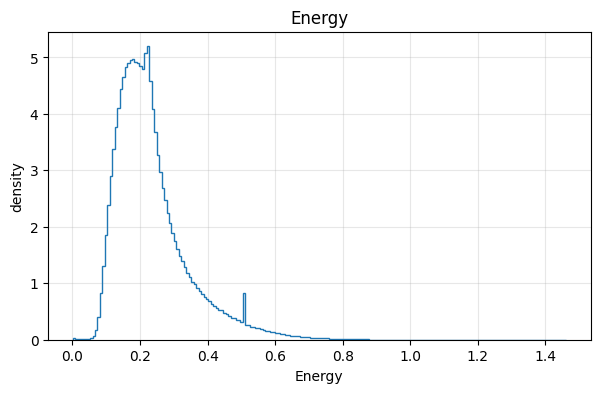

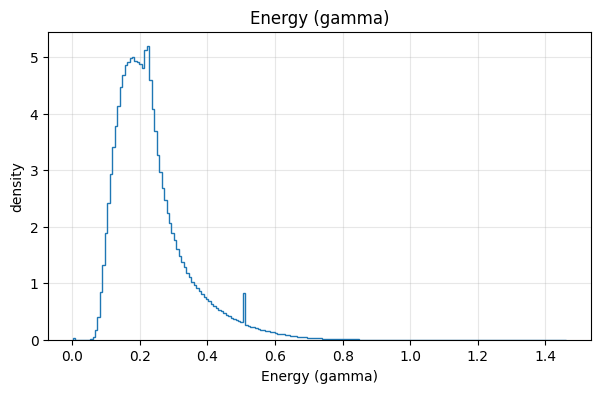

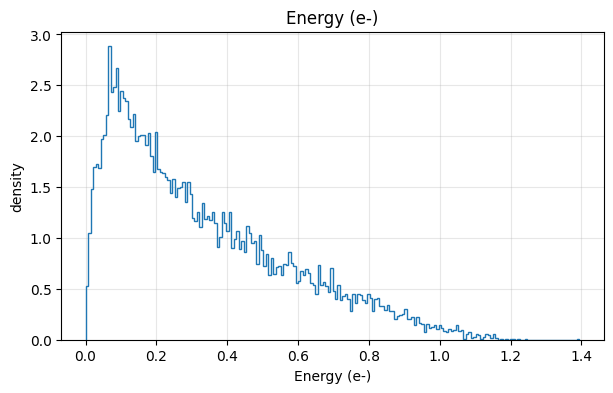

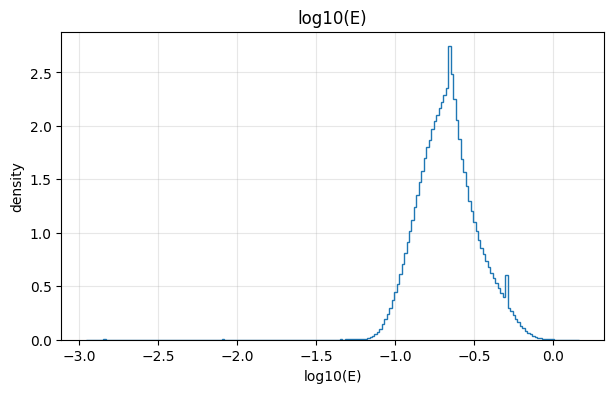

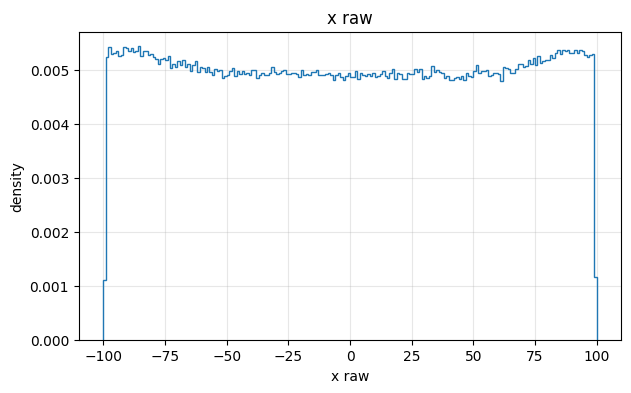

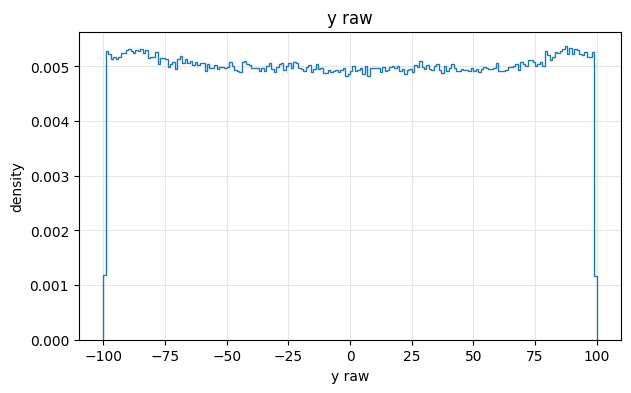

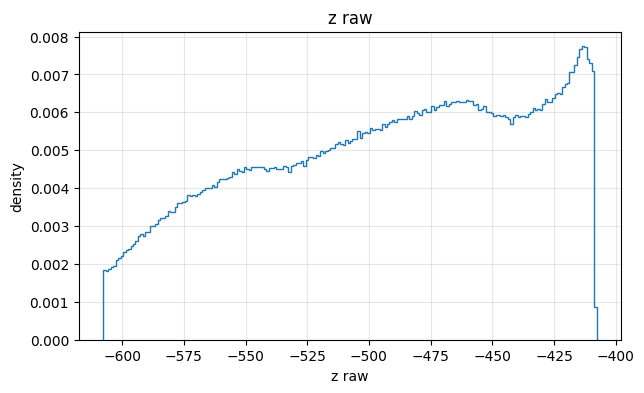

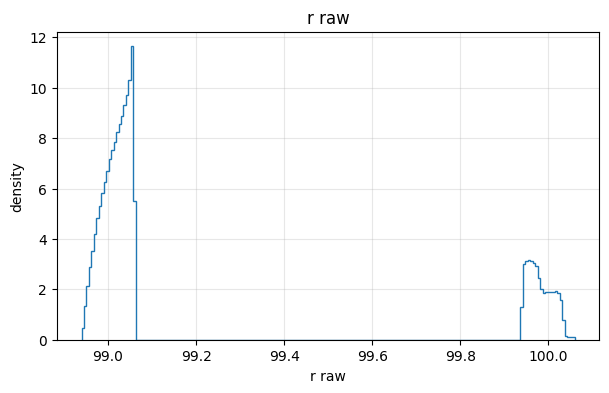

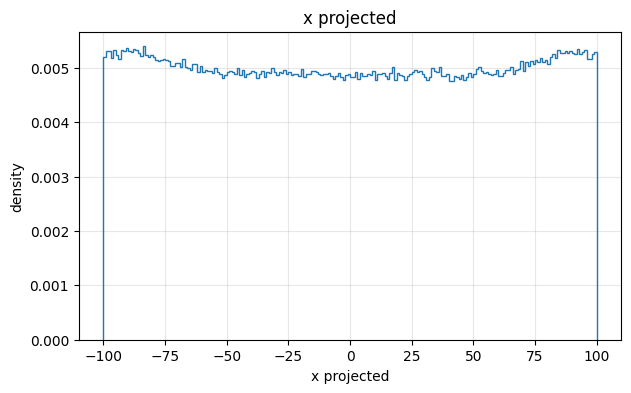

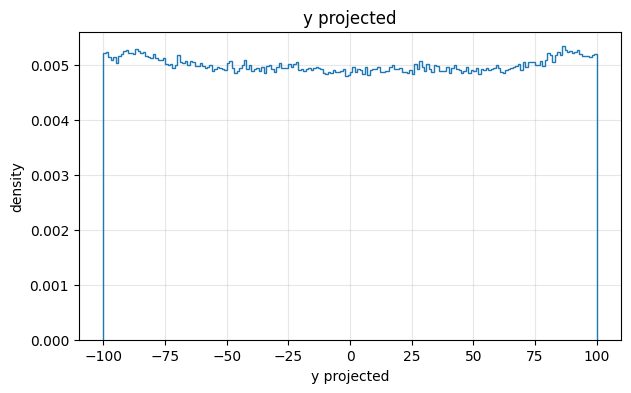

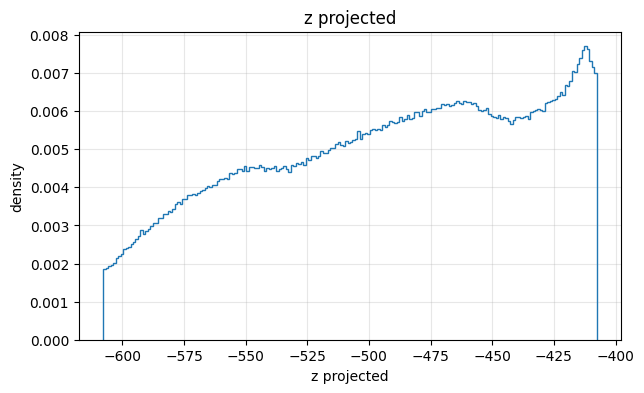

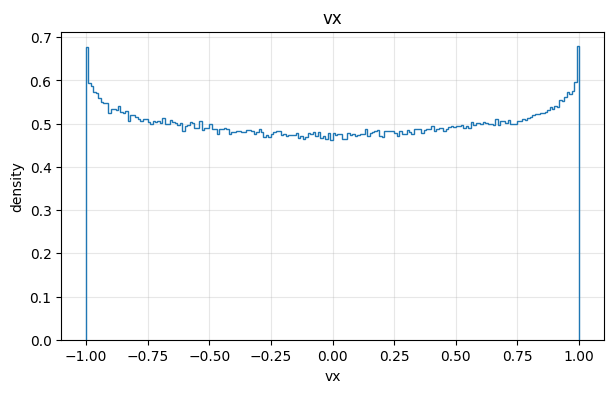

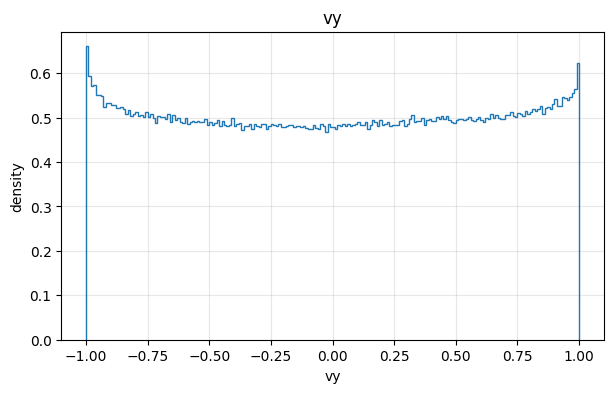

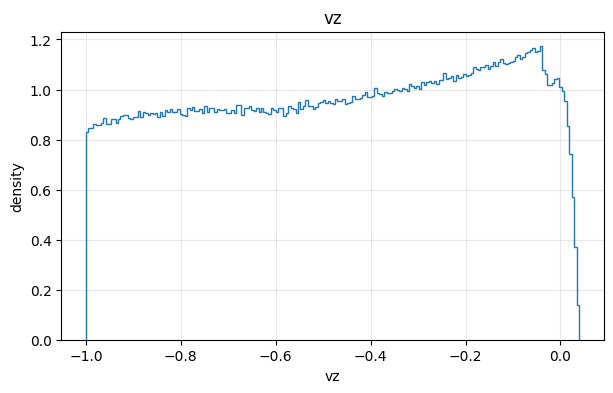

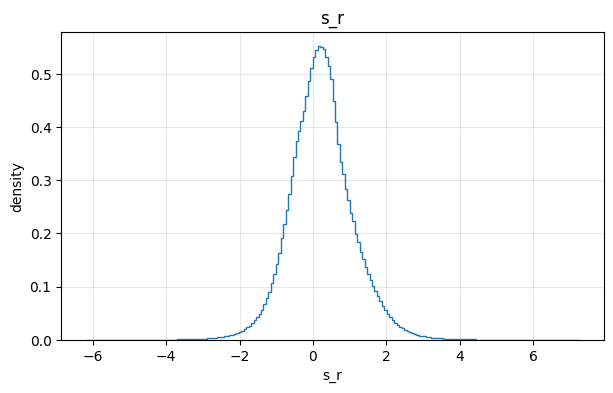

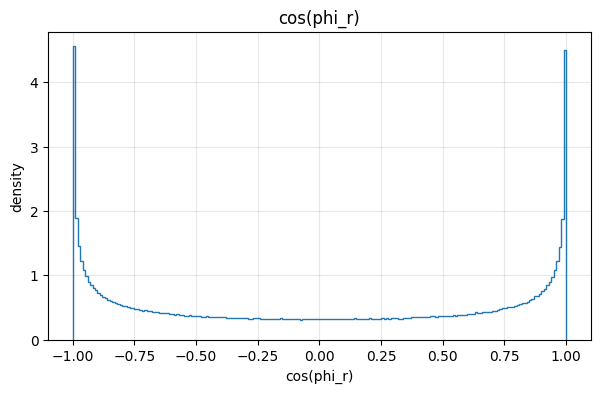

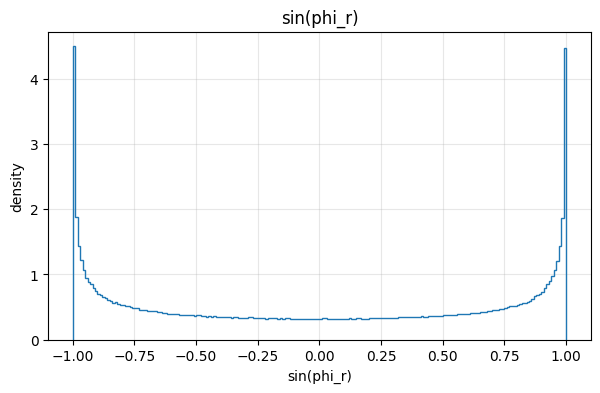

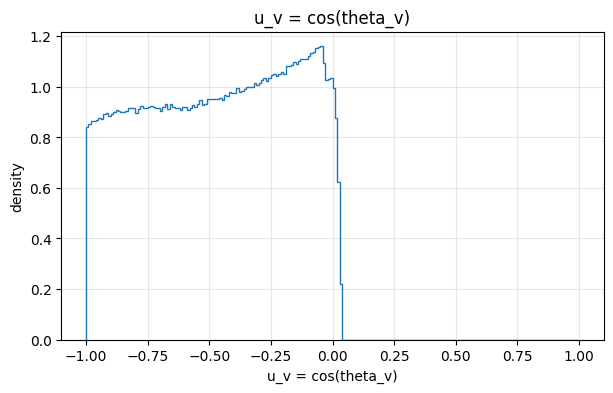

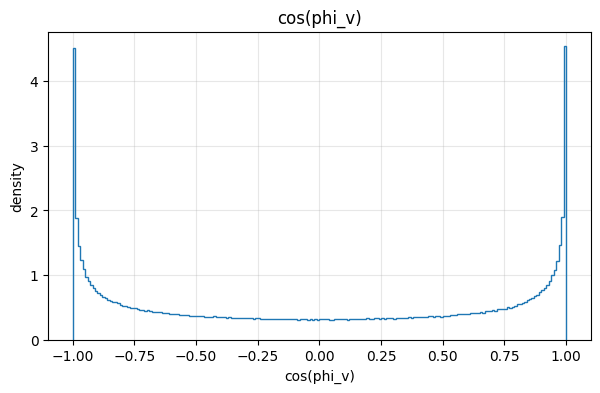

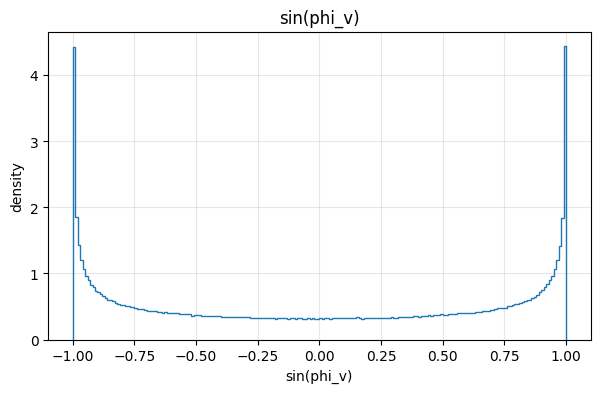


--- Check u_v ---
u_v: min = -0.999999 max = 0.039454388658001965 mean = -0.4645152278845347 std = 0.2968404672704411
fraction u_v > 0 = 0.027152410134665236


In [156]:
# ==========================================================
# Initial physical checks and base feature construction
# New feature layout:
# [energy_feature, s_r, cphi_r, sphi_r, u_v, cphi_v, sphi_v]
#
# where:
#   - energy_feature depends on the selected energy binning mode
#   - s_r = atanh(u_r), with u_r = cos(theta_r)
#   - u_v = cos(theta_v) is kept directly and will be modeled
#     with a categorical discretized head
# ==========================================================

C = np.array([0.0, 0.0, -507.66], dtype=np.float64)
R = 100.0
eps = 1e-6

xyz = Data_K40[["X", "Y", "Z"]].to_numpy(dtype=np.float64)
v   = Data_K40[["Vx", "Vy", "Vz"]].to_numpy(dtype=np.float64)
E   = Data_K40["Energy"].to_numpy(dtype=np.float64)

x = xyz[:, 0]
y = xyz[:, 1]
z = xyz[:, 2]

vx = v[:, 0]
vy = v[:, 1]
vz = v[:, 2]

# ==========================================================
# Initial physical checks
# ==========================================================

rvec = xyz - C[None, :]
r = np.linalg.norm(rvec, axis=1)
vnorm = np.linalg.norm(v, axis=1)

print("\n--- RAW sphere check (r = ||x-C||) ---")
print("r: mean =", r.mean(), " std =", r.std(), " min =", r.min(), " max =", r.max())
print("Mean absolute deviation from R:", np.mean(np.abs(r - R)))

print("\n--- RAW direction norm check (||v||) ---")
print("||v||: mean =", vnorm.mean(), " std =", vnorm.std(), " min =", vnorm.min(), " max =", vnorm.max())
print("Mean absolute deviation from 1:", np.mean(np.abs(vnorm - 1.0)))

print("\n--- Energy check ---")
print("E: min =", E.min(), " max =", E.max(), " #E<=0 =", np.sum(E <= 0))

# ==========================================================
# Filter out invalid energies
# ==========================================================

mask_posE = (E > 0) & np.isfinite(E)
if not mask_posE.all():
    print(f"\nRemoving {np.sum(~mask_posE)} rows with E<=0 or non-finite E.")
    Data_K40 = Data_K40.loc[mask_posE].reset_index(drop=True)

    xyz = Data_K40[["X", "Y", "Z"]].to_numpy(dtype=np.float64)
    v   = Data_K40[["Vx", "Vy", "Vz"]].to_numpy(dtype=np.float64)
    E   = Data_K40["Energy"].to_numpy(dtype=np.float64)

    x = xyz[:, 0]
    y = xyz[:, 1]
    z = xyz[:, 2]

    vx = v[:, 0]
    vy = v[:, 1]
    vz = v[:, 2]

    rvec = xyz - C[None, :]
    r = np.linalg.norm(rvec, axis=1)
    vnorm = np.linalg.norm(v, axis=1)

# ==========================================================
# Position regularization:
# project all points onto the sphere of radius R
# ==========================================================

rhat = rvec / (r[:, None] + 1e-12)
rvec_proj = R * rhat
xyz_proj = C[None, :] + rvec_proj

x_proj = xyz_proj[:, 0]
y_proj = xyz_proj[:, 1]
z_proj = xyz_proj[:, 2]

r_proj = np.linalg.norm(rvec_proj, axis=1)

print("\n--- PROJECTED sphere check ---")
print("r_proj: mean =", r_proj.mean(), " std =", r_proj.std(), " min =", r_proj.min(), " max =", r_proj.max())
print("Mean absolute deviation from R:", np.mean(np.abs(r_proj - R)))

# ==========================================================
# Direction regularization:
# renormalize direction vectors for numerical safety
# ==========================================================

vhat = v / (vnorm[:, None] + 1e-12)

vx_hat = vhat[:, 0]
vy_hat = vhat[:, 1]
vz_hat = vhat[:, 2]

vnorm_hat = np.linalg.norm(vhat, axis=1)

print("\n--- RENORMALIZED direction check ---")
print("||vhat||: mean =", vnorm_hat.mean(), " std =", vnorm_hat.std(), " min =", vnorm_hat.min(), " max =", vnorm_hat.max())
print("Mean absolute deviation from 1:", np.mean(np.abs(vnorm_hat - 1.0)))

# ==========================================================
# Build geometric features
# ==========================================================

# ----------------------------------------------------------
# Position features from projected sphere coordinates
# ----------------------------------------------------------
u_r = np.clip(rhat[:, 2], -1.0 + eps, 1.0 - eps)
s_r = np.arctanh(u_r)

phi_r = np.arctan2(rhat[:, 1], rhat[:, 0])
cphi_r = np.cos(phi_r)
sphi_r = np.sin(phi_r)

# ----------------------------------------------------------
# Direction features from renormalized direction vector
# Keep u_v directly in [-1, 1]
# ----------------------------------------------------------
u_v = np.clip(vz_hat, -1.0 + eps, 1.0 - eps)

phi_v = np.arctan2(vy_hat, vx_hat)
cphi_v = np.cos(phi_v)
sphi_v = np.sin(phi_v)

# ----------------------------------------------------------
# Log-energy is still useful for diagnostics and for the
# logarithmic binning mode
# ----------------------------------------------------------
logE = np.log10(E)

# ==========================================================
# Plot helper
# ==========================================================

def plot_dist(data, name, bins=200, range_=None):
    plt.figure(figsize=(7, 4))
    plt.hist(data, bins=bins, range=range_, density=True, histtype="step")
    plt.xlabel(name)
    plt.ylabel("density")
    plt.title(name)
    plt.grid(True, alpha=0.3)
    plt.show()

# ==========================================================
# Energy plots
# ==========================================================
plot_dist(E, "Energy")
plot_dist(E[Data_K40["ParticleName"] == "gamma"], "Energy (gamma)")
plot_dist(E[Data_K40["ParticleName"] == "e-"], "Energy (e-)")
plot_dist(logE, "log10(E)")

# ==========================================================
# RAW position plots
# ==========================================================
plot_dist(x, "x raw")
plot_dist(y, "y raw")
plot_dist(z, "z raw")
plot_dist(r, "r raw")

# ==========================================================
# PROJECTED position plots
# ==========================================================
plot_dist(x_proj, "x projected")
plot_dist(y_proj, "y projected")
plot_dist(z_proj, "z projected")

# ==========================================================
# Direction plots
# ==========================================================
plot_dist(vx_hat, "vx")
plot_dist(vy_hat, "vy")
plot_dist(vz_hat, "vz")

# ==========================================================
# Position feature plots
# ==========================================================
plot_dist(s_r, "s_r")
plot_dist(cphi_r, "cos(phi_r)")
plot_dist(sphi_r, "sin(phi_r)")

# ==========================================================
# Direction feature plots
# ==========================================================
plot_dist(u_v, "u_v = cos(theta_v)", range_=(-1, 1))
plot_dist(cphi_v, "cos(phi_v)", range_=(-1, 1))
plot_dist(sphi_v, "sin(phi_v)", range_=(-1, 1))

# ==========================================================
# Useful checks on u_v
# ==========================================================
print("\n--- Check u_v ---")
print("u_v: min =", u_v.min(), "max =", u_v.max(), "mean =", u_v.mean(), "std =", u_v.std())
print("fraction u_v > 0 =", np.mean(u_v > 0))

In [157]:
# ==========================================================
# Final feature dataframe construction
#
# New feature layout:
# [energy_feature, s_r, cphi_r, sphi_r, u_v, cphi_v, sphi_v]
#
# Energy feature is defined according to ENERGY_BINNING_MODE:
#   1) "fixed_width"
#   2) "min_counts"
#   3) "log_fixed_count"
# ==========================================================

# ==========================================================
# Energy selection + binning configuration
# ==========================================================

ENERGY_BINNING_MODE = "log_fixed_count"  # ["fixed_width", "min_counts", "log_fixed_count"]

# Optional energy cuts in MeV
E_MIN_CUT = 0.05   # example: 0.05
E_MAX_CUT = 0.8   # example: 8.0

# Default binning parameters
BIN_WIDTH = 0.500   # MeV, used in fixed_width
N_BINS = 512        # used in min_counts / log_fixed_count
MIN_COUNTS = 20     # used in min_counts

# ==========================================================
# Apply optional energy cut before bin construction
# This ensures that all downstream steps are fully consistent
# with the selected energy range.
# ==========================================================

mask_energy = np.isfinite(E)

if E_MIN_CUT is not None:
    mask_energy &= (E >= E_MIN_CUT)

if E_MAX_CUT is not None:
    mask_energy &= (E <= E_MAX_CUT)

n_before = len(E)
n_removed = np.sum(~mask_energy)

print("\n--- Energy cut configuration ---")
print("E_MIN_CUT:", E_MIN_CUT)
print("E_MAX_CUT:", E_MAX_CUT)

if n_removed > 0:
    print(f"\nApplying energy cut: removing {n_removed} rows out of {n_before}")

    Data_K40 = Data_K40.loc[mask_energy].reset_index(drop=True)

    # Apply the same mask to all already-built arrays/features
    E = E[mask_energy]

    s_r = s_r[mask_energy]
    cphi_r = cphi_r[mask_energy]
    sphi_r = sphi_r[mask_energy]

    u_v = u_v[mask_energy]
    cphi_v = cphi_v[mask_energy]
    sphi_v = sphi_v[mask_energy]

else:
    print("\nNo rows removed by the energy cut.")

print("Remaining rows:", len(E))
print("Remaining energy range:", E.min(), "to", E.max())

# ==========================================================
# Build energy bins and categorical indices
# ==========================================================

def build_energy_bins(E, mode, bin_width=BIN_WIDTH, n_bins=N_BINS, min_counts=MIN_COUNTS):
    """
    Build energy bin edges according to the selected mode.

    Parameters
    ----------
    E : array-like
        Physical energy values in MeV.
    mode : str
        One of:
          - "fixed_width"
          - "min_counts"
          - "log_fixed_count"
    bin_width : float
        Fixed bin width in MeV for "fixed_width".
    n_bins : int
        Initial / target number of bins.
    min_counts : int
        Minimum counts per bin for "min_counts".

    Returns
    -------
    bins : np.ndarray
        Array of bin edges.
    """

    E = np.asarray(E, dtype=np.float64)

    if E.ndim != 1 or len(E) == 0:
        raise ValueError("E must be a non-empty 1D array.")

    if mode == "fixed_width":
        # Uniform binning in linear energy
        E_min, E_max = E.min(), E.max()
        bins = np.arange(E_min, E_max + bin_width, bin_width, dtype=np.float64)

        # Ensure at least two edges
        if len(bins) < 2:
            bins = np.array([E_min, E_max + bin_width], dtype=np.float64)

        # Ensure last edge is above the max value
        if bins[-1] <= E_max:
            bins = np.append(bins, bins[-1] + bin_width)

    elif mode == "log_fixed_count":
        # Uniform binning in log10(E)
        if np.any(E <= 0):
            raise ValueError("All energies must be > 0 for log_fixed_count mode.")

        logE = np.log10(E)
        bins_log = np.linspace(logE.min(), logE.max(), n_bins + 1, dtype=np.float64)
        bins = np.power(10.0, bins_log)

    elif mode == "min_counts":
        # Start from a fixed number of bins and iteratively merge bins
        hist, edges = np.histogram(E, bins=n_bins)

        hist = hist.astype(np.int64)
        edges = list(edges.astype(np.float64))

        i = 0
        while i < len(hist):
            if hist[i] < min_counts and len(hist) > 1:

                if i == 0:
                    # Merge first bin with the right neighbor
                    hist[1] += hist[0]
                    hist = np.delete(hist, 0)
                    edges.pop(1)

                elif i == len(hist) - 1:
                    # Merge last bin with the left neighbor
                    hist[i - 1] += hist[i]
                    hist = np.delete(hist, i)
                    edges.pop(i)

                else:
                    # Merge with the less populated adjacent bin
                    if hist[i - 1] <= hist[i + 1]:
                        hist[i - 1] += hist[i]
                        hist = np.delete(hist, i)
                        edges.pop(i)
                        i -= 1
                    else:
                        hist[i + 1] += hist[i]
                        hist = np.delete(hist, i)
                        edges.pop(i + 1)

            else:
                i += 1

        bins = np.array(edges, dtype=np.float64)

    else:
        raise ValueError("Invalid ENERGY_BINNING_MODE")

    return bins

# Build bins
energy_bins = build_energy_bins(
    E,
    ENERGY_BINNING_MODE,
    bin_width=BIN_WIDTH,
    n_bins=N_BINS,
    min_counts=MIN_COUNTS
)

# Digitize energy into bins
energy_idx = np.digitize(E, energy_bins) - 1
energy_idx = np.clip(energy_idx, 0, len(energy_bins) - 2)

n_energy_bins = len(energy_bins) - 1

print("\n--- Energy binning ---")
print("Mode:", ENERGY_BINNING_MODE)
print("Number of bins:", n_energy_bins)

# ==========================================================
# Final feature dataframe
# ==========================================================

feat = pd.DataFrame({
    "ParticleName": Data_K40["ParticleName"].astype(str).to_numpy(),

    # Categorical energy index
    "E_idx": energy_idx.astype(np.int32),

    # Geometric features
    "s_r":    s_r.astype(np.float32),
    "cphi_r": cphi_r.astype(np.float32),
    "sphi_r": sphi_r.astype(np.float32),

    # Direction feature
    "u_v":    u_v.astype(np.float32),
    "cphi_v": cphi_v.astype(np.float32),
    "sphi_v": sphi_v.astype(np.float32),
})

print("\nfeat shape:", feat.shape)

print("\nFirst rows:")
display(feat.head())

# ==========================================================
# Finite check
# ==========================================================

print("\n--- Finite check ---")

arr = feat[["s_r", "cphi_r", "sphi_r", "u_v", "cphi_v", "sphi_v"]].to_numpy()
bad = ~np.isfinite(arr).all(axis=1)

print("Rows with NaN/Inf:", np.sum(bad))

# ==========================================================
# Feature ranges
# ==========================================================

print("\n--- Feature ranges ---")

for c in ["s_r", "cphi_r", "sphi_r", "u_v", "cphi_v", "sphi_v"]:
    print(f"{c:>8s} : {feat[c].min()}  {feat[c].max()}")

# ==========================================================
# Unit circle checks
# ==========================================================

print("\n--- Unit circle checks ---")

cr = np.sqrt(feat["cphi_r"].to_numpy()**2 + feat["sphi_r"].to_numpy()**2)
cv = np.sqrt(feat["cphi_v"].to_numpy()**2 + feat["sphi_v"].to_numpy()**2)

print("position: mean =", cr.mean(), "std =", cr.std(), "min =", cr.min(), "max =", cr.max())
print("direction: mean =", cv.mean(), "std =", cv.std(), "min =", cv.min(), "max =", cv.max())

# ==========================================================
# u_v checks
# ==========================================================

print("\n--- u_v checks ---")

print("u_v: min =", feat["u_v"].min(), "max =", feat["u_v"].max())
print("u_v mean =", feat["u_v"].mean(), "std =", feat["u_v"].std())
print("fraction u_v > 0 =", np.mean(feat["u_v"] > 0))

# ==========================================================
# Energy bin population check
# ==========================================================

print("\n--- Energy bin population ---")

hist_counts, _ = np.histogram(E, bins=energy_bins)
print("Min counts per bin:", hist_counts.min())
print("Max counts per bin:", hist_counts.max())
print("Mean counts per bin:", hist_counts.mean())
print("Empty bins:", np.sum(hist_counts == 0))


--- Energy cut configuration ---
E_MIN_CUT: 0.05
E_MAX_CUT: 0.8

Applying energy cut: removing 3161 rows out of 1873609
Remaining rows: 1870448
Remaining energy range: 0.0500146 to 0.799987

--- Energy binning ---
Mode: log_fixed_count
Number of bins: 512

feat shape: (1870448, 8)

First rows:


,ParticleName,E_idx,s_r,cphi_r,sphi_r,u_v,cphi_v,sphi_v
0,gamma,203,0.358586,0.210977,0.977491,-0.097358,0.097358,-0.995249
1,gamma,111,0.474478,-0.358955,-0.933355,-0.358107,0.978114,0.208069
2,gamma,151,0.274716,0.994918,0.100693,-0.413667,-0.186496,0.982456
3,gamma,334,1.214620,-0.877904,-0.478836,-0.389283,0.756988,-0.653428
4,gamma,303,-0.314929,0.231329,0.972875,-0.387128,-0.725534,-0.688187



--- Finite check ---
Rows with NaN/Inf: 0

--- Feature ranges ---
     s_r : -6.184892177581787  7.254328727722168
  cphi_r : -1.0  1.0
  sphi_r : -1.0  1.0
     u_v : -0.9999989867210388  0.0394543893635273
  cphi_v : -1.0  1.0
  sphi_v : -1.0  1.0

--- Unit circle checks ---
position: mean = 1.0 std = 2.5750332e-08 min = 0.99999994 max = 1.0
direction: mean = 1.0 std = 2.5731257e-08 min = 0.99999994 max = 1.0

--- u_v checks ---
u_v: min = -0.999999 max = 0.03945439
u_v mean = -0.46469522 std = 0.29679722
fraction u_v > 0 = 0.027073727791416816

--- Energy bin population ---
Min counts per bin: 6
Max counts per bin: 12445
Mean counts per bin: 3653.21875
Empty bins: 0


## Standardization and Preprocessing

In [158]:
# ==========================================================
# Filter rare particle types + build feature matrices
#
# New setup:
#   - Energy: categorical via E_idx
#   - Direction (u_v): categorical via u_v_idx
#   - Continuous features:
#       [s_r, cphi_r, sphi_r, cphi_v, sphi_v]
# ==========================================================

prob_threshold = 1e-5

# ----------------------------------------------------------
# 1) Filter rare particle types
# ----------------------------------------------------------
type_counts_full = feat["ParticleName"].value_counts()
type_probs_full = type_counts_full / type_counts_full.sum()

valid_types = type_probs_full[type_probs_full >= prob_threshold].index

print("Original particle types:", len(type_counts_full))
print("Keeping particle types:", len(valid_types))
print("Dropping rare types:", len(type_counts_full) - len(valid_types))

feat = feat[feat["ParticleName"].isin(valid_types)].reset_index(drop=True)

# Recompute after filtering
type_counts = feat["ParticleName"].value_counts()
type_names = type_counts.index.to_list()
n_types = len(type_names)

type_to_idx = {t: i for i, t in enumerate(type_names)}
idx_to_type = {i: t for t, i in type_to_idx.items()}

type_probs = (type_counts / type_counts.sum()).to_numpy(dtype=np.float64)

print("\nNumber of types:", n_types)
print("Types:", type_names)

print("\nEmpirical probabilities:")
for t, p in zip(type_names, type_probs):
    print(f"{t:>12s}  p={p:.6e}")

# ----------------------------------------------------------
# 2) Discretization of u_v (FIXED)
# ----------------------------------------------------------

U_V_NBINS = 128

u_v_values = feat["u_v"].to_numpy(dtype=np.float64)

# Quantile-based bins
u_v_bins = np.quantile(u_v_values, np.linspace(0.0, 1.0, U_V_NBINS + 1))

# Small numerical padding instead of forcing [-1, 1]
uv_eps = 1e-6
u_v_bins[0] = min(u_v_bins[0], u_v_values.min()) - uv_eps
u_v_bins[-1] = max(u_v_bins[-1], u_v_values.max()) + uv_eps

# Remove duplicated edges if needed
u_v_bins = np.unique(u_v_bins)

# Update actual number of bins after deduplication
U_V_NBINS_EFF = len(u_v_bins) - 1
if U_V_NBINS_EFF < 2:
    raise ValueError("u_v binning collapsed to fewer than 2 bins.")

# Digitize
u_v_idx = np.digitize(u_v_values, u_v_bins) - 1
u_v_idx = np.clip(u_v_idx, 0, U_V_NBINS_EFF - 1)

print("\n--- u_v binning ---")
print("Requested bins:", U_V_NBINS)
print("Effective bins:", U_V_NBINS_EFF)
print("u_v min/max in data:", u_v_values.min(), u_v_values.max())
print("u_v bin edges min/max:", u_v_bins[0], u_v_bins[-1])

hist_uv, _ = np.histogram(u_v_values, bins=u_v_bins)
print("Min counts per bin:", hist_uv.min())
print("Max counts per bin:", hist_uv.max())
print("Mean counts per bin:", hist_uv.mean())
print("Empty bins:", np.sum(hist_uv == 0))

# ----------------------------------------------------------
# 3) Continuous feature matrix
# ----------------------------------------------------------

cont_cols = ["s_r", "cphi_r", "sphi_r", "cphi_v", "sphi_v"]

X_cont_raw = feat[cont_cols].to_numpy(dtype=np.float32)

# ----------------------------------------------------------
# 4) Categorical targets
# ----------------------------------------------------------

# Energy (already computed)
E_idx = feat["E_idx"].to_numpy(dtype=np.int32)

# Direction
u_v_idx = u_v_idx.astype(np.int32)

# Particle type
y_type = feat["ParticleName"].map(type_to_idx).to_numpy(dtype=np.int32)

print("\nShapes:")
print("X_cont_raw:", X_cont_raw.shape)
print("E_idx     :", E_idx.shape)
print("u_v_idx   :", u_v_idx.shape)
print("y_type    :", y_type.shape)

# ----------------------------------------------------------
# 5) Sanity checks on continuous features
# ----------------------------------------------------------

print("\n--- Continuous feature ranges (RAW) ---")
for i, c in enumerate(cont_cols):
    print(f"{c:>8s} : {X_cont_raw[:, i].min()}  {X_cont_raw[:, i].max()}")

print("\n--- Continuous means/std ---")
for i, c in enumerate(cont_cols):
    print(f"{c:>8s} : mean={X_cont_raw[:, i].mean(): .6f}  std={X_cont_raw[:, i].std(): .6f}")

# ----------------------------------------------------------
# 6) Check u_v reconstruction from bins (sanity check)
# ----------------------------------------------------------

# reconstruct bin centers
u_v_centers = 0.5 * (u_v_bins[:-1] + u_v_bins[1:])
u_v_reco = u_v_centers[u_v_idx]

print("\n--- u_v reconstruction from bins ---")
print("u_v reco: min =", u_v_reco.min(), "max =", u_v_reco.max())
print("mean abs diff =", np.mean(np.abs(u_v_reco - u_v_values)))

Original particle types: 3
Keeping particle types: 2
Dropping rare types: 1

Number of types: 2
Types: ['gamma', 'e-']

Empirical probabilities:
       gamma  p=9.936218e-01
          e-  p=6.378202e-03

--- u_v binning ---
Requested bins: 128
Effective bins: 128
u_v min/max in data: -0.9999989867210388 0.0394543893635273
u_v bin edges min/max: -0.9999999867210388 0.0394553893635273
Min counts per bin: 14612
Max counts per bin: 14614
Mean counts per bin: 14612.7578125
Empty bins: 0

Shapes:
X_cont_raw: (1870433, 5)
E_idx     : (1870433,)
u_v_idx   : (1870433,)
y_type    : (1870433,)

--- Continuous feature ranges (RAW) ---
     s_r : -6.184892177581787  7.254328727722168
  cphi_r : -1.0  1.0
  sphi_r : -1.0  1.0
  cphi_v : -1.0  1.0
  sphi_v : -1.0  1.0

--- Continuous means/std ---
     s_r : mean= 0.225491  std= 0.849479
  cphi_r : mean=-0.002377  std= 0.708139
  sphi_r : mean=-0.001682  std= 0.706067
  cphi_v : mean= 0.001015  std= 0.709019
  sphi_v : mean= 0.002079  std= 0.705185



In [159]:
# ==========================================================
# Train / Validation / Test split
# 70% train, 15% val, 15% test
#
# New data structure:
#   X_cont   : continuous features
#   E_idx    : energy categorical index
#   u_v_idx  : direction categorical index
#   y_type   : particle type (conditioning)
# ==========================================================

test_size_total = 0.30
val_size_from_temp = 0.50   # 15% val, 15% test

idx_all = np.arange(len(X_cont_raw))

# ----------------------------------------------------------
# First split: train vs temp
# ----------------------------------------------------------
idx_train, idx_temp, y_train, y_temp = train_test_split(
    idx_all,
    y_type,
    test_size=test_size_total,
    random_state=42,
    stratify=y_type
)

# ----------------------------------------------------------
# Second split: val vs test
# ----------------------------------------------------------
idx_val, idx_test, y_val, y_test = train_test_split(
    idx_temp,
    y_temp,
    test_size=val_size_from_temp,
    random_state=42,
    stratify=y_temp
)

# ----------------------------------------------------------
# Continuous features
# ----------------------------------------------------------
X_cont_train = X_cont_raw[idx_train]
X_cont_val   = X_cont_raw[idx_val]
X_cont_test  = X_cont_raw[idx_test]

# ----------------------------------------------------------
# Categorical targets
# ----------------------------------------------------------
E_train = E_idx[idx_train]
E_val   = E_idx[idx_val]
E_test  = E_idx[idx_test]

u_v_train = u_v_idx[idx_train]
u_v_val   = u_v_idx[idx_val]
u_v_test  = u_v_idx[idx_test]

# ----------------------------------------------------------
# Print shapes
# ----------------------------------------------------------
print("Train:", X_cont_train.shape, "Val:", X_cont_val.shape, "Test:", X_cont_test.shape)

# ----------------------------------------------------------
# Utility: fraction per type
# ----------------------------------------------------------
def frac_per_type(y_idx, n_types):
    c = np.bincount(y_idx, minlength=n_types).astype(np.float64)
    return c / c.sum()

print("\nType distribution check:")
print("All  :", frac_per_type(y_type,  n_types))
print("Train:", frac_per_type(y_train, n_types))
print("Val  :", frac_per_type(y_val,   n_types))
print("Test :", frac_per_type(y_test,  n_types))

# ----------------------------------------------------------
# RAW copies (for physics comparisons later)
# IMPORTANT: keep also original physical quantities
# ----------------------------------------------------------
u_v_train_raw = feat["u_v"].to_numpy()[idx_train]
u_v_val_raw   = feat["u_v"].to_numpy()[idx_val]
u_v_test_raw  = feat["u_v"].to_numpy()[idx_test]

E_train_raw = E[idx_train]
E_val_raw   = E[idx_val]
E_test_raw  = E[idx_test]

print("\nRAW copies ready:")
print("u_v_train_raw:", u_v_train_raw.shape)
print("E_train_raw  :", E_train_raw.shape)

# ----------------------------------------------------------
# Sanity check on u_v bins
# ----------------------------------------------------------
u_v_centers = 0.5 * (u_v_bins[:-1] + u_v_bins[1:])

u_v_train_reco = u_v_centers[u_v_train]
u_v_val_reco   = u_v_centers[u_v_val]
u_v_test_reco  = u_v_centers[u_v_test]

print("\n--- u_v bin reconstruction check ---")
print("Train mean abs diff:", np.mean(np.abs(u_v_train_reco - u_v_train_raw)))
print("Val   mean abs diff:", np.mean(np.abs(u_v_val_reco   - u_v_val_raw)))
print("Test  mean abs diff:", np.mean(np.abs(u_v_test_reco  - u_v_test_raw)))

Train: (1309303, 5) Val: (280565, 5) Test: (280565, 5)

Type distribution check:
All  : [0.9936218 0.0063782]
Train: [0.9936218 0.0063782]
Val  : [0.99362002 0.00637998]
Test : [0.99362358 0.00637642]

RAW copies ready:
u_v_train_raw: (1309303,)
E_train_raw  : (1309303,)

--- u_v bin reconstruction check ---
Train mean abs diff: 0.002031823913499233
Val   mean abs diff: 0.002031739132033183
Test  mean abs diff: 0.0020251785757995264


In [160]:
# ==========================================================
# Scaling on TRAIN only
#
# Continuous feature layout:
#   X_cont = [s_r, cphi_r, sphi_r, cphi_v, sphi_v]
#
# We standardize only:
#   col 0 -> s_r
#
# We keep unchanged:
#   cphi_r, sphi_r, cphi_v, sphi_v
#
# Categorical variables already available:
#   E_train, E_val, E_test
#   u_v_train, u_v_val, u_v_test
# ==========================================================

from sklearn.preprocessing import StandardScaler

# ==========================================================
# Scale only s_r using training set
# ==========================================================
scaler_sr = StandardScaler()

scale_cols = [0]   # only s_r
scaler_sr.fit(X_cont_train[:, scale_cols])

def apply_selected_scaler(X_in, scaler, scale_cols):
    X_out = X_in.copy()
    X_out[:, scale_cols] = scaler.transform(X_in[:, scale_cols]).astype(np.float32)
    return X_out

X_cont_train_s = apply_selected_scaler(X_cont_train, scaler_sr, scale_cols)
X_cont_val_s   = apply_selected_scaler(X_cont_val,   scaler_sr, scale_cols)
X_cont_test_s  = apply_selected_scaler(X_cont_test,  scaler_sr, scale_cols)

print("Scaler mean (s_r) :", scaler_sr.mean_)
print("Scaler std  (s_r) :", np.sqrt(scaler_sr.var_))

# ==========================================================
# Save scaling parameters for future inversion
# ==========================================================
s_r_mean = float(scaler_sr.mean_[0])
s_r_std  = float(np.sqrt(scaler_sr.var_[0]))

print("\nSaved parameters:")
print("s_r_mean =", s_r_mean)
print("s_r_std  =", s_r_std)

# ==========================================================
# Quick checks
# ==========================================================
print("\n--- RAW ranges ---")
print("s_r RAW train:", X_cont_train[:, 0].min(), X_cont_train[:, 0].max())

print("\n--- SCALED ranges ---")
print("s_r scaled train:", X_cont_train_s[:, 0].min(), X_cont_train_s[:, 0].max())

print("\n--- Means/std AFTER scaling (train only) ---")
print("s_r : mean =", X_cont_train_s[:, 0].mean(), "std =", X_cont_train_s[:, 0].std())

print("\n--- Angular features remain unscaled ---")
print("cphi_r: mean =", X_cont_train_s[:, 1].mean(), "std =", X_cont_train_s[:, 1].std())
print("sphi_r: mean =", X_cont_train_s[:, 2].mean(), "std =", X_cont_train_s[:, 2].std())
print("cphi_v: mean =", X_cont_train_s[:, 3].mean(), "std =", X_cont_train_s[:, 3].std())
print("sphi_v: mean =", X_cont_train_s[:, 4].mean(), "std =", X_cont_train_s[:, 4].std())

# ==========================================================
# One-hot encoding of particle types
# ==========================================================
def to_one_hot(y_idx, n_types):
    y_idx = np.asarray(y_idx, dtype=np.int32)
    return tf.one_hot(y_idx, depth=n_types, dtype=tf.float32)

cond_train = to_one_hot(y_train, n_types)
cond_val   = to_one_hot(y_val,   n_types)
cond_test  = to_one_hot(y_test,  n_types)

print("\ncond_train shape:", cond_train.shape)
print("cond_val shape  :", cond_val.shape)
print("cond_test shape :", cond_test.shape)

print("\nExample one-hot rows:")
print(cond_train[:5])

if n_types >= 1:
    print("\nClass fractions in train:")
    for i in range(n_types):
        print(f"{idx_to_type[i]}:", cond_train[:, i].numpy().mean())

# ==========================================================
# Compute class weights from training set
# ==========================================================
counts_train = np.bincount(y_train, minlength=n_types).astype(np.float64)
freq_train = counts_train / counts_train.sum()

alpha = 0.5   # soft balancing

w = (1.0 / np.maximum(freq_train, 1e-12)) ** alpha
w = w / np.mean(w)

type_weights = tf.constant(w.astype(np.float32))

print("\nClass counts:", counts_train)
print("Class frequencies:", freq_train)
print("Class weights:", w)

# ==========================================================
# tf.data datasets
#
# Each sample is:
#   (X_cont_scaled, E_idx, u_v_idx, cond)
# ==========================================================
BATCH = 4096
SHUFFLE_BUFFER = min(len(X_cont_train_s), 200_000)

def make_dummy_targets(n):
    return tf.zeros((n, 1), dtype=tf.float32)

# ----------------------------------------------------------
# Train dataset
# ----------------------------------------------------------
train_ds = tf.data.Dataset.from_tensor_slices(
    (
        (
            X_cont_train_s.astype(np.float32),
            E_train.astype(np.int32),
            u_v_train.astype(np.int32),
            cond_train
        ),
        make_dummy_targets(len(X_cont_train_s))
    )
)

train_ds = (
    train_ds
    .shuffle(SHUFFLE_BUFFER, reshuffle_each_iteration=True)
    .batch(BATCH, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

# ----------------------------------------------------------
# Validation dataset
# ----------------------------------------------------------
val_ds = tf.data.Dataset.from_tensor_slices(
    (
        (
            X_cont_val_s.astype(np.float32),
            E_val.astype(np.int32),
            u_v_val.astype(np.int32),
            cond_val
        ),
        make_dummy_targets(len(X_cont_val_s))
    )
)

val_ds = (
    val_ds
    .batch(BATCH, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

# ----------------------------------------------------------
# Test dataset
# ----------------------------------------------------------
test_ds = tf.data.Dataset.from_tensor_slices(
    (
        (
            X_cont_test_s.astype(np.float32),
            E_test.astype(np.int32),
            u_v_test.astype(np.int32),
            cond_test
        ),
        make_dummy_targets(len(X_cont_test_s))
    )
)

test_ds = (
    test_ds
    .batch(BATCH, drop_remainder=False)
    .prefetch(tf.data.AUTOTUNE)
)

print("\nDatasets ready.")
print("Train batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Val batches  :", tf.data.experimental.cardinality(val_ds).numpy())
print("Test batches :", tf.data.experimental.cardinality(test_ds).numpy())

# ==========================================================
# Quick batch shape check
# ==========================================================
for (xb_cont, eb, uvb, cb), _ in train_ds.take(1):
    print("\nBatch check:")
    print("X_cont batch shape :", xb_cont.shape)
    print("E_idx batch shape  :", eb.shape)
    print("u_v_idx batch shape:", uvb.shape)
    print("cond batch shape   :", cb.shape)

Scaler mean (s_r) : [0.22511637]
Scaler std  (s_r) : [0.84981568]

Saved parameters:
s_r_mean = 0.22511637196713322
s_r_std  = 0.8498156767119265

--- RAW ranges ---
s_r RAW train: -6.036696 7.1859365

--- SCALED ranges ---
s_r scaled train: -7.368436 8.190976

--- Means/std AFTER scaling (train only) ---
s_r : mean = 7.00996e-09 std = 1.0

--- Angular features remain unscaled ---
cphi_r: mean = -0.0023628464 std = 0.7083534
sphi_r: mean = -0.001905201 std = 0.70585126
cphi_v: mean = 0.00057225773 std = 0.7090831
sphi_v: mean = 0.0025388487 std = 0.7051203

cond_train shape: (1309303, 2)
cond_val shape  : (280565, 2)
cond_test shape : (280565, 2)

Example one-hot rows:
tf.Tensor(
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]], shape=(5, 2), dtype=float32)

Class fractions in train:
gamma: 0.9936218
e-: 0.0063782027

Class counts: [1300952.    8351.]
Class frequencies: [0.9936218 0.0063782]
Class weights: [0.14835315 1.85164685]

Datasets ready.
Train batches: 320
Val batches  : 69
Test 

In the end, before defining the model, we need a diagnostics cell for the energy given the three switchable modes.

Energy binning mode: log_fixed_count
Number of energy bins: 512

Energy train min/max:
0.0500146 0.799987

First bin: 0.05001459999999999 0.050286144061548285
Last bin : 0.7956670879602151 0.799987

Bin width summary:
min width : 0.0002715440615482928
max width : 0.004319912039784879
mean width: 0.00146478984375

--- Energy bin occupancy check ---
min counts: 3
max counts: 8712
mean counts: 2557.232421875
empty bins: 0
empty bin fraction: 0.0

--- Log-fixed-count mode diagnostics ---
Requested bins: 512
log10(E) min/max: -1.3009032001865044 -0.0969170703507284
log-bin width min : 0.0023515354098352925
log-bin width max : 0.002351535409835681
log-bin width mean: 0.0023515354098355


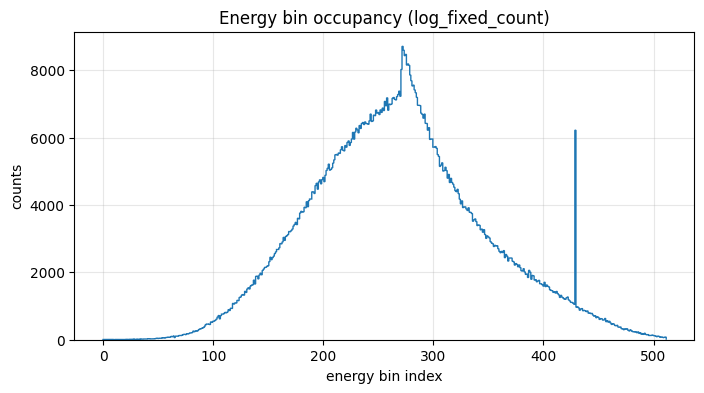

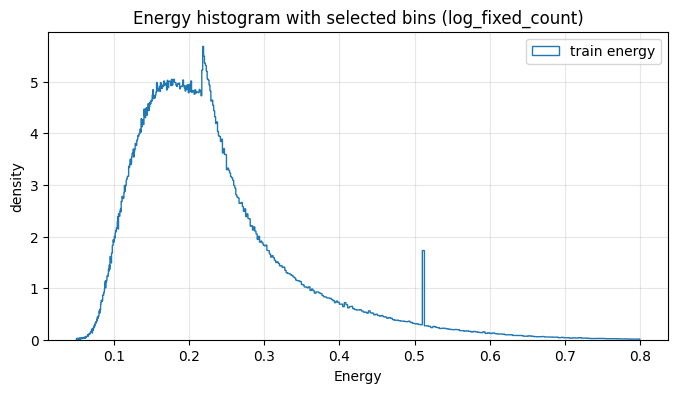

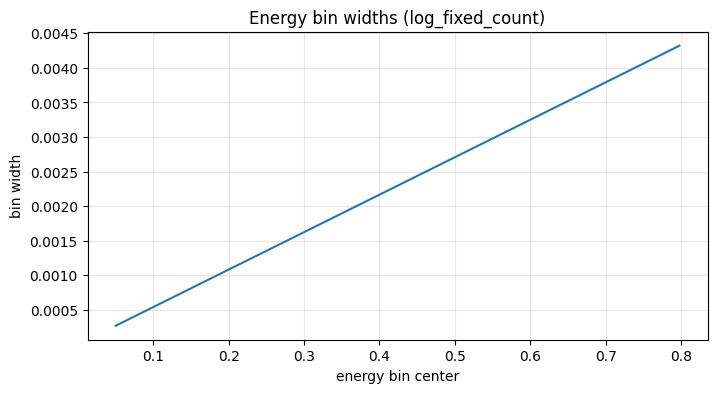

In [161]:
# ==========================================================
# Energy binning diagnostics
# This cell is general and works with all supported modes:
#   1) fixed_width
#   2) min_counts
#   3) log_fixed_count
#
# It assumes that the following objects already exist:
#   - ENERGY_BINNING_MODE
#   - energy_bins
#   - E_idx
#   - E
#   - idx_train
# ==========================================================

# ----------------------------------------------------------
# Training-set energy values and bin indices
# ----------------------------------------------------------
E_train_values = E[idx_train].astype(np.float64)
E_train_idx = E_idx[idx_train].astype(np.int32)

n_energy_bins = len(energy_bins) - 1
energy_bin_centers = 0.5 * (energy_bins[:-1] + energy_bins[1:])
energy_bin_widths = np.diff(energy_bins)

print("Energy binning mode:", ENERGY_BINNING_MODE)
print("Number of energy bins:", n_energy_bins)

print("\nEnergy train min/max:")
print(E_train_values.min(), E_train_values.max())

print("\nFirst bin:", energy_bins[0], energy_bins[1])
print("Last bin :", energy_bins[-2], energy_bins[-1])

print("\nBin width summary:")
print("min width :", energy_bin_widths.min())
print("max width :", energy_bin_widths.max())
print("mean width:", energy_bin_widths.mean())

# ----------------------------------------------------------
# Occupancy check on training set
# ----------------------------------------------------------
counts = np.bincount(E_train_idx, minlength=n_energy_bins)
empty_bins = np.sum(counts == 0)

print("\n--- Energy bin occupancy check ---")
print("min counts:", counts.min())
print("max counts:", counts.max())
print("mean counts:", counts.mean())
print("empty bins:", empty_bins)
print("empty bin fraction:", empty_bins / n_energy_bins)

# ----------------------------------------------------------
# Additional diagnostics depending on mode
# ----------------------------------------------------------
if ENERGY_BINNING_MODE == "fixed_width":
    print("\n--- Fixed-width mode diagnostics ---")
    print("Requested bin width:", BIN_WIDTH)

elif ENERGY_BINNING_MODE == "min_counts":
    print("\n--- Minimum-count mode diagnostics ---")
    print("Initial requested bins:", N_BINS)
    print("Minimum counts threshold:", MIN_COUNTS)
    print("Final number of bins after merging:", n_energy_bins)

elif ENERGY_BINNING_MODE == "log_fixed_count":
    print("\n--- Log-fixed-count mode diagnostics ---")
    logE_train_values = np.log10(E_train_values)
    log_energy_bin_edges = np.log10(energy_bins)
    log_energy_bin_widths = np.diff(log_energy_bin_edges)

    print("Requested bins:", N_BINS)
    print("log10(E) min/max:", logE_train_values.min(), logE_train_values.max())
    print("log-bin width min :", log_energy_bin_widths.min())
    print("log-bin width max :", log_energy_bin_widths.max())
    print("log-bin width mean:", log_energy_bin_widths.mean())

# ----------------------------------------------------------
# Plot occupancy
# ----------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.hist(E_train_idx, bins=np.arange(n_energy_bins + 1) - 0.5, histtype="step")
plt.xlabel("energy bin index")
plt.ylabel("counts")
plt.title(f"Energy bin occupancy ({ENERGY_BINNING_MODE})")
plt.grid(True, alpha=0.3)
plt.show()

# ----------------------------------------------------------
# Plot physical energy histogram with bin edges overlaid
# ----------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.hist(E_train_values, bins=energy_bins, histtype="step", density=True, label="train energy")
plt.xlabel("Energy")
plt.ylabel("density")
plt.title(f"Energy histogram with selected bins ({ENERGY_BINNING_MODE})")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# ----------------------------------------------------------
# Optional: show bin widths as a function of bin center
# Useful especially for min_counts and log_fixed_count modes
# ----------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(energy_bin_centers, energy_bin_widths, linewidth=1.5)
plt.xlabel("energy bin center")
plt.ylabel("bin width")
plt.title(f"Energy bin widths ({ENERGY_BINNING_MODE})")
plt.grid(True, alpha=0.3)
plt.show()

## Model and Training

In [78]:
#### VERSION WITH IMPROVEMENTS TO U_V MODELING AND SAMPLING ####
# ==========================================================
# CVAE_CatEnergy_CatUV
# Improved version:
# - stronger sr / phi_r / phi_v heads
# - smoothed categorical loss for u_v
# - softer sampling for u_v
# - uniform sampling inside the selected u_v bin
# ==========================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


class CVAE_CatEnergy_CatUV(keras.Model):
    """
    Conditional VAE with:
      - categorical energy head
      - Gaussian s_r head
      - categorical u_v head
      - 2D phi_r head
      - 2D phi_v head
    """

    def __init__(
        self,
        n_types,
        n_energy_bins,
        n_uv_bins,
        uv_bin_edges,
        latent_dim=8,
        hidden=(128, 128, 64),
        beta=0.1,
        type_weights=None,

        # Gaussian head control
        min_log_sigma=-6.0,
        max_log_sigma=1.5,

        # Regularization
        lambda_sigma=1e-3,
        sigma_target=-2.0,
        lambda_phi=1e-2,
        lambda_phi_r=1e-2,

        # Reconstruction weights
        w_energy=1.0,
        w_sr=1.0,
        w_uv=1.0,
        w_phi_r=1.0,
        w_phi_v=1.0,
        w_xy=0.0,

        # Geometry
        sphere_R=100.0,

        # New controls for u_v categorical modeling
        uv_label_smoothing=0.08,          # total smoothing mass
        uv_neighbor_smoothing=True,       # spread smoothing on adjacent bins
        uv_sampling_temperature=1.10,     # >1 softer sampling
        energy_sampling_temperature=1.00, # keep energy unchanged unless needed
        sample_uv_uniform_inside_bin=True,
    ):
        super().__init__()

        self.n_types = n_types
        self.n_energy_bins = int(n_energy_bins)
        self.n_uv_bins = int(n_uv_bins)
        self.latent_dim = latent_dim
        self.beta = beta
        self.type_weights = type_weights

        self.min_log_sigma = min_log_sigma
        self.max_log_sigma = max_log_sigma

        self.lambda_sigma = lambda_sigma
        self.sigma_target = sigma_target
        self.lambda_phi = lambda_phi
        self.lambda_phi_r = lambda_phi_r

        self.w_energy = w_energy
        self.w_sr = w_sr
        self.w_uv = w_uv
        self.w_phi_r = w_phi_r
        self.w_phi_v = w_phi_v
        self.w_xy = w_xy

        self.sphere_R = sphere_R

        self.uv_label_smoothing = uv_label_smoothing
        self.uv_neighbor_smoothing = uv_neighbor_smoothing
        self.uv_sampling_temperature = uv_sampling_temperature
        self.energy_sampling_temperature = energy_sampling_temperature
        self.sample_uv_uniform_inside_bin = sample_uv_uniform_inside_bin

        uv_bin_edges = tf.convert_to_tensor(uv_bin_edges, dtype=tf.float32)
        self.uv_bin_edges = uv_bin_edges
        self.uv_bin_centers = 0.5 * (uv_bin_edges[:-1] + uv_bin_edges[1:])

        # ======================================================
        # Encoder
        # Input:
        #   y_cont (5)
        #   energy one-hot (n_energy_bins)
        #   u_v one-hot (n_uv_bins)
        #   cond (n_types)
        # ======================================================
        enc_in = layers.Input(shape=(5 + n_energy_bins + n_uv_bins + n_types,))
        x = enc_in
        for h in hidden:
            x = layers.Dense(h)(x)
            x = layers.LeakyReLU(0.05)(x)

        z_mean = layers.Dense(latent_dim, name="z_mean")(x)
        z_logvar = layers.Dense(latent_dim, name="z_logvar")(x)

        self.encoder = keras.Model(enc_in, [z_mean, z_logvar], name="encoder")

        # ======================================================
        # Decoder backbone
        # Input: z + cond
        # ======================================================
        dec_in = layers.Input(shape=(latent_dim + n_types,))
        x = dec_in
        for h in hidden[::-1]:
            x = layers.Dense(h)(x)
            x = layers.LeakyReLU(0.02)(x)

        self.decoder_backbone = keras.Model(dec_in, x, name="decoder_backbone")

        # ======================================================
        # Decoder heads
        # ======================================================

        # 1) Energy categorical head
        self.energy_logits_head = layers.Dense(self.n_energy_bins, name="energy_logits")

        # 2) s_r Gaussian head (stronger)
        self.sr_head = keras.Sequential([
            layers.Dense(128),
            layers.LeakyReLU(0.05),
            layers.Dense(128),
            layers.LeakyReLU(0.05),
            layers.Dense(64),
            layers.LeakyReLU(0.05),
        ], name="sr_head")

        self.sr_mu_head = layers.Dense(1, name="sr_mu")
        self.sr_logsigma_head = layers.Dense(1, name="sr_logsigma")

        # 3) u_v categorical head (stronger)
        self.uv_head = keras.Sequential([
            layers.Dense(128),
            layers.LeakyReLU(0.05),
            layers.Dense(128),
            layers.LeakyReLU(0.05),
            layers.Dense(64),
            layers.LeakyReLU(0.05),
        ], name="uv_head")

        self.uv_logits_head = layers.Dense(self.n_uv_bins, name="uv_logits")

        # 4) phi_r expressive 2D head (stronger)
        self.phi_r_head = keras.Sequential([
            layers.Dense(128),
            layers.LeakyReLU(0.03),
            layers.Dense(128),
            layers.LeakyReLU(0.03),
            layers.Dense(64),
            layers.LeakyReLU(0.03),
            layers.Dense(2)
        ], name="phi_r_head")

        # 5) phi_v expressive 2D head (much stronger)
        self.phi_v_head = keras.Sequential([
            layers.Dense(64),
            layers.LeakyReLU(0.01),     # Keep phi_v head relatively simple to avoid instability, but increase capacity a bit
            layers.Dense(2)             # Now the decoder learns using a phi_v_loss that combines MSE and angular loss, so it can benefit from a bit more capacity without becoming unstable
        ], name="phi_v_head")

        # ======================================================
        # Metrics
        # ======================================================
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.rec_tracker = keras.metrics.Mean(name="rec")
        self.kl_tracker = keras.metrics.Mean(name="kl")
        self.nll_tracker = keras.metrics.Mean(name="nll")

        self.sigma_reg_tracker = keras.metrics.Mean(name="sigma_reg")
        self.phi_reg_tracker = keras.metrics.Mean(name="phi_reg")
        self.phi_r_reg_tracker = keras.metrics.Mean(name="phi_r_reg")

        self.energy_ce_tracker = keras.metrics.Mean(name="energy_ce")
        self.sr_nll_tracker = keras.metrics.Mean(name="sr_nll")
        self.uv_ce_tracker = keras.metrics.Mean(name="uv_ce")
        self.phi_r_mse_tracker = keras.metrics.Mean(name="phi_r_mse")
        self.phi_v_mse_tracker = keras.metrics.Mean(name="phi_v_mse")
        self.xy_mse_tracker = keras.metrics.Mean(name="xy_mse")

        self.phi_v_ang_tracker = keras.metrics.Mean(name="phi_v_ang")
        self.phi_v_loss_tracker = keras.metrics.Mean(name="phi_v_loss")

    @property
    def metrics(self):
        return [
            self.loss_tracker,
            self.rec_tracker,
            self.kl_tracker,
            self.nll_tracker,
            self.sigma_reg_tracker,
            self.phi_reg_tracker,
            self.phi_r_reg_tracker,
            self.energy_ce_tracker,
            self.sr_nll_tracker,
            self.uv_ce_tracker,
            self.phi_r_mse_tracker,
            self.phi_v_mse_tracker,
            self.phi_v_ang_tracker,
            self.phi_v_loss_tracker,
            self.xy_mse_tracker,
        ]

    # ==========================================================
    # Utilities
    # ==========================================================
    def sample_z(self, z_mean, z_logvar):
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_logvar) * eps

    def _gaussian_nll(self, x, mu, log_sigma):
        sigma2 = tf.exp(2.0 * log_sigma)
        return 0.5 * ((tf.square(x - mu) / sigma2) + 2.0 * log_sigma)

    def _sigma_regularizer(self, params):
        if self.lambda_sigma <= 0:
            return tf.constant(0.0, dtype=tf.float32)

        logsigmas = params["sr_logsigma"]
        return self.lambda_sigma * tf.reduce_mean(
            tf.square(tf.nn.relu(logsigmas - self.sigma_target))
        )

    def _phi_regularizers(self, params):
        phi_r_reg = tf.constant(0.0, tf.float32)
        if self.lambda_phi_r > 0:
            c = params["phi_r"][:, 0]
            s = params["phi_r"][:, 1]
            r2 = c * c + s * s
            phi_r_reg = self.lambda_phi_r * tf.reduce_mean(tf.square(r2 - 1.0))

        phi_v_reg = tf.constant(0.0, tf.float32)
        if self.lambda_phi > 0:
            c = params["phi_v"][:, 0]
            s = params["phi_v"][:, 1]
            r2 = c * c + s * s
            phi_v_reg = self.lambda_phi * tf.reduce_mean(tf.square(r2 - 1.0))

        return phi_v_reg, phi_r_reg

    def _xy_from_sr_phi(self, s_r, phi_pair):
        u_r = tf.tanh(tf.squeeze(s_r, axis=1))

        c = phi_pair[:, 0]
        s = phi_pair[:, 1]

        norm = tf.sqrt(c * c + s * s + 1e-12)
        c = c / norm
        s = s / norm

        sin_theta = tf.sqrt(tf.maximum(0.0, 1.0 - u_r * u_r))

        x = self.sphere_R * sin_theta * c
        y = self.sphere_R * sin_theta * s
        return x, y
    
    def _angular_loss_2d(self, true_pair, pred_pair): # New function to compute angular loss for 2D pairs for phi_v
        ct = true_pair[:, 0]
        st = true_pair[:, 1]

        cp = pred_pair[:, 0]
        sp = pred_pair[:, 1]

        norm = tf.sqrt(cp * cp + sp * sp + 1e-12)
        cp = cp / norm
        sp = sp / norm

        cos_delta = ct * cp + st * sp
        cos_delta = tf.clip_by_value(cos_delta, -1.0, 1.0)

        return 1.0 - cos_delta

    def _decode_params(self, z, cond, training=False):
        x = self.decoder_backbone(tf.concat([z, cond], axis=1), training=training)

        energy_logits = self.energy_logits_head(x)

        sr_feat = self.sr_head(x)
        sr_mu = self.sr_mu_head(sr_feat)
        sr_logsigma = tf.clip_by_value(
            self.sr_logsigma_head(sr_feat),
            self.min_log_sigma,
            self.max_log_sigma
        )

        uv_feat = self.uv_head(x)
        uv_logits = self.uv_logits_head(uv_feat)

        phi_r = self.phi_r_head(x)
        phi_v = self.phi_v_head(x)

        return {
            "energy_logits": energy_logits,
            "sr_mu": sr_mu,
            "sr_logsigma": sr_logsigma,
            "uv_logits": uv_logits,
            "phi_r": phi_r,
            "phi_v": phi_v,
        }

    def _smoothed_categorical_ce(self, labels, logits, n_classes, smoothing=0.0, local_neighbors=False):
        """
        Smoothed categorical CE.
        If local_neighbors=True, smoothing mass is assigned to adjacent bins.
        """
        labels = tf.cast(labels, tf.int32)

        if smoothing <= 0.0:
            return tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=logits)

        onehot = tf.one_hot(labels, depth=n_classes, dtype=tf.float32)

        if not local_neighbors:
            target = onehot * (1.0 - smoothing) + smoothing / tf.cast(n_classes, tf.float32)
        else:
            left_idx = tf.maximum(labels - 1, 0)
            right_idx = tf.minimum(labels + 1, n_classes - 1)

            left = tf.one_hot(left_idx, depth=n_classes, dtype=tf.float32)
            right = tf.one_hot(right_idx, depth=n_classes, dtype=tf.float32)

            same_left = tf.cast(tf.equal(left_idx, labels), tf.float32)
            same_right = tf.cast(tf.equal(right_idx, labels), tf.float32)

            left_w = 0.5 * smoothing * (1.0 - same_left)
            right_w = 0.5 * smoothing * (1.0 - same_right)
            center_w = 1.0 - left_w - right_w

            target = (
                onehot * tf.expand_dims(center_w, 1) +
                left * tf.expand_dims(left_w, 1) +
                right * tf.expand_dims(right_w, 1)
            )

        log_probs = tf.nn.log_softmax(logits, axis=1)
        return -tf.reduce_sum(target * log_probs, axis=1)

    def _reconstruction_terms(self, y_cont_true, E_idx_true, uv_idx_true, params):
        """
        y_cont_true = [s_r_s, cphi_r, sphi_r, cphi_v, sphi_v]
        """
        sr_true = y_cont_true[:, 0:1]
        phi_r_true = y_cont_true[:, 1:3]
        phi_v_true = y_cont_true[:, 3:5]

        # 1) Energy categorical CE
        energy_ce = tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=E_idx_true,
            logits=params["energy_logits"]
        )

        # 2) s_r Gaussian NLL
        sr_nll = tf.squeeze(
            self._gaussian_nll(sr_true, params["sr_mu"], params["sr_logsigma"]),
            axis=1
        )

        # 3) u_v categorical CE with smoothing
        uv_ce = self._smoothed_categorical_ce(
            labels=uv_idx_true,
            logits=params["uv_logits"],
            n_classes=self.n_uv_bins,
            smoothing=self.uv_label_smoothing,
            local_neighbors=self.uv_neighbor_smoothing
        )

        # 4) angular heads
        phi_r_mse = tf.reduce_sum(tf.square(phi_r_true - params["phi_r"]), axis=1)
        phi_v_mse = tf.reduce_sum(tf.square(phi_v_true - params["phi_v"]), axis=1)
        phi_v_ang = self._angular_loss_2d(phi_v_true, params["phi_v"])

        phi_v_loss = phi_v_mse + 0.5 * phi_v_ang # Combine MSE and angular loss for phi_v

        # 5) geometric xy-loss derived from sr + phi_r
        x_true, y_true_xy = self._xy_from_sr_phi(sr_true, phi_r_true)
        x_pred, y_pred_xy = self._xy_from_sr_phi(params["sr_mu"], params["phi_r"])

        xy_mse = tf.square(x_true - x_pred) + tf.square(y_true_xy - y_pred_xy)

        rec_per = (
            self.w_energy * energy_ce +
            self.w_sr     * sr_nll +
            self.w_uv     * uv_ce +
            self.w_phi_r  * phi_r_mse +
            self.w_phi_v  * phi_v_loss +    # Use combined loss for phi_v
            self.w_xy     * xy_mse
        )

        pieces = {
            "energy_ce": energy_ce,
            "sr_nll": sr_nll,
            "uv_ce": uv_ce,
            "phi_r_mse": phi_r_mse,
            "phi_v_mse": phi_v_mse,
            "phi_v_ang": phi_v_ang,
            "phi_v_loss": phi_v_loss,
            "xy_mse": xy_mse,
        }
        return rec_per, pieces

    # ==========================================================
    # Keras train/test
    # ==========================================================
    def train_step(self, data):
        (y_cont, E_idx_true, uv_idx_true, cond), _ = data

        E_onehot = tf.one_hot(E_idx_true, depth=self.n_energy_bins, dtype=tf.float32)
        uv_onehot = tf.one_hot(uv_idx_true, depth=self.n_uv_bins, dtype=tf.float32)

        x_in = tf.concat([y_cont, E_onehot, uv_onehot, cond], axis=1)

        with tf.GradientTape() as tape:
            z_mean, z_logvar = self.encoder(x_in, training=True)
            z = self.sample_z(z_mean, z_logvar)

            params = self._decode_params(z, cond, training=True)
            rec_per, pieces = self._reconstruction_terms(y_cont, E_idx_true, uv_idx_true, params)

            if self.type_weights is not None:
                t_idx = tf.argmax(cond, axis=1, output_type=tf.int32)
                w = tf.gather(self.type_weights, t_idx)
                rec_per_weighted = rec_per * w
            else:
                rec_per_weighted = rec_per

            rec = tf.reduce_mean(rec_per_weighted)
            nll = tf.reduce_mean(rec_per)

            kl_per = -0.5 * tf.reduce_sum(
                1.0 + z_logvar - tf.square(z_mean) - tf.exp(z_logvar),
                axis=1
            )
            kl = tf.reduce_mean(kl_per)

            sigma_reg = self._sigma_regularizer(params)
            phi_reg, phi_r_reg = self._phi_regularizers(params)

            loss = rec + self.beta * kl + sigma_reg + phi_reg + phi_r_reg

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(loss)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        self.nll_tracker.update_state(nll)

        self.sigma_reg_tracker.update_state(sigma_reg)
        self.phi_reg_tracker.update_state(phi_reg)
        self.phi_r_reg_tracker.update_state(phi_r_reg)

        self.energy_ce_tracker.update_state(tf.reduce_mean(pieces["energy_ce"]))
        self.sr_nll_tracker.update_state(tf.reduce_mean(pieces["sr_nll"]))
        self.uv_ce_tracker.update_state(tf.reduce_mean(pieces["uv_ce"]))
        self.phi_r_mse_tracker.update_state(tf.reduce_mean(pieces["phi_r_mse"]))
        self.phi_v_mse_tracker.update_state(tf.reduce_mean(pieces["phi_v_mse"]))
        self.phi_v_ang_tracker.update_state(tf.reduce_mean(pieces["phi_v_ang"]))
        self.phi_v_loss_tracker.update_state(tf.reduce_mean(pieces["phi_v_loss"]))
        self.xy_mse_tracker.update_state(tf.reduce_mean(pieces["xy_mse"]))

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        (y_cont, E_idx_true, uv_idx_true, cond), _ = data

        E_onehot = tf.one_hot(E_idx_true, depth=self.n_energy_bins, dtype=tf.float32)
        uv_onehot = tf.one_hot(uv_idx_true, depth=self.n_uv_bins, dtype=tf.float32)

        x_in = tf.concat([y_cont, E_onehot, uv_onehot, cond], axis=1)

        z_mean, z_logvar = self.encoder(x_in, training=False)
        z = self.sample_z(z_mean, z_logvar)

        params = self._decode_params(z, cond, training=False)
        rec_per, pieces = self._reconstruction_terms(y_cont, E_idx_true, uv_idx_true, params)

        if self.type_weights is not None:
            t_idx = tf.argmax(cond, axis=1, output_type=tf.int32)
            w = tf.gather(self.type_weights, t_idx)
            rec_per_weighted = rec_per * w
        else:
            rec_per_weighted = rec_per

        rec = tf.reduce_mean(rec_per_weighted)
        nll = tf.reduce_mean(rec_per)

        kl_per = -0.5 * tf.reduce_sum(
            1.0 + z_logvar - tf.square(z_mean) - tf.exp(z_logvar),
            axis=1
        )
        kl = tf.reduce_mean(kl_per)

        sigma_reg = self._sigma_regularizer(params)
        phi_reg, phi_r_reg = self._phi_regularizers(params)

        loss = rec + self.beta * kl + sigma_reg + phi_reg + phi_r_reg

        self.loss_tracker.update_state(loss)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        self.nll_tracker.update_state(nll)

        self.sigma_reg_tracker.update_state(sigma_reg)
        self.phi_reg_tracker.update_state(phi_reg)
        self.phi_r_reg_tracker.update_state(phi_r_reg)

        self.energy_ce_tracker.update_state(tf.reduce_mean(pieces["energy_ce"]))
        self.sr_nll_tracker.update_state(tf.reduce_mean(pieces["sr_nll"]))
        self.uv_ce_tracker.update_state(tf.reduce_mean(pieces["uv_ce"]))
        self.phi_r_mse_tracker.update_state(tf.reduce_mean(pieces["phi_r_mse"]))
        self.phi_v_mse_tracker.update_state(tf.reduce_mean(pieces["phi_v_mse"]))
        self.phi_v_ang_tracker.update_state(tf.reduce_mean(pieces["phi_v_ang"]))
        self.phi_v_loss_tracker.update_state(tf.reduce_mean(pieces["phi_v_loss"]))
        self.xy_mse_tracker.update_state(tf.reduce_mean(pieces["xy_mse"]))

        return {m.name: m.result() for m in self.metrics}

    # ==========================================================
    # Sampling / generation
    # ==========================================================
    @tf.function(reduce_retracing=True)
    def decode(self, z, cond):
        return self._decode_params(z, cond, training=False)

    def _sample_energy_from_logits(self, logits):
        logits = logits / self.energy_sampling_temperature
        idx = tf.random.categorical(logits, num_samples=1)
        idx = tf.cast(tf.squeeze(idx, axis=1), tf.int32)
        return idx

    def _sample_uv_from_logits(self, logits):
        logits = logits / self.uv_sampling_temperature
        idx = tf.random.categorical(logits, num_samples=1)
        idx = tf.cast(tf.squeeze(idx, axis=1), tf.int32)
        return idx

    def _sample_uv_value_from_idx(self, uv_idx):
        left = tf.gather(self.uv_bin_edges[:-1], uv_idx)
        right = tf.gather(self.uv_bin_edges[1:], uv_idx)

        if self.sample_uv_uniform_inside_bin:
            u = tf.random.uniform(tf.shape(left), 0.0, 1.0, dtype=tf.float32)
            uv_value = left + u * (right - left)
        else:
            uv_value = 0.5 * (left + right)

        return tf.expand_dims(uv_value, axis=1)

    def generate(self, cond, n_samples):
        """
        Generate:
          - energy_idx
          - y_cont = [s_r_s, cphi_r, sphi_r, cphi_v, sphi_v]
          - uv_idx
          - uv_value
        """
        z = tf.random.normal((n_samples, self.latent_dim))
        params = self.decode(z, cond)

        # 1) Energy categorical
        energy_idx = self._sample_energy_from_logits(params["energy_logits"])

        # 2) s_r Gaussian
        sr_eps = tf.random.normal(tf.shape(params["sr_mu"]))
        sr_s = params["sr_mu"] + tf.exp(params["sr_logsigma"]) * sr_eps

        # 3) u_v categorical
        uv_idx = self._sample_uv_from_logits(params["uv_logits"])
        uv_value = self._sample_uv_value_from_idx(uv_idx)

        # 4) angular heads
        phi_r = params["phi_r"]
        phi_v = params["phi_v"]

        y_cont = tf.concat([sr_s, phi_r, phi_v], axis=1)

        return {
            "energy_idx": energy_idx,
            "uv_idx": uv_idx,
            "uv_value": uv_value,
            "y_cont": y_cont,
            "params": params,
        }

In [85]:
#### VERSION WITH IMPROVEMENTS TO U_V MODELING, PHI_V LOSS, AND DIRECTION GEOMETRY ####
# ==========================================================
# CVAE_CatEnergy_CatUV
#
# Improved version:
# - stronger sr / phi_r heads
# - simple but stable phi_v head
# - smoothed categorical loss for u_v
# - softer categorical sampling for u_v
# - uniform sampling inside the selected u_v bin
# - phi_v loss computed on normalized vectors
# - additional angular loss for phi_v
# - NEW: small physical loss on reconstructed (vx, vy)
#        to help recover the horns in cos(phi_v) / sin(phi_v)
# ==========================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


class CVAE_CatEnergy_CatUV(keras.Model):
    """
    Conditional VAE with:
      - categorical energy head
      - Gaussian s_r head
      - categorical u_v head
      - 2D phi_r head
      - 2D phi_v head

    Continuous training input/output:
      y_cont = [s_r_s, cphi_r, sphi_r, cphi_v, sphi_v]

    Categorical targets:
      - energy_idx
      - uv_idx
    """

    def __init__(
        self,
        n_types,
        n_energy_bins,
        n_uv_bins,
        uv_bin_edges,
        latent_dim=8,
        hidden=(128, 128, 64),
        beta=0.1,
        type_weights=None,

        # Gaussian head control
        min_log_sigma=-6.0,
        max_log_sigma=1.5,

        # Regularization
        lambda_sigma=1e-3,
        sigma_target=-2.0,
        lambda_phi=1e-2,
        lambda_phi_r=1e-2,

        # Reconstruction weights
        w_energy=1.0,
        w_sr=1.0,
        w_uv=1.0,
        w_phi_r=1.0,
        w_phi_v=1.0,
        w_xy=0.0,

        # NEW: small physical loss on reconstructed vx, vy
        w_vxy=0.05,

        # Geometry
        sphere_R=100.0,

        # Controls for u_v categorical modeling
        uv_label_smoothing=0.08,
        uv_neighbor_smoothing=True,
        uv_sampling_temperature=1.10,
        energy_sampling_temperature=1.00,
        sample_uv_uniform_inside_bin=True,

        # NEW: relative weight of angular loss inside phi_v loss
        phi_v_ang_weight=0.8,
    ):
        super().__init__()

        self.n_types = n_types
        self.n_energy_bins = int(n_energy_bins)
        self.n_uv_bins = int(n_uv_bins)
        self.latent_dim = latent_dim
        self.beta = beta
        self.type_weights = type_weights

        self.min_log_sigma = min_log_sigma
        self.max_log_sigma = max_log_sigma

        self.lambda_sigma = lambda_sigma
        self.sigma_target = sigma_target
        self.lambda_phi = lambda_phi
        self.lambda_phi_r = lambda_phi_r

        self.w_energy = w_energy
        self.w_sr = w_sr
        self.w_uv = w_uv
        self.w_phi_r = w_phi_r
        self.w_phi_v = w_phi_v
        self.w_xy = w_xy
        self.w_vxy = w_vxy

        self.sphere_R = sphere_R

        self.uv_label_smoothing = uv_label_smoothing
        self.uv_neighbor_smoothing = uv_neighbor_smoothing
        self.uv_sampling_temperature = uv_sampling_temperature
        self.energy_sampling_temperature = energy_sampling_temperature
        self.sample_uv_uniform_inside_bin = sample_uv_uniform_inside_bin

        self.phi_v_ang_weight = phi_v_ang_weight

        uv_bin_edges = tf.convert_to_tensor(uv_bin_edges, dtype=tf.float32)
        self.uv_bin_edges = uv_bin_edges
        self.uv_bin_centers = 0.5 * (uv_bin_edges[:-1] + uv_bin_edges[1:])

        # ======================================================
        # Encoder
        # Input:
        #   y_cont (5)
        #   energy one-hot (n_energy_bins)
        #   u_v one-hot (n_uv_bins)
        #   cond (n_types)
        # ======================================================
        enc_in = layers.Input(shape=(5 + n_energy_bins + n_uv_bins + n_types,))
        x = enc_in
        for h in hidden:
            x = layers.Dense(h)(x)
            x = layers.LeakyReLU(0.05)(x)

        z_mean = layers.Dense(latent_dim, name="z_mean")(x)
        z_logvar = layers.Dense(latent_dim, name="z_logvar")(x)

        self.encoder = keras.Model(enc_in, [z_mean, z_logvar], name="encoder")

        # ======================================================
        # Decoder backbone
        # Input: z + cond
        # ======================================================
        dec_in = layers.Input(shape=(latent_dim + n_types,))
        x = dec_in
        for h in hidden[::-1]:
            x = layers.Dense(h)(x)
            x = layers.LeakyReLU(0.02)(x)

        self.decoder_backbone = keras.Model(dec_in, x, name="decoder_backbone")

        # ======================================================
        # Decoder heads
        # ======================================================

        # 1) Energy categorical head
        self.energy_logits_head = layers.Dense(self.n_energy_bins, name="energy_logits")

        # 2) s_r Gaussian head
        self.sr_head = keras.Sequential([
            layers.Dense(128),
            layers.LeakyReLU(0.05),
            layers.Dense(128),
            layers.LeakyReLU(0.05),
            layers.Dense(64),
            layers.LeakyReLU(0.05),
        ], name="sr_head")

        self.sr_mu_head = layers.Dense(1, name="sr_mu")
        self.sr_logsigma_head = layers.Dense(1, name="sr_logsigma")

        # 3) u_v categorical head
        self.uv_head = keras.Sequential([
            layers.Dense(128),
            layers.LeakyReLU(0.05),
            layers.Dense(128),
            layers.LeakyReLU(0.05),
            layers.Dense(64),
            layers.LeakyReLU(0.05),
        ], name="uv_head")

        self.uv_logits_head = layers.Dense(self.n_uv_bins, name="uv_logits")

        # 4) phi_r head
        self.phi_r_head = keras.Sequential([
            layers.Dense(128),
            layers.LeakyReLU(0.03),
            layers.Dense(128),
            layers.LeakyReLU(0.03),
            layers.Dense(64),
            layers.LeakyReLU(0.03),
            layers.Dense(2)
        ], name="phi_r_head")

        # 5) phi_v head
        # Kept deliberately simple and stable.
        # The main improvement comes from a better loss, not from making the head huge.
        self.phi_v_head = keras.Sequential([
            layers.Dense(64),
            layers.LeakyReLU(0.01),
            layers.Dense(2)
        ], name="phi_v_head")

        # ======================================================
        # Metrics
        # ======================================================
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.rec_tracker = keras.metrics.Mean(name="rec")
        self.kl_tracker = keras.metrics.Mean(name="kl")
        self.nll_tracker = keras.metrics.Mean(name="nll")

        self.sigma_reg_tracker = keras.metrics.Mean(name="sigma_reg")
        self.phi_reg_tracker = keras.metrics.Mean(name="phi_reg")
        self.phi_r_reg_tracker = keras.metrics.Mean(name="phi_r_reg")

        self.energy_ce_tracker = keras.metrics.Mean(name="energy_ce")
        self.sr_nll_tracker = keras.metrics.Mean(name="sr_nll")
        self.uv_ce_tracker = keras.metrics.Mean(name="uv_ce")
        self.phi_r_mse_tracker = keras.metrics.Mean(name="phi_r_mse")
        self.phi_v_mse_tracker = keras.metrics.Mean(name="phi_v_mse")
        self.phi_v_ang_tracker = keras.metrics.Mean(name="phi_v_ang")
        self.phi_v_loss_tracker = keras.metrics.Mean(name="phi_v_loss")
        self.vxy_mse_tracker = keras.metrics.Mean(name="vxy_mse")
        self.xy_mse_tracker = keras.metrics.Mean(name="xy_mse")

    @property
    def metrics(self):
        return [
            self.loss_tracker,
            self.rec_tracker,
            self.kl_tracker,
            self.nll_tracker,
            self.sigma_reg_tracker,
            self.phi_reg_tracker,
            self.phi_r_reg_tracker,
            self.energy_ce_tracker,
            self.sr_nll_tracker,
            self.uv_ce_tracker,
            self.phi_r_mse_tracker,
            self.phi_v_mse_tracker,
            self.phi_v_ang_tracker,
            self.phi_v_loss_tracker,
            self.vxy_mse_tracker,
            self.xy_mse_tracker,
        ]

    # ==========================================================
    # Utilities
    # ==========================================================
    def sample_z(self, z_mean, z_logvar):
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_logvar) * eps

    def _gaussian_nll(self, x, mu, log_sigma):
        sigma2 = tf.exp(2.0 * log_sigma)
        return 0.5 * ((tf.square(x - mu) / sigma2) + 2.0 * log_sigma)

    def _sigma_regularizer(self, params):
        if self.lambda_sigma <= 0:
            return tf.constant(0.0, dtype=tf.float32)

        logsigmas = params["sr_logsigma"]
        return self.lambda_sigma * tf.reduce_mean(
            tf.square(tf.nn.relu(logsigmas - self.sigma_target))
        )

    def _phi_regularizers(self, params):
        """
        Unit-circle regularization for both angular heads.
        This keeps the raw predicted vectors close to the unit circle.
        """
        phi_r_reg = tf.constant(0.0, tf.float32)
        if self.lambda_phi_r > 0:
            c = params["phi_r"][:, 0]
            s = params["phi_r"][:, 1]
            r2 = c * c + s * s
            phi_r_reg = self.lambda_phi_r * tf.reduce_mean(tf.square(r2 - 1.0))

        phi_v_reg = tf.constant(0.0, tf.float32)
        if self.lambda_phi > 0:
            c = params["phi_v"][:, 0]
            s = params["phi_v"][:, 1]
            r2 = c * c + s * s
            phi_v_reg = self.lambda_phi * tf.reduce_mean(tf.square(r2 - 1.0))

        return phi_v_reg, phi_r_reg

    def _normalize_2d_pair(self, pair):
        """
        Normalize a 2D vector pair (c, s) to the unit circle.
        This is used in the phi losses so that the model is penalized
        on direction/orientation rather than raw amplitude.
        """
        norm = tf.sqrt(tf.reduce_sum(tf.square(pair), axis=1, keepdims=True) + 1e-12)
        return pair / norm

    def _xy_from_sr_phi(self, s_r, phi_pair):
        """
        Reconstruct x and y from s_r and a 2D angular pair.
        """
        u_r = tf.tanh(tf.squeeze(s_r, axis=1))

        phi_pair = self._normalize_2d_pair(phi_pair)
        c = phi_pair[:, 0]
        s = phi_pair[:, 1]

        sin_theta = tf.sqrt(tf.maximum(0.0, 1.0 - u_r * u_r))

        x = self.sphere_R * sin_theta * c
        y = self.sphere_R * sin_theta * s
        return x, y

    def _angular_loss_2d(self, true_pair, pred_pair):
        """
        Angular loss between two 2D direction pairs.
        The prediction is normalized before comparing angles.
        """
        true_pair = self._normalize_2d_pair(true_pair)
        pred_pair = self._normalize_2d_pair(pred_pair)

        cos_delta = tf.reduce_sum(true_pair * pred_pair, axis=1)
        cos_delta = tf.clip_by_value(cos_delta, -1.0, 1.0)

        return 1.0 - cos_delta

    def _expected_uv_from_logits(self, logits):
        """
        Compute the expected continuous u_v value under the predicted
        categorical distribution.

        This gives a smooth, differentiable estimate of u_v and is much
        better than sampling during training when building geometry-based losses.
        """
        probs = tf.nn.softmax(logits, axis=1)                    # (B, n_uv_bins)
        centers = tf.reshape(self.uv_bin_centers, [1, -1])      # (1, n_uv_bins)
        uv_exp = tf.reduce_sum(probs * centers, axis=1)         # (B,)
        return uv_exp

    def _vxvy_from_uv_phi(self, uv, phi_pair):
        """
        Reconstruct (vx, vy) from continuous u_v and normalized phi_v pair.
        """
        phi_pair = self._normalize_2d_pair(phi_pair)

        c = phi_pair[:, 0]
        s = phi_pair[:, 1]

        uv = tf.clip_by_value(uv, -1.0 + 1e-6, 1.0 - 1e-6)
        sin_theta = tf.sqrt(tf.maximum(0.0, 1.0 - tf.square(uv)))

        vx = sin_theta * c
        vy = sin_theta * s
        return vx, vy

    def _decode_params(self, z, cond, training=False):
        x = self.decoder_backbone(tf.concat([z, cond], axis=1), training=training)

        energy_logits = self.energy_logits_head(x)

        sr_feat = self.sr_head(x)
        sr_mu = self.sr_mu_head(sr_feat)
        sr_logsigma = tf.clip_by_value(
            self.sr_logsigma_head(sr_feat),
            self.min_log_sigma,
            self.max_log_sigma
        )

        uv_feat = self.uv_head(x)
        uv_logits = self.uv_logits_head(uv_feat)

        phi_r = self.phi_r_head(x)
        phi_v = self.phi_v_head(x)

        return {
            "energy_logits": energy_logits,
            "sr_mu": sr_mu,
            "sr_logsigma": sr_logsigma,
            "uv_logits": uv_logits,
            "phi_r": phi_r,
            "phi_v": phi_v,
        }

    def _smoothed_categorical_ce(self, labels, logits, n_classes, smoothing=0.0, local_neighbors=False):
        """
        Smoothed categorical cross-entropy.
        If local_neighbors=True, smoothing mass is assigned to adjacent bins.
        """
        labels = tf.cast(labels, tf.int32)

        if smoothing <= 0.0:
            return tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=logits)

        onehot = tf.one_hot(labels, depth=n_classes, dtype=tf.float32)

        if not local_neighbors:
            target = onehot * (1.0 - smoothing) + smoothing / tf.cast(n_classes, tf.float32)
        else:
            left_idx = tf.maximum(labels - 1, 0)
            right_idx = tf.minimum(labels + 1, n_classes - 1)

            left = tf.one_hot(left_idx, depth=n_classes, dtype=tf.float32)
            right = tf.one_hot(right_idx, depth=n_classes, dtype=tf.float32)

            same_left = tf.cast(tf.equal(left_idx, labels), tf.float32)
            same_right = tf.cast(tf.equal(right_idx, labels), tf.float32)

            left_w = 0.5 * smoothing * (1.0 - same_left)
            right_w = 0.5 * smoothing * (1.0 - same_right)
            center_w = 1.0 - left_w - right_w

            target = (
                onehot * tf.expand_dims(center_w, 1) +
                left * tf.expand_dims(left_w, 1) +
                right * tf.expand_dims(right_w, 1)
            )

        log_probs = tf.nn.log_softmax(logits, axis=1)
        return -tf.reduce_sum(target * log_probs, axis=1)

    def _reconstruction_terms(self, y_cont_true, E_idx_true, uv_idx_true, params):
        """
        y_cont_true = [s_r_s, cphi_r, sphi_r, cphi_v, sphi_v]
        """
        sr_true = y_cont_true[:, 0:1]
        phi_r_true = y_cont_true[:, 1:3]
        phi_v_true = y_cont_true[:, 3:5]

        # ------------------------------------------------------
        # 1) Energy categorical CE
        # ------------------------------------------------------
        energy_ce = tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=E_idx_true,
            logits=params["energy_logits"]
        )

        # ------------------------------------------------------
        # 2) s_r Gaussian NLL
        # ------------------------------------------------------
        sr_nll = tf.squeeze(
            self._gaussian_nll(sr_true, params["sr_mu"], params["sr_logsigma"]),
            axis=1
        )

        # ------------------------------------------------------
        # 3) u_v categorical CE with local smoothing
        # ------------------------------------------------------
        uv_ce = self._smoothed_categorical_ce(
            labels=uv_idx_true,
            logits=params["uv_logits"],
            n_classes=self.n_uv_bins,
            smoothing=self.uv_label_smoothing,
            local_neighbors=self.uv_neighbor_smoothing
        )

        # ------------------------------------------------------
        # 4) Angular heads
        # ------------------------------------------------------

        # phi_r is still trained with standard MSE on its raw pair
        phi_r_mse = tf.reduce_sum(tf.square(phi_r_true - params["phi_r"]), axis=1)

        # For phi_v, normalize the predicted pair before comparing it.
        # This makes the loss focus on orientation instead of vector norm.
        phi_v_pred_unit = self._normalize_2d_pair(params["phi_v"])

        # MSE on normalized angular vector
        phi_v_mse = tf.reduce_sum(tf.square(phi_v_true - phi_v_pred_unit), axis=1)

        # Angular loss directly on orientation
        phi_v_ang = self._angular_loss_2d(phi_v_true, params["phi_v"])

        # Combined phi_v loss:
        # - normalized MSE keeps the vector close in Cartesian angular space
        # - angular loss improves directional alignment and helps recover extremes
        phi_v_loss = phi_v_mse + self.phi_v_ang_weight * phi_v_ang

        # ------------------------------------------------------
        # 5) Geometric xy-loss derived from sr + phi_r
        # ------------------------------------------------------
        x_true, y_true_xy = self._xy_from_sr_phi(sr_true, phi_r_true)
        x_pred, y_pred_xy = self._xy_from_sr_phi(params["sr_mu"], params["phi_r"])

        xy_mse = tf.square(x_true - x_pred) + tf.square(y_true_xy - y_pred_xy)

        # ------------------------------------------------------
        # 6) NEW physical loss on reconstructed vx, vy
        # ------------------------------------------------------
        # Use true continuous u_v from the center of the target bin
        uv_true = tf.gather(self.uv_bin_centers, uv_idx_true)

        # Use smooth expected u_v from predicted categorical probabilities
        uv_pred = self._expected_uv_from_logits(params["uv_logits"])

        vx_true, vy_true = self._vxvy_from_uv_phi(uv_true, phi_v_true)
        vx_pred, vy_pred = self._vxvy_from_uv_phi(uv_pred, params["phi_v"])

        vxy_mse = tf.square(vx_true - vx_pred) + tf.square(vy_true - vy_pred)

        # ------------------------------------------------------
        # Total reconstruction loss
        # ------------------------------------------------------
        rec_per = (
            self.w_energy * energy_ce +
            self.w_sr     * sr_nll +
            self.w_uv     * uv_ce +
            self.w_phi_r  * phi_r_mse +
            self.w_phi_v  * phi_v_loss +
            self.w_xy     * xy_mse +
            self.w_vxy    * vxy_mse
        )

        pieces = {
            "energy_ce": energy_ce,
            "sr_nll": sr_nll,
            "uv_ce": uv_ce,
            "phi_r_mse": phi_r_mse,
            "phi_v_mse": phi_v_mse,
            "phi_v_ang": phi_v_ang,
            "phi_v_loss": phi_v_loss,
            "vxy_mse": vxy_mse,
            "xy_mse": xy_mse,
        }
        return rec_per, pieces

    # ==========================================================
    # Keras train/test
    # ==========================================================
    def train_step(self, data):
        (y_cont, E_idx_true, uv_idx_true, cond), _ = data

        E_onehot = tf.one_hot(E_idx_true, depth=self.n_energy_bins, dtype=tf.float32)
        uv_onehot = tf.one_hot(uv_idx_true, depth=self.n_uv_bins, dtype=tf.float32)

        x_in = tf.concat([y_cont, E_onehot, uv_onehot, cond], axis=1)

        with tf.GradientTape() as tape:
            z_mean, z_logvar = self.encoder(x_in, training=True)
            z = self.sample_z(z_mean, z_logvar)

            params = self._decode_params(z, cond, training=True)
            rec_per, pieces = self._reconstruction_terms(y_cont, E_idx_true, uv_idx_true, params)

            if self.type_weights is not None:
                t_idx = tf.argmax(cond, axis=1, output_type=tf.int32)
                w = tf.gather(self.type_weights, t_idx)
                rec_per_weighted = rec_per * w
            else:
                rec_per_weighted = rec_per

            rec = tf.reduce_mean(rec_per_weighted)
            nll = tf.reduce_mean(rec_per)

            kl_per = -0.5 * tf.reduce_sum(
                1.0 + z_logvar - tf.square(z_mean) - tf.exp(z_logvar),
                axis=1
            )
            kl = tf.reduce_mean(kl_per)

            sigma_reg = self._sigma_regularizer(params)
            phi_reg, phi_r_reg = self._phi_regularizers(params)

            loss = rec + self.beta * kl + sigma_reg + phi_reg + phi_r_reg

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(loss)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        self.nll_tracker.update_state(nll)

        self.sigma_reg_tracker.update_state(sigma_reg)
        self.phi_reg_tracker.update_state(phi_reg)
        self.phi_r_reg_tracker.update_state(phi_r_reg)

        self.energy_ce_tracker.update_state(tf.reduce_mean(pieces["energy_ce"]))
        self.sr_nll_tracker.update_state(tf.reduce_mean(pieces["sr_nll"]))
        self.uv_ce_tracker.update_state(tf.reduce_mean(pieces["uv_ce"]))
        self.phi_r_mse_tracker.update_state(tf.reduce_mean(pieces["phi_r_mse"]))
        self.phi_v_mse_tracker.update_state(tf.reduce_mean(pieces["phi_v_mse"]))
        self.phi_v_ang_tracker.update_state(tf.reduce_mean(pieces["phi_v_ang"]))
        self.phi_v_loss_tracker.update_state(tf.reduce_mean(pieces["phi_v_loss"]))
        self.vxy_mse_tracker.update_state(tf.reduce_mean(pieces["vxy_mse"]))
        self.xy_mse_tracker.update_state(tf.reduce_mean(pieces["xy_mse"]))

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        (y_cont, E_idx_true, uv_idx_true, cond), _ = data

        E_onehot = tf.one_hot(E_idx_true, depth=self.n_energy_bins, dtype=tf.float32)
        uv_onehot = tf.one_hot(uv_idx_true, depth=self.n_uv_bins, dtype=tf.float32)

        x_in = tf.concat([y_cont, E_onehot, uv_onehot, cond], axis=1)

        z_mean, z_logvar = self.encoder(x_in, training=False)
        z = self.sample_z(z_mean, z_logvar)

        params = self._decode_params(z, cond, training=False)
        rec_per, pieces = self._reconstruction_terms(y_cont, E_idx_true, uv_idx_true, params)

        if self.type_weights is not None:
            t_idx = tf.argmax(cond, axis=1, output_type=tf.int32)
            w = tf.gather(self.type_weights, t_idx)
            rec_per_weighted = rec_per * w
        else:
            rec_per_weighted = rec_per

        rec = tf.reduce_mean(rec_per_weighted)
        nll = tf.reduce_mean(rec_per)

        kl_per = -0.5 * tf.reduce_sum(
            1.0 + z_logvar - tf.square(z_mean) - tf.exp(z_logvar),
            axis=1
        )
        kl = tf.reduce_mean(kl_per)

        sigma_reg = self._sigma_regularizer(params)
        phi_reg, phi_r_reg = self._phi_regularizers(params)

        loss = rec + self.beta * kl + sigma_reg + phi_reg + phi_r_reg

        self.loss_tracker.update_state(loss)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        self.nll_tracker.update_state(nll)

        self.sigma_reg_tracker.update_state(sigma_reg)
        self.phi_reg_tracker.update_state(phi_reg)
        self.phi_r_reg_tracker.update_state(phi_r_reg)

        self.energy_ce_tracker.update_state(tf.reduce_mean(pieces["energy_ce"]))
        self.sr_nll_tracker.update_state(tf.reduce_mean(pieces["sr_nll"]))
        self.uv_ce_tracker.update_state(tf.reduce_mean(pieces["uv_ce"]))
        self.phi_r_mse_tracker.update_state(tf.reduce_mean(pieces["phi_r_mse"]))
        self.phi_v_mse_tracker.update_state(tf.reduce_mean(pieces["phi_v_mse"]))
        self.phi_v_ang_tracker.update_state(tf.reduce_mean(pieces["phi_v_ang"]))
        self.phi_v_loss_tracker.update_state(tf.reduce_mean(pieces["phi_v_loss"]))
        self.vxy_mse_tracker.update_state(tf.reduce_mean(pieces["vxy_mse"]))
        self.xy_mse_tracker.update_state(tf.reduce_mean(pieces["xy_mse"]))

        return {m.name: m.result() for m in self.metrics}

    # ==========================================================
    # Sampling / generation
    # ==========================================================
    @tf.function(reduce_retracing=True)
    def decode(self, z, cond):
        return self._decode_params(z, cond, training=False)

    def _sample_energy_from_logits(self, logits):
        logits = logits / self.energy_sampling_temperature
        idx = tf.random.categorical(logits, num_samples=1)
        idx = tf.cast(tf.squeeze(idx, axis=1), tf.int32)
        return idx

    def _sample_uv_from_logits(self, logits):
        logits = logits / self.uv_sampling_temperature
        idx = tf.random.categorical(logits, num_samples=1)
        idx = tf.cast(tf.squeeze(idx, axis=1), tf.int32)
        return idx

    def _sample_uv_value_from_idx(self, uv_idx):
        """
        Convert sampled u_v bin index to a continuous value.

        Using uniform sampling inside the selected bin avoids artificial spikes
        at the bin centers during generation.
        """
        left = tf.gather(self.uv_bin_edges[:-1], uv_idx)
        right = tf.gather(self.uv_bin_edges[1:], uv_idx)

        if self.sample_uv_uniform_inside_bin:
            u = tf.random.uniform(tf.shape(left), 0.0, 1.0, dtype=tf.float32)
            uv_value = left + u * (right - left)
        else:
            uv_value = 0.5 * (left + right)

        return tf.expand_dims(uv_value, axis=1)

    def generate(self, cond, n_samples):
        """
        Generate:
          - energy_idx
          - uv_idx
          - uv_value
          - y_cont = [s_r_s, cphi_r, sphi_r, cphi_v, sphi_v]
        """
        z = tf.random.normal((n_samples, self.latent_dim))
        params = self.decode(z, cond)

        # 1) Energy categorical
        energy_idx = self._sample_energy_from_logits(params["energy_logits"])

        # 2) s_r Gaussian
        sr_eps = tf.random.normal(tf.shape(params["sr_mu"]))
        sr_s = params["sr_mu"] + tf.exp(params["sr_logsigma"]) * sr_eps

        # 3) u_v categorical
        uv_idx = self._sample_uv_from_logits(params["uv_logits"])
        uv_value = self._sample_uv_value_from_idx(uv_idx)

        # 4) Angular heads
        phi_r = params["phi_r"]
        phi_v = params["phi_v"]

        y_cont = tf.concat([sr_s, phi_r, phi_v], axis=1)

        return {
            "energy_idx": energy_idx,
            "uv_idx": uv_idx,
            "uv_value": uv_value,
            "y_cont": y_cont,
            "params": params,
        }

In [162]:
#### VERSION WITH DECODER SPLIT BETWEEN POSITION AND DIRECTION ####
# ==========================================================
# CVAE_CatEnergy_CatUV
#
# Decoder split version:
# - shared decoder backbone
# - dedicated position branch for s_r and phi_r
# - dedicated direction branch for u_v and phi_v
# - dedicated energy branch for energy logits
#
# This is meant to reduce task interference between:
#   - position reconstruction: s_r, phi_r -> x, y, z
#   - direction reconstruction: u_v, phi_v -> vx, vy, vz
#
# The rest of the improvements are preserved:
# - smoothed categorical loss for u_v
# - softer categorical sampling for u_v
# - uniform sampling inside the selected u_v bin
# - phi_v loss computed on normalized vectors
# - additional angular loss for phi_v
# - small physical loss on reconstructed (vx, vy)
# ==========================================================

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


class CVAE_CatEnergy_CatUV(keras.Model):
    """
    Conditional VAE with:
      - categorical energy head
      - Gaussian s_r head
      - categorical u_v head
      - 2D phi_r head
      - 2D phi_v head

    Continuous training input/output:
      y_cont = [s_r_s, cphi_r, sphi_r, cphi_v, sphi_v]

    Categorical targets:
      - energy_idx
      - uv_idx
    """

    def __init__(
        self,
        n_types,
        n_energy_bins,
        n_uv_bins,
        uv_bin_edges,
        latent_dim=8,
        hidden=(128, 128, 64),
        beta=0.1,
        type_weights=None,

        # Gaussian head control
        min_log_sigma=-6.0,
        max_log_sigma=1.5,

        # Regularization
        lambda_sigma=1e-3,
        sigma_target=-2.0,
        lambda_phi=1e-2,
        lambda_phi_r=1e-2,

        # Reconstruction weights
        w_energy=1.0,
        w_sr=1.0,
        w_uv=1.0,
        w_phi_r=1.0,
        w_phi_v=1.0,
        w_xy=0.0,
        w_vxy=0.05,
        w_ur = 0.01,

        # Geometry
        sphere_R=100.0,

        # Controls for u_v categorical modeling
        uv_label_smoothing=0.08,
        uv_neighbor_smoothing=True,
        uv_sampling_temperature=1.10,
        energy_sampling_temperature=1.00,
        sample_uv_uniform_inside_bin=True,

        # Relative weights inside phi_v loss
        phi_v_mse_weight=0.5,
        phi_v_ang_weight=1.2,
    ):
        super().__init__()

        self.n_types = n_types
        self.n_energy_bins = int(n_energy_bins)
        self.n_uv_bins = int(n_uv_bins)
        self.latent_dim = latent_dim
        self.beta = beta
        self.type_weights = type_weights

        self.min_log_sigma = min_log_sigma
        self.max_log_sigma = max_log_sigma

        self.lambda_sigma = lambda_sigma
        self.sigma_target = sigma_target
        self.lambda_phi = lambda_phi
        self.lambda_phi_r = lambda_phi_r

        self.w_energy = w_energy
        self.w_sr = w_sr
        self.w_uv = w_uv
        self.w_phi_r = w_phi_r
        self.w_phi_v = w_phi_v
        self.w_xy = w_xy
        self.w_vxy = w_vxy
        self.w_ur = w_ur

        self.sphere_R = sphere_R

        self.uv_label_smoothing = uv_label_smoothing
        self.uv_neighbor_smoothing = uv_neighbor_smoothing
        self.uv_sampling_temperature = uv_sampling_temperature
        self.energy_sampling_temperature = energy_sampling_temperature
        self.sample_uv_uniform_inside_bin = sample_uv_uniform_inside_bin

        self.phi_v_mse_weight = phi_v_mse_weight
        self.phi_v_ang_weight = phi_v_ang_weight

        uv_bin_edges = tf.convert_to_tensor(uv_bin_edges, dtype=tf.float32)
        self.uv_bin_edges = uv_bin_edges
        self.uv_bin_centers = 0.5 * (uv_bin_edges[:-1] + uv_bin_edges[1:])

        # ======================================================
        # Encoder
        # Input:
        #   y_cont (5)
        #   energy one-hot (n_energy_bins)
        #   u_v one-hot (n_uv_bins)
        #   cond (n_types)
        # ======================================================
        enc_in = layers.Input(shape=(5 + n_energy_bins + n_uv_bins + n_types,))
        x = enc_in
        for h in hidden:
            x = layers.Dense(h)(x)
            x = layers.LeakyReLU(0.05)(x)

        z_mean = layers.Dense(latent_dim, name="z_mean")(x)
        z_logvar = layers.Dense(latent_dim, name="z_logvar")(x)

        self.encoder = keras.Model(enc_in, [z_mean, z_logvar], name="encoder")

        # ======================================================
        # Shared decoder backbone
        # Input: z + cond
        # ======================================================
        dec_in = layers.Input(shape=(latent_dim + n_types,))
        x = dec_in
        for h in hidden[::-1]:
            x = layers.Dense(h)(x)
            x = layers.LeakyReLU(0.02)(x)

        self.decoder_backbone = keras.Model(dec_in, x, name="decoder_backbone")

        # ======================================================
        # Split decoder branches
        # ======================================================

        # Energy branch:
        # kept lightweight, because energy does not need to compete
        # directly with position/direction subspaces anymore
        self.energy_branch = keras.Sequential([
            layers.Dense(64),
            layers.LeakyReLU(0.03),
            layers.Dense(64),
            layers.LeakyReLU(0.03),
        ], name="energy_branch")

        # Position branch:
        # specialized for s_r and phi_r
        self.position_branch = keras.Sequential([
            layers.Dense(128),
            layers.LeakyReLU(0.03),
            layers.Dense(128),
            layers.LeakyReLU(0.03),
            layers.Dense(64),
            layers.LeakyReLU(0.03),
        ], name="position_branch")

        # Direction branch:
        # specialized for u_v and phi_v
        self.direction_branch = keras.Sequential([
            layers.Dense(128),
            layers.LeakyReLU(0.03),
            layers.Dense(128),
            layers.LeakyReLU(0.03),
            layers.Dense(64),
            layers.LeakyReLU(0.03),
        ], name="direction_branch")

        # ======================================================
        # Decoder heads
        # ======================================================

        # 1) Energy categorical head
        self.energy_logits_head = layers.Dense(self.n_energy_bins, name="energy_logits")

        # 2) s_r Gaussian head
        self.sr_head = keras.Sequential([
            layers.Dense(128),
            layers.LeakyReLU(0.05),
            layers.Dense(64),
            layers.LeakyReLU(0.05),
        ], name="sr_head")

        self.sr_mu_head = layers.Dense(1, name="sr_mu")
        self.sr_logsigma_head = layers.Dense(1, name="sr_logsigma")

        # 3) u_v categorical head
        self.uv_head = keras.Sequential([
            layers.Dense(128),
            layers.LeakyReLU(0.05),
            layers.Dense(64),
            layers.LeakyReLU(0.05),
        ], name="uv_head")

        self.uv_logits_head = layers.Dense(self.n_uv_bins, name="uv_logits")

        # 4) phi_r head
        self.phi_r_head = keras.Sequential([
            layers.Dense(128),
            layers.LeakyReLU(0.05),
            layers.Dense(64),
            layers.LeakyReLU(0.05),
            layers.Dense(2)
        ], name="phi_r_head")

        # 5) phi_v head
        self.phi_v_head = keras.Sequential([
            layers.Dense(128),
            layers.LeakyReLU(0.05),
            layers.Dense(64),
            layers.LeakyReLU(0.05),
            layers.Dense(2)
        ], name="phi_v_head")

        # ======================================================
        # Metrics
        # ======================================================
        self.loss_tracker = keras.metrics.Mean(name="loss")
        self.rec_tracker = keras.metrics.Mean(name="rec")
        self.kl_tracker = keras.metrics.Mean(name="kl")
        self.nll_tracker = keras.metrics.Mean(name="nll")

        self.sigma_reg_tracker = keras.metrics.Mean(name="sigma_reg")
        self.phi_reg_tracker = keras.metrics.Mean(name="phi_reg")
        self.phi_r_reg_tracker = keras.metrics.Mean(name="phi_r_reg")

        self.energy_ce_tracker = keras.metrics.Mean(name="energy_ce")
        self.sr_nll_tracker = keras.metrics.Mean(name="sr_nll")
        self.uv_ce_tracker = keras.metrics.Mean(name="uv_ce")
        self.phi_r_mse_tracker = keras.metrics.Mean(name="phi_r_mse")
        self.phi_v_mse_tracker = keras.metrics.Mean(name="phi_v_mse")
        self.phi_v_ang_tracker = keras.metrics.Mean(name="phi_v_ang")
        self.phi_v_loss_tracker = keras.metrics.Mean(name="phi_v_loss")
        self.vxy_mse_tracker = keras.metrics.Mean(name="vxy_mse")
        self.xy_mse_tracker = keras.metrics.Mean(name="xy_mse")
        self.u_r_mse_tracker = keras.metrics.Mean(name="u_r_mse")

    @property
    def metrics(self):
        return [
            self.loss_tracker,
            self.rec_tracker,
            self.kl_tracker,
            self.nll_tracker,
            self.sigma_reg_tracker,
            self.phi_reg_tracker,
            self.phi_r_reg_tracker,
            self.energy_ce_tracker,
            self.sr_nll_tracker,
            self.uv_ce_tracker,
            self.phi_r_mse_tracker,
            self.phi_v_mse_tracker,
            self.phi_v_ang_tracker,
            self.phi_v_loss_tracker,
            self.vxy_mse_tracker,
            self.xy_mse_tracker,
            self.u_r_mse_tracker,
        ]

    # ==========================================================
    # Utilities
    # ==========================================================
    def sample_z(self, z_mean, z_logvar):
        eps = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_logvar) * eps

    def _gaussian_nll(self, x, mu, log_sigma):
        sigma2 = tf.exp(2.0 * log_sigma)
        return 0.5 * ((tf.square(x - mu) / sigma2) + 2.0 * log_sigma)

    def _sigma_regularizer(self, params):
        if self.lambda_sigma <= 0:
            return tf.constant(0.0, dtype=tf.float32)

        logsigmas = params["sr_logsigma"]
        return self.lambda_sigma * tf.reduce_mean(
            tf.square(tf.nn.relu(logsigmas - self.sigma_target))
        )

    def _phi_regularizers(self, params):
        """
        Unit-circle regularization for both angular heads.
        This keeps the raw predicted vectors close to the unit circle.
        """
        phi_r_reg = tf.constant(0.0, tf.float32)
        if self.lambda_phi_r > 0:
            c = params["phi_r"][:, 0]
            s = params["phi_r"][:, 1]
            r2 = c * c + s * s
            phi_r_reg = self.lambda_phi_r * tf.reduce_mean(tf.square(r2 - 1.0))

        phi_v_reg = tf.constant(0.0, tf.float32)
        if self.lambda_phi > 0:
            c = params["phi_v"][:, 0]
            s = params["phi_v"][:, 1]
            r2 = c * c + s * s
            phi_v_reg = self.lambda_phi * tf.reduce_mean(tf.square(r2 - 1.0))

        return phi_v_reg, phi_r_reg

    def _normalize_2d_pair(self, pair):
        """
        Normalize a 2D vector pair (c, s) to the unit circle.
        """
        norm = tf.sqrt(tf.reduce_sum(tf.square(pair), axis=1, keepdims=True) + 1e-12)
        return pair / norm

    def _xy_from_sr_phi(self, s_r, phi_pair):
        """
        Reconstruct x and y from s_r and a 2D angular pair.
        """
        u_r = tf.tanh(tf.squeeze(s_r, axis=1))

        phi_pair = self._normalize_2d_pair(phi_pair)
        c = phi_pair[:, 0]
        s = phi_pair[:, 1]

        sin_theta = tf.sqrt(tf.maximum(0.0, 1.0 - u_r * u_r))

        x = self.sphere_R * sin_theta * c
        y = self.sphere_R * sin_theta * s
        return x, y

    def _angular_loss_2d(self, true_pair, pred_pair):
        """
        Angular loss between two 2D direction pairs.
        The prediction is normalized before comparing angles.
        """
        true_pair = self._normalize_2d_pair(true_pair)
        pred_pair = self._normalize_2d_pair(pred_pair)

        cos_delta = tf.reduce_sum(true_pair * pred_pair, axis=1)
        cos_delta = tf.clip_by_value(cos_delta, -1.0, 1.0)

        return 1.0 - cos_delta

    def _expected_uv_from_logits(self, logits):
        """
        Compute the expected continuous u_v value under the predicted
        categorical distribution.
        """
        probs = tf.nn.softmax(logits, axis=1)
        centers = tf.reshape(self.uv_bin_centers, [1, -1])
        uv_exp = tf.reduce_sum(probs * centers, axis=1)
        return uv_exp

    def _vxvy_from_uv_phi(self, uv, phi_pair):
        """
        Reconstruct (vx, vy) from continuous u_v and normalized phi_v pair.
        """
        phi_pair = self._normalize_2d_pair(phi_pair)

        c = phi_pair[:, 0]
        s = phi_pair[:, 1]

        uv = tf.clip_by_value(uv, -1.0 + 1e-6, 1.0 - 1e-6)
        sin_theta = tf.sqrt(tf.maximum(0.0, 1.0 - tf.square(uv)))

        vx = sin_theta * c
        vy = sin_theta * s
        return vx, vy
    
    def _u_r_from_sr(self, s_r):
        """
        Reconstruct u_r = cos(theta_r) from s_r.
        This is a softer radial constraint than a direct z-space loss.
        """
        u_r = tf.tanh(tf.squeeze(s_r, axis=1))
        return u_r

    # ==========================================================
    # Decoder
    # ==========================================================
    def _decode_params(self, z, cond, training=False):
        """
        Decode all head parameters using:
          - shared decoder backbone
          - separate energy / position / direction branches
        """
        shared = self.decoder_backbone(
            tf.concat([z, cond], axis=1),
            training=training
        )

        energy_feat = self.energy_branch(shared, training=training)
        pos_feat = self.position_branch(shared, training=training)
        dir_feat = self.direction_branch(shared, training=training)

        # Energy
        energy_logits = self.energy_logits_head(energy_feat)

        # Position heads
        sr_feat = self.sr_head(pos_feat, training=training)
        sr_mu = self.sr_mu_head(sr_feat)
        sr_logsigma = tf.clip_by_value(
            self.sr_logsigma_head(sr_feat),
            self.min_log_sigma,
            self.max_log_sigma
        )

        phi_r = self.phi_r_head(pos_feat, training=training)

        # Direction heads
        uv_feat = self.uv_head(dir_feat, training=training)
        uv_logits = self.uv_logits_head(uv_feat)

        phi_v = self.phi_v_head(dir_feat, training=training)

        return {
            "energy_logits": energy_logits,
            "sr_mu": sr_mu,
            "sr_logsigma": sr_logsigma,
            "uv_logits": uv_logits,
            "phi_r": phi_r,
            "phi_v": phi_v,
        }

    def _smoothed_categorical_ce(self, labels, logits, n_classes, smoothing=0.0, local_neighbors=False):
        """
        Smoothed categorical cross-entropy.
        If local_neighbors=True, smoothing mass is assigned to adjacent bins.
        """
        labels = tf.cast(labels, tf.int32)

        if smoothing <= 0.0:
            return tf.nn.sparse_softmax_cross_entropy_with_logits(labels=labels, logits=logits)

        onehot = tf.one_hot(labels, depth=n_classes, dtype=tf.float32)

        if not local_neighbors:
            target = onehot * (1.0 - smoothing) + smoothing / tf.cast(n_classes, tf.float32)
        else:
            left_idx = tf.maximum(labels - 1, 0)
            right_idx = tf.minimum(labels + 1, n_classes - 1)

            left = tf.one_hot(left_idx, depth=n_classes, dtype=tf.float32)
            right = tf.one_hot(right_idx, depth=n_classes, dtype=tf.float32)

            same_left = tf.cast(tf.equal(left_idx, labels), tf.float32)
            same_right = tf.cast(tf.equal(right_idx, labels), tf.float32)

            left_w = 0.5 * smoothing * (1.0 - same_left)
            right_w = 0.5 * smoothing * (1.0 - same_right)
            center_w = 1.0 - left_w - right_w

            target = (
                onehot * tf.expand_dims(center_w, 1) +
                left * tf.expand_dims(left_w, 1) +
                right * tf.expand_dims(right_w, 1)
            )

        log_probs = tf.nn.log_softmax(logits, axis=1)
        return -tf.reduce_sum(target * log_probs, axis=1)

    def _reconstruction_terms(self, y_cont_true, E_idx_true, uv_idx_true, params):
        """
        y_cont_true = [s_r_s, cphi_r, sphi_r, cphi_v, sphi_v]
        """
        sr_true = y_cont_true[:, 0:1]
        phi_r_true = y_cont_true[:, 1:3]
        phi_v_true = y_cont_true[:, 3:5]

        # ------------------------------------------------------
        # 1) Energy categorical CE
        # ------------------------------------------------------
        energy_ce = tf.nn.sparse_softmax_cross_entropy_with_logits(
            labels=E_idx_true,
            logits=params["energy_logits"]
        )

        # ------------------------------------------------------
        # 2) s_r Gaussian NLL
        # ------------------------------------------------------
        sr_nll = tf.squeeze(
            self._gaussian_nll(sr_true, params["sr_mu"], params["sr_logsigma"]),
            axis=1
        )

        # ------------------------------------------------------
        # 3) u_v categorical CE with local smoothing
        # ------------------------------------------------------
        uv_ce = self._smoothed_categorical_ce(
            labels=uv_idx_true,
            logits=params["uv_logits"],
            n_classes=self.n_uv_bins,
            smoothing=self.uv_label_smoothing,
            local_neighbors=self.uv_neighbor_smoothing
        )

        # ------------------------------------------------------
        # 4) Angular heads
        # ------------------------------------------------------

        # Position angular head
        phi_r_mse = tf.reduce_sum(tf.square(phi_r_true - params["phi_r"]), axis=1)

        # Direction angular head
        phi_v_pred_unit = self._normalize_2d_pair(params["phi_v"])

        # MSE on normalized 2D angular vector
        phi_v_mse = tf.reduce_sum(tf.square(phi_v_true - phi_v_pred_unit), axis=1)

        # Pure angular mismatch
        phi_v_ang = self._angular_loss_2d(phi_v_true, params["phi_v"])

        # Combined phi_v loss:
        # give less weight to quadratic smoothing and more weight to angular alignment
        phi_v_loss = (
            self.phi_v_mse_weight * phi_v_mse +
            self.phi_v_ang_weight * phi_v_ang
        )

        # ------------------------------------------------------
        # 5) Geometric xy-loss derived from sr + phi_r
        # ------------------------------------------------------
        x_true, y_true_xy = self._xy_from_sr_phi(sr_true, phi_r_true)
        x_pred, y_pred_xy = self._xy_from_sr_phi(params["sr_mu"], params["phi_r"])

        xy_mse = tf.square(x_true - x_pred) + tf.square(y_true_xy - y_pred_xy)

        # ------------------------------------------------------
        # 6) Soft radial loss on u_r reconstructed from s_r
        # ------------------------------------------------------
        u_r_true = self._u_r_from_sr(sr_true)
        u_r_pred = self._u_r_from_sr(params["sr_mu"])

        u_r_mse = tf.square(u_r_true - u_r_pred)

        # ------------------------------------------------------
        # 7) Physical loss on reconstructed vx, vy
        # ------------------------------------------------------
        uv_true = tf.gather(self.uv_bin_centers, uv_idx_true)
        uv_pred = self._expected_uv_from_logits(params["uv_logits"])

        vx_true, vy_true = self._vxvy_from_uv_phi(uv_true, phi_v_true)
        vx_pred, vy_pred = self._vxvy_from_uv_phi(uv_pred, params["phi_v"])

        vxy_mse = tf.square(vx_true - vx_pred) + tf.square(vy_true - vy_pred)

        # ------------------------------------------------------
        # Total reconstruction loss
        # ------------------------------------------------------
        rec_per = (
            self.w_energy * energy_ce +
            self.w_sr     * sr_nll +
            self.w_uv     * uv_ce +
            self.w_phi_r  * phi_r_mse +
            self.w_phi_v  * phi_v_loss +
            self.w_xy     * xy_mse +
            self.w_ur     * u_r_mse +
            self.w_vxy    * vxy_mse
        )

        pieces = {
            "energy_ce": energy_ce,
            "sr_nll": sr_nll,
            "uv_ce": uv_ce,
            "phi_r_mse": phi_r_mse,
            "phi_v_mse": phi_v_mse,
            "phi_v_ang": phi_v_ang,
            "phi_v_loss": phi_v_loss,
            "xy_mse": xy_mse,
            "u_r_mse": u_r_mse,
            "vxy_mse": vxy_mse,
        }
        return rec_per, pieces

    # ==========================================================
    # Keras train/test
    # ==========================================================
    def train_step(self, data):
        (y_cont, E_idx_true, uv_idx_true, cond), _ = data

        E_onehot = tf.one_hot(E_idx_true, depth=self.n_energy_bins, dtype=tf.float32)
        uv_onehot = tf.one_hot(uv_idx_true, depth=self.n_uv_bins, dtype=tf.float32)

        x_in = tf.concat([y_cont, E_onehot, uv_onehot, cond], axis=1)

        with tf.GradientTape() as tape:
            z_mean, z_logvar = self.encoder(x_in, training=True)
            z = self.sample_z(z_mean, z_logvar)

            params = self._decode_params(z, cond, training=True)
            rec_per, pieces = self._reconstruction_terms(y_cont, E_idx_true, uv_idx_true, params)

            if self.type_weights is not None:
                t_idx = tf.argmax(cond, axis=1, output_type=tf.int32)
                w = tf.gather(self.type_weights, t_idx)
                rec_per_weighted = rec_per * w
            else:
                rec_per_weighted = rec_per

            rec = tf.reduce_mean(rec_per_weighted)
            nll = tf.reduce_mean(rec_per)

            kl_per = -0.5 * tf.reduce_sum(
                1.0 + z_logvar - tf.square(z_mean) - tf.exp(z_logvar),
                axis=1
            )
            kl = tf.reduce_mean(kl_per)

            sigma_reg = self._sigma_regularizer(params)
            phi_reg, phi_r_reg = self._phi_regularizers(params)

            loss = rec + self.beta * kl + sigma_reg + phi_reg + phi_r_reg

        grads = tape.gradient(loss, self.trainable_variables)
        self.optimizer.apply_gradients(zip(grads, self.trainable_variables))

        self.loss_tracker.update_state(loss)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        self.nll_tracker.update_state(nll)

        self.sigma_reg_tracker.update_state(sigma_reg)
        self.phi_reg_tracker.update_state(phi_reg)
        self.phi_r_reg_tracker.update_state(phi_r_reg)

        self.energy_ce_tracker.update_state(tf.reduce_mean(pieces["energy_ce"]))
        self.sr_nll_tracker.update_state(tf.reduce_mean(pieces["sr_nll"]))
        self.uv_ce_tracker.update_state(tf.reduce_mean(pieces["uv_ce"]))
        self.phi_r_mse_tracker.update_state(tf.reduce_mean(pieces["phi_r_mse"]))
        self.phi_v_mse_tracker.update_state(tf.reduce_mean(pieces["phi_v_mse"]))
        self.phi_v_ang_tracker.update_state(tf.reduce_mean(pieces["phi_v_ang"]))
        self.phi_v_loss_tracker.update_state(tf.reduce_mean(pieces["phi_v_loss"]))
        self.vxy_mse_tracker.update_state(tf.reduce_mean(pieces["vxy_mse"]))
        self.xy_mse_tracker.update_state(tf.reduce_mean(pieces["xy_mse"]))
        self.u_r_mse_tracker.update_state(tf.reduce_mean(pieces["u_r_mse"]))

        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        (y_cont, E_idx_true, uv_idx_true, cond), _ = data

        E_onehot = tf.one_hot(E_idx_true, depth=self.n_energy_bins, dtype=tf.float32)
        uv_onehot = tf.one_hot(uv_idx_true, depth=self.n_uv_bins, dtype=tf.float32)

        x_in = tf.concat([y_cont, E_onehot, uv_onehot, cond], axis=1)

        z_mean, z_logvar = self.encoder(x_in, training=False)
        z = self.sample_z(z_mean, z_logvar)

        params = self._decode_params(z, cond, training=False)
        rec_per, pieces = self._reconstruction_terms(y_cont, E_idx_true, uv_idx_true, params)

        if self.type_weights is not None:
            t_idx = tf.argmax(cond, axis=1, output_type=tf.int32)
            w = tf.gather(self.type_weights, t_idx)
            rec_per_weighted = rec_per * w
        else:
            rec_per_weighted = rec_per

        rec = tf.reduce_mean(rec_per_weighted)
        nll = tf.reduce_mean(rec_per)

        kl_per = -0.5 * tf.reduce_sum(
            1.0 + z_logvar - tf.square(z_mean) - tf.exp(z_logvar),
            axis=1
        )
        kl = tf.reduce_mean(kl_per)

        sigma_reg = self._sigma_regularizer(params)
        phi_reg, phi_r_reg = self._phi_regularizers(params)

        loss = rec + self.beta * kl + sigma_reg + phi_reg + phi_r_reg

        self.loss_tracker.update_state(loss)
        self.rec_tracker.update_state(rec)
        self.kl_tracker.update_state(kl)
        self.nll_tracker.update_state(nll)

        self.sigma_reg_tracker.update_state(sigma_reg)
        self.phi_reg_tracker.update_state(phi_reg)
        self.phi_r_reg_tracker.update_state(phi_r_reg)

        self.energy_ce_tracker.update_state(tf.reduce_mean(pieces["energy_ce"]))
        self.sr_nll_tracker.update_state(tf.reduce_mean(pieces["sr_nll"]))
        self.uv_ce_tracker.update_state(tf.reduce_mean(pieces["uv_ce"]))
        self.phi_r_mse_tracker.update_state(tf.reduce_mean(pieces["phi_r_mse"]))
        self.phi_v_mse_tracker.update_state(tf.reduce_mean(pieces["phi_v_mse"]))
        self.phi_v_ang_tracker.update_state(tf.reduce_mean(pieces["phi_v_ang"]))
        self.phi_v_loss_tracker.update_state(tf.reduce_mean(pieces["phi_v_loss"]))
        self.vxy_mse_tracker.update_state(tf.reduce_mean(pieces["vxy_mse"]))
        self.xy_mse_tracker.update_state(tf.reduce_mean(pieces["xy_mse"]))
        self.u_r_mse_tracker.update_state(tf.reduce_mean(pieces["u_r_mse"]))

        return {m.name: m.result() for m in self.metrics}

    # ==========================================================
    # Sampling / generation
    # ==========================================================
    @tf.function(reduce_retracing=True)
    def decode(self, z, cond):
        return self._decode_params(z, cond, training=False)

    def _sample_energy_from_logits(self, logits):
        logits = logits / self.energy_sampling_temperature
        idx = tf.random.categorical(logits, num_samples=1)
        idx = tf.cast(tf.squeeze(idx, axis=1), tf.int32)
        return idx

    def _sample_uv_from_logits(self, logits):
        logits = logits / self.uv_sampling_temperature
        idx = tf.random.categorical(logits, num_samples=1)
        idx = tf.cast(tf.squeeze(idx, axis=1), tf.int32)
        return idx

    def _sample_uv_value_from_idx(self, uv_idx):
        """
        Convert sampled u_v bin index to a continuous value.
        """
        left = tf.gather(self.uv_bin_edges[:-1], uv_idx)
        right = tf.gather(self.uv_bin_edges[1:], uv_idx)

        if self.sample_uv_uniform_inside_bin:
            u = tf.random.uniform(tf.shape(left), 0.0, 1.0, dtype=tf.float32)
            uv_value = left + u * (right - left)
        else:
            uv_value = 0.5 * (left + right)

        return tf.expand_dims(uv_value, axis=1)

    def generate(self, cond, n_samples):
        """
        Generate:
          - energy_idx
          - uv_idx
          - uv_value
          - y_cont = [s_r_s, cphi_r, sphi_r, cphi_v, sphi_v]
        """
        z = tf.random.normal((n_samples, self.latent_dim))
        params = self.decode(z, cond)

        # 1) Energy categorical
        energy_idx = self._sample_energy_from_logits(params["energy_logits"])

        # 2) s_r Gaussian
        sr_eps = tf.random.normal(tf.shape(params["sr_mu"]))
        sr_s = params["sr_mu"] + tf.exp(params["sr_logsigma"]) * sr_eps

        # 3) u_v categorical
        uv_idx = self._sample_uv_from_logits(params["uv_logits"])
        uv_value = self._sample_uv_value_from_idx(uv_idx)

        # 4) Angular heads
        phi_r = params["phi_r"]
        phi_v = params["phi_v"]

        y_cont = tf.concat([sr_s, phi_r, phi_v], axis=1)

        return {
            "energy_idx": energy_idx,
            "uv_idx": uv_idx,
            "uv_value": uv_value,
            "y_cont": y_cont,
            "params": params,
        }

#### Build Model Function for Optimization

We add here the model build function, such as we can then iteratively change the hyperparameter for each trial.

In [163]:
n_types = int(cond_train.shape[1])

# ==========================================================
# Hyperparameter tuning with Optuna - Phase 1
# For the new CVAE_CatEnergy_CatUV model
# ==========================================================

def build_model(trial):

    # ------------------------------------------------------
    # Reconstruction weights
    # ------------------------------------------------------
    w_uv = trial.suggest_float("w_uv", 1.0, 1.2)
    w_phi_r = trial.suggest_float("w_phi_r", 1.2, 1.5)
    w_phi_v = trial.suggest_float("w_phi_v", 1.0, 1.25)

    w_xy = trial.suggest_float("w_xy", 0.003, 0.007)
    w_vxy = trial.suggest_float("w_vxy", 0.015, 0.035)
    w_ur = trial.suggest_float("w_ur", 0.005, 0.02)

    # ------------------------------------------------------
    # Internal phi_v loss balance
    # ------------------------------------------------------
    phi_v_mse_weight = trial.suggest_float("phi_v_mse_weight", 0.4, 0.8)
    phi_v_ang_weight = trial.suggest_float("phi_v_ang_weight", 0.8, 1.4)

    # ------------------------------------------------------
    # Regularization
    # Keep ranges narrow around the current working point
    # ------------------------------------------------------
    lambda_phi = trial.suggest_float("lambda_phi", 1.5e-2, 2.5e-2)
    lambda_phi_r = trial.suggest_float("lambda_phi_r", 1.5e-2, 2.5e-2)

    lambda_sigma = trial.suggest_float("lambda_sigma", 1e-3, 3e-3)
    sigma_target = trial.suggest_float("sigma_target", -2.7, -2.3)

    # ------------------------------------------------------
    # Optimizer
    # ------------------------------------------------------
    lr = trial.suggest_float("lr", 1e-4, 3e-4, log=True)

    # ------------------------------------------------------
    # Build model
    # Keep architecture fixed in Phase 1
    # ------------------------------------------------------
    model = CVAE_CatEnergy_CatUV(
        n_types=n_types,
        n_energy_bins=n_energy_bins,
        n_uv_bins=U_V_NBINS_EFF,
        uv_bin_edges=u_v_bins,

        latent_dim=8,
        hidden=(128, 128, 64, 64, 64),
        beta=0.1,
        type_weights=type_weights,

        min_log_sigma=-6.0,
        max_log_sigma=1.5,

        lambda_sigma=lambda_sigma,
        sigma_target=sigma_target,
        lambda_phi=lambda_phi,
        lambda_phi_r=lambda_phi_r,

        w_energy=0.8,
        w_sr=1.1,
        w_uv=w_uv,
        w_phi_r=w_phi_r,
        w_phi_v=w_phi_v,
        w_xy=w_xy,
        w_vxy=w_vxy,
        w_ur=w_ur,

        phi_v_mse_weight=phi_v_mse_weight,
        phi_v_ang_weight=phi_v_ang_weight,

        sphere_R=R,

        sample_uv_uniform_inside_bin=True,
    )

    model.compile(
        optimizer=keras.optimizers.Adam(lr)
    )

    return model

We then build the objective function with the iteration of the model fit. At the beginning we can start by optimazing the validation loss, then, when we have found the 5-10 best set, we can perform a finer tuning with KS and Wasserstein metrics.

In [164]:
def objective(trial):

    model = build_model(trial)

    callbacks_tuning = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=0
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-5,
            verbose=0
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=20,   # fast but more informative than 15
        verbose=0,
        callbacks=callbacks_tuning
    )

    h = history.history

    # ------------------------------------------------------
    # Best epoch according to validation loss
    # ------------------------------------------------------
    best_idx = int(np.argmin(h["val_loss"]))

    # ------------------------------------------------------
    # Extract relevant validation metrics
    # ------------------------------------------------------
    val_phi_v_loss = h["val_phi_v_loss"][best_idx]
    val_vxy_mse    = h["val_vxy_mse"][best_idx]
    val_xy_mse     = h["val_xy_mse"][best_idx]
    val_u_r_mse    = h["val_u_r_mse"][best_idx]
    val_phi_r_mse  = h["val_phi_r_mse"][best_idx]

    # ------------------------------------------------------
    # Composite score
    # Normalization constants chosen from current metric scales
    # to avoid domination by xy_mse
    # ------------------------------------------------------
    score = (
        1.0 * val_phi_v_loss +
        1.2 * val_vxy_mse +
        0.08 * val_xy_mse +
        2.0 * val_u_r_mse +
        0.5 * val_phi_r_mse
    )

    # Save extra info inside Optuna
    trial.set_user_attr("best_epoch", best_idx + 1)
    trial.set_user_attr("val_loss", float(h["val_loss"][best_idx]))
    trial.set_user_attr("val_phi_v_loss", float(val_phi_v_loss))
    trial.set_user_attr("val_vxy_mse", float(val_vxy_mse))
    trial.set_user_attr("val_xy_mse", float(val_xy_mse))
    trial.set_user_attr("val_u_r_mse", float(val_u_r_mse))
    trial.set_user_attr("val_phi_r_mse", float(val_phi_r_mse))
    trial.set_user_attr("score", float(score))

    return score

In [165]:
# ==========================================================
# Run Optuna study - Phase 1 random search
# ==========================================================

sampler = optuna.samplers.RandomSampler(seed=42)

study = optuna.create_study(
    direction="minimize",
    sampler=sampler
)

study.optimize(
    objective,
    n_trials=30
)

print("Best score:", study.best_value)
print("Best hyperparameters:")
print(study.best_params)

[I 2026-03-23 20:13:10,310] A new study created in memory with name: no-name-d943fc74-c25e-47dd-b6b1-8a184a6fca06
[I 2026-03-23 20:20:04,209] Trial 0 finished with value: 5.312309212647379 and parameters: {'w_uv': 1.0749080237694724, 'w_phi_r': 1.4852142919229747, 'w_phi_v': 1.1829984854528512, 'w_xy': 0.005394633936788146, 'w_vxy': 0.01812037280884873, 'w_ur': 0.00733991780504304, 'phi_v_mse_weight': 0.4232334448672798, 'phi_v_ang_weight': 1.319705687464961, 'lambda_phi': 0.021011150117432088, 'lambda_phi_r': 0.022080725777960455, 'lambda_sigma': 0.001041168988591605, 'sigma_target': -2.312036059135202, 'lr': 0.00024956063227108875}. Best is trial 0 with value: 5.312309212647379.
[I 2026-03-23 20:27:32,582] Trial 1 finished with value: 5.6828242225386205 and parameters: {'w_uv': 1.0424678221356551, 'w_phi_r': 1.25454749016213, 'w_phi_v': 1.0458511274633584, 'w_xy': 0.004216968971838151, 'w_vxy': 0.02549512863264476, 'w_ur': 0.011479175279631736, 'phi_v_mse_weight': 0.5164916560792168,

Best score: 4.732565480675548
Best hyperparameters:
{'w_uv': 1.0050701486830915, 'w_phi_r': 1.4887945244033776, 'w_phi_v': 1.2089950301280514, 'w_xy': 0.0057838968243747926, 'w_vxy': 0.0231790588882854, 'w_ur': 0.007599414801062687, 'phi_v_mse_weight': 0.46257481706843445, 'phi_v_ang_weight': 0.9501457388987572, 'lambda_phi': 0.020492266647061205, 'lambda_phi_r': 0.022145959227000623, 'lambda_sigma': 0.0023203947534354624, 'sigma_target': -2.588026441221623, 'lr': 0.000285487120886201}


In [169]:
# ==========================================================
# Save top-k Optuna trials - v1.5 Phase 1
# ==========================================================
import json

TOPK = 3

# Clear naming for this experiment version
save_dir = "optuna_v1p5_phase1_results"
os.makedirs(save_dir, exist_ok=True)

# ----------------------------------------------------------
# Collect completed trials
# ----------------------------------------------------------
completed_trials = [
    t for t in study.trials
    if t.state == optuna.trial.TrialState.COMPLETE and t.value is not None
]

# Sort by score
top_trials = sorted(completed_trials, key=lambda t: t.value)[:TOPK]

top_trials_summary = []

# ----------------------------------------------------------
# Build summary
# ----------------------------------------------------------
for rank, t in enumerate(top_trials, start=1):

    entry = {
        "rank": rank,
        "trial_number": t.number,
        "score": float(t.value),
        "params": t.params,

        # Extra metrics (if available)
        "metrics": {
            "val_loss": t.user_attrs.get("val_loss"),
            "val_phi_v_loss": t.user_attrs.get("val_phi_v_loss"),
            "val_vxy_mse": t.user_attrs.get("val_vxy_mse"),
            "val_xy_mse": t.user_attrs.get("val_xy_mse"),
            "val_u_r_mse": t.user_attrs.get("val_u_r_mse"),
            "val_phi_r_mse": t.user_attrs.get("val_phi_r_mse"),
            "best_epoch": t.user_attrs.get("best_epoch"),
        }
    }

    top_trials_summary.append(entry)

    # ------------------------------------------------------
    # Save individual trial (very useful for retraining)
    # ------------------------------------------------------
    trial_path = os.path.join(save_dir, f"trial_rank{rank}.json")
    with open(trial_path, "w") as f:
        json.dump(entry, f, indent=2)

# ----------------------------------------------------------
# Save global summary
# ----------------------------------------------------------
json_path = os.path.join(save_dir, "top_trials_summary.json")
with open(json_path, "w") as f:
    json.dump(top_trials_summary, f, indent=2)

# ----------------------------------------------------------
# Print summary
# ----------------------------------------------------------
print(f"Saved top {TOPK} trials to: {save_dir}\n")

for entry in top_trials_summary:
    print(f"Rank {entry['rank']} | trial {entry['trial_number']} | score = {entry['score']:.6f}")
    print("params:", entry["params"])
    print("metrics:", entry["metrics"])
    print()

Saved top 3 trials to: optuna_v1p5_phase1_results

Rank 1 | trial 24 | score = 4.732565
params: {'w_uv': 1.0050701486830915, 'w_phi_r': 1.4887945244033776, 'w_phi_v': 1.2089950301280514, 'w_xy': 0.0057838968243747926, 'w_vxy': 0.0231790588882854, 'w_ur': 0.007599414801062687, 'phi_v_mse_weight': 0.46257481706843445, 'phi_v_ang_weight': 0.9501457388987572, 'lambda_phi': 0.020492266647061205, 'lambda_phi_r': 0.022145959227000623, 'lambda_sigma': 0.0023203947534354624, 'sigma_target': -2.588026441221623, 'lr': 0.000285487120886201}
metrics: {'val_loss': 1.912773847579956, 'val_phi_v_loss': 0.5361120104789734, 'val_vxy_mse': 0.43083199858665466, 'val_xy_mse': 45.285430908203125, 'val_u_r_mse': 0.024919211864471436, 'val_phi_r_mse': 0.01356435101479292, 'best_epoch': 20}

Rank 2 | trial 20 | score = 5.250224
params: {'w_uv': 1.1230014453398338, 'w_phi_r': 1.497016155031279, 'w_phi_v': 1.035021003809131, 'w_xy': 0.005073318609454947, 'w_vxy': 0.03254746143855911, 'w_ur': 0.016111529266313065

#### Phase 2 

Now we save the best N parameters (5-10) to reduce the intervals for the fine tuning.

The next cells will:

1. Save the N trials in a json file. (***MOVED TO PHASE 1***)

2. Extract the range for phase 2 tuning.

3. Define a new score function which takes into account generated values and physical resemblance of real distributions.

4. Initialize the model with the new ranges.

5. Define the new objective functions increasing the epochs of training.

6. Run Phase 2 with K trials (K=20).

7. Save the best 2-3 results.

8. Perform a full training.

In [170]:
# ==========================================================
# Build narrowed search ranges from top-k trials - v1.5 Phase 2
# ==========================================================
def build_narrow_search_space(top_trials_summary):
    params_list = [entry["params"] for entry in top_trials_summary]

    def get_values(name):
        return [p[name] for p in params_list]

    narrow_space = {
        # --------------------------------------------------
        # Reconstruction weights
        # --------------------------------------------------
        "w_uv_min": max(0.95, min(get_values("w_uv")) - 0.02),
        "w_uv_max": min(1.20, max(get_values("w_uv")) + 0.02),

        "w_phi_r_min": max(1.20, min(get_values("w_phi_r")) - 0.03),
        "w_phi_r_max": min(1.55, max(get_values("w_phi_r")) + 0.03),

        "w_phi_v_min": max(0.95, min(get_values("w_phi_v")) - 0.03),
        "w_phi_v_max": min(1.25, max(get_values("w_phi_v")) + 0.03),

        "w_xy_min": max(0.003, min(get_values("w_xy")) - 0.0005),
        "w_xy_max": min(0.007, max(get_values("w_xy")) + 0.0005),

        "w_vxy_min": max(0.015, min(get_values("w_vxy")) - 0.003),
        "w_vxy_max": min(0.035, max(get_values("w_vxy")) + 0.003),

        "w_ur_min": max(0.005, min(get_values("w_ur")) - 0.002),
        "w_ur_max": min(0.020, max(get_values("w_ur")) + 0.002),

        # --------------------------------------------------
        # Internal phi_v loss balance
        # --------------------------------------------------
        "phi_v_mse_weight_min": max(0.35, min(get_values("phi_v_mse_weight")) - 0.05),
        "phi_v_mse_weight_max": min(0.80, max(get_values("phi_v_mse_weight")) + 0.05),

        "phi_v_ang_weight_min": max(0.85, min(get_values("phi_v_ang_weight")) - 0.08),
        "phi_v_ang_weight_max": min(1.30, max(get_values("phi_v_ang_weight")) + 0.08),

        # --------------------------------------------------
        # Regularization
        # --------------------------------------------------
        "lambda_phi_min": max(1.5e-2, min(get_values("lambda_phi")) - 0.0015),
        "lambda_phi_max": min(2.5e-2, max(get_values("lambda_phi")) + 0.0015),

        "lambda_phi_r_min": max(1.5e-2, min(get_values("lambda_phi_r")) - 0.0015),
        "lambda_phi_r_max": min(2.5e-2, max(get_values("lambda_phi_r")) + 0.0015),

        "lambda_sigma_min": max(1e-3, min(get_values("lambda_sigma")) - 2e-4),
        "lambda_sigma_max": min(3e-3, max(get_values("lambda_sigma")) + 2e-4),

        "sigma_target_min": max(-2.70, min(get_values("sigma_target")) - 0.03),
        "sigma_target_max": min(-2.30, max(get_values("sigma_target")) + 0.03),

        # --------------------------------------------------
        # Optimizer
        # --------------------------------------------------
        "lr_min": max(1e-4, min(get_values("lr")) * 0.85),
        "lr_max": min(3e-4, max(get_values("lr")) * 1.15),
    }

    return narrow_space


narrow_space = build_narrow_search_space(top_trials_summary)

print("Narrow search space:")
for k, v in narrow_space.items():
    print(f"{k}: {v}")

Narrow search space:
w_uv_min: 0.9850701486830915
w_uv_max: 1.1430014453398338
w_phi_r_min: 1.4552142919229747
w_phi_r_max: 1.527016155031279
w_phi_v_min: 1.005021003809131
w_phi_v_max: 1.2389950301280515
w_xy_min: 0.004573318609454946
w_xy_max: 0.006283896824374793
w_vxy_min: 0.015120372808848731
w_vxy_max: 0.035
w_ur_min: 0.00533991780504304
w_ur_max: 0.018111529266313063
phi_v_mse_weight_min: 0.37323344486727983
phi_v_mse_weight_max: 0.7288062963981072
phi_v_ang_weight_min: 0.8701457388987572
phi_v_ang_weight_max: 1.3
lambda_phi_min: 0.01709491151219755
lambda_phi_max: 0.02251115011743209
lambda_phi_r_min: 0.016435918442644932
lambda_phi_r_max: 0.023645959227000624
lambda_sigma_min: 0.001
lambda_sigma_max: 0.002818722310957027
sigma_target_min: -2.6180264412216228
sigma_target_max: -2.3
lr_min: 0.00021212653743042542
lr_max: 0.0003


In [171]:
# ==========================================================
# Utilities for stage-2 physical evaluation - v1.5
# Compatible with CVAE_CatEnergy_CatUV
# ==========================================================

def sample_types(n_samples, type_probs, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    idx = rng.choice(len(type_probs), size=n_samples, p=type_probs)
    return idx.astype(np.int32)

def one_hot_from_idx(idx, n_types):
    return tf.one_hot(idx, depth=n_types, dtype=tf.float32)

def renorm_cos_sin(c, s, eps=1e-12):
    r = np.sqrt(c * c + s * s) + eps
    return c / r, s / r

def energy_from_idx(idx, energy_bins, mode="uniform", rng=None):
    """
    Reconstruct physical energy from sampled categorical bin index.

    Parameters
    ----------
    idx : array-like
        Energy bin indices.
    energy_bins : np.ndarray
        Bin edges in physical energy space.
    mode : str
        "uniform" or "bin_center".
    """
    idx = np.asarray(idx, dtype=np.int32)

    left = energy_bins[idx]
    right = energy_bins[idx + 1]

    if mode == "uniform":
        rng = np.random.default_rng() if rng is None else rng
        u = rng.uniform(0.0, 1.0, size=len(idx))
        return (left + u * (right - left)).astype(np.float32)

    return (0.5 * (left + right)).astype(np.float32)


def reconstruct_physical_from_generated(
    E_gen,
    y_cont_gen,
    u_v_gen,
    C,
    R,
    eps=1e-6
):
    """
    Reconstruct physical variables from generated outputs of the v1.5 model.

    Inputs
    ------
    E_gen      : physical energy in MeV
    y_cont_gen : continuous generated features with layout
                 [s_r, cphi_r, sphi_r, cphi_v, sphi_v]
    u_v_gen    : continuous generated u_v
    """

    y_cont_gen = np.asarray(y_cont_gen)
    E_gen = np.asarray(E_gen)
    u_v_gen = np.asarray(u_v_gen).reshape(-1)

    logE = np.log10(E_gen)

    # ------------------------------------------------------
    # Position
    # ------------------------------------------------------
    s_r = y_cont_gen[:, 0]
    u_r = np.tanh(s_r)

    cphi_r = y_cont_gen[:, 1].copy()
    sphi_r = y_cont_gen[:, 2].copy()
    cphi_r, sphi_r = renorm_cos_sin(cphi_r, sphi_r)

    sin_tr = np.sqrt(np.maximum(0.0, 1.0 - u_r**2))
    x = C[0] + R * sin_tr * cphi_r
    y = C[1] + R * sin_tr * sphi_r
    z = C[2] + R * u_r

    # ------------------------------------------------------
    # Direction
    # ------------------------------------------------------
    u_v = np.clip(u_v_gen, -1.0 + eps, 1.0 - eps)

    cphi_v = y_cont_gen[:, 3].copy()
    sphi_v = y_cont_gen[:, 4].copy()
    cphi_v, sphi_v = renorm_cos_sin(cphi_v, sphi_v)

    sin_tv = np.sqrt(np.maximum(0.0, 1.0 - u_v**2))
    vx = sin_tv * cphi_v
    vy = sin_tv * sphi_v
    vz = u_v

    vnorm = np.sqrt(vx**2 + vy**2 + vz**2) + 1e-12
    vx /= vnorm
    vy /= vnorm
    vz /= vnorm

    return {
        "E": E_gen,
        "logE": logE,
        "u_v": u_v,
        "x": x,
        "y": y,
        "z": z,
        "vx": vx,
        "vy": vy,
        "vz": vz,
        "s_r": s_r,
        "cphi_r": cphi_r,
        "sphi_r": sphi_r,
        "cphi_v": cphi_v,
        "sphi_v": sphi_v,
    }


def reconstruct_physical_from_real(
    X_cont,
    E_raw,
    u_v_raw,
    C,
    R,
    eps=1e-6
):
    """
    Reconstruct physical variables from real validation/test data.

    Inputs
    ------
    X_cont : continuous features with layout
             [s_r, cphi_r, sphi_r, cphi_v, sphi_v]
    E_raw  : physical energy in MeV
    u_v_raw: continuous physical u_v
    """

    X = np.asarray(X_cont)
    E_raw = np.asarray(E_raw)
    u_v_raw = np.asarray(u_v_raw).reshape(-1)

    logE = np.log10(E_raw)

    # ------------------------------------------------------
    # Position
    # ------------------------------------------------------
    s_r = X[:, 0]
    u_r = np.tanh(s_r)

    cphi_r = X[:, 1].copy()
    sphi_r = X[:, 2].copy()
    cphi_r, sphi_r = renorm_cos_sin(cphi_r, sphi_r)

    sin_tr = np.sqrt(np.maximum(0.0, 1.0 - u_r**2))
    x = C[0] + R * sin_tr * cphi_r
    y = C[1] + R * sin_tr * sphi_r
    z = C[2] + R * u_r

    # ------------------------------------------------------
    # Direction
    # ------------------------------------------------------
    u_v = np.clip(u_v_raw, -1.0 + eps, 1.0 - eps)

    cphi_v = X[:, 3].copy()
    sphi_v = X[:, 4].copy()
    cphi_v, sphi_v = renorm_cos_sin(cphi_v, sphi_v)

    sin_tv = np.sqrt(np.maximum(0.0, 1.0 - u_v**2))
    vx = sin_tv * cphi_v
    vy = sin_tv * sphi_v
    vz = u_v

    vnorm = np.sqrt(vx**2 + vy**2 + vz**2) + 1e-12
    vx /= vnorm
    vy /= vnorm
    vz /= vnorm

    return {
        "E": E_raw,
        "logE": logE,
        "u_v": u_v,
        "x": x,
        "y": y,
        "z": z,
        "vx": vx,
        "vy": vy,
        "vz": vz,
        "s_r": s_r,
        "cphi_r": cphi_r,
        "sphi_r": sphi_r,
        "cphi_v": cphi_v,
        "sphi_v": sphi_v,
    }


def generate_outputs_v15(
    model,
    ngen,
    type_probs,
    n_types,
    energy_bins,
    s_r_mean,
    s_r_std,
    rng=None
):
    """
    Generate outputs from CVAE_CatEnergy_CatUV and convert them to
    unscaled physical quantities where needed.
    """
    rng = np.random.default_rng() if rng is None else rng

    gen_type_idx = sample_types(ngen, type_probs, rng=rng)
    gen_cond = one_hot_from_idx(gen_type_idx, n_types)

    gen_out = model.generate(gen_cond, ngen)

    # categorical outputs
    energy_idx_gen = gen_out["energy_idx"].numpy().astype(np.int32)
    uv_idx_gen = gen_out["uv_idx"].numpy().astype(np.int32)

    # continuous outputs
    uv_value_gen = gen_out["uv_value"].numpy().astype(np.float32).reshape(-1)
    y_cont_gen_s = gen_out["y_cont"].numpy().astype(np.float32)

    # unscale only s_r
    y_cont_gen = y_cont_gen_s.copy()
    y_cont_gen[:, 0] = y_cont_gen_s[:, 0] * s_r_std + s_r_mean

    # reconstruct physical energy
    E_gen = energy_from_idx(
        energy_idx_gen,
        energy_bins=energy_bins,
        mode="uniform",
        rng=rng
    )

    return {
        "energy_idx": energy_idx_gen,
        "uv_idx": uv_idx_gen,
        "u_v": uv_value_gen,
        "E": E_gen,
        "y_cont": y_cont_gen,
        "type_idx": gen_type_idx,
    }

In [172]:
# ==========================================================
# Prepare real validation reference for stage-2 scoring - v1.5
# ==========================================================
C_eval = np.array([0.0, 0.0, -507.66], dtype=np.float64)
R_eval = R

# Build physical validation reference from the new data structure
real_ref = reconstruct_physical_from_real(
    X_cont=X_cont_val,
    E_raw=E_val_raw,
    u_v_raw=u_v_val_raw,
    C=C_eval,
    R=R_eval
)

# Number of generated samples used during stage-2 evaluation
NGEN_STAGE2 = min(len(X_cont_val), 120_000)

print("Validation reference ready.")
for k in ["E", "logE", "u_v", "x", "y", "z", "vx", "vy", "vz"]:
    print(k, real_ref[k].shape)

Validation reference ready.
E (280565,)
logE (280565,)
u_v (280565,)
x (280565,)
y (280565,)
z (280565,)
vx (280565,)
vy (280565,)
vz (280565,)


In [173]:
# ==========================================================
# Stage-2 physical score - v1.5
# ==========================================================
def histogram_spike_penalty(real, gen, bins=200, range_=None, spike_weight=1.0):
    real_hist, edges = np.histogram(real, bins=bins, range=range_, density=True)
    gen_hist, _ = np.histogram(gen, bins=edges, density=True)

    # Penalize bins where generated density strongly overshoots the real one
    excess = np.maximum(0.0, gen_hist - 1.25 * real_hist)
    return float(spike_weight * np.mean(excess))


def physical_score_from_generated(real_ref, gen_ref):
    # ------------------------------------------------------
    # Wasserstein distances
    # ------------------------------------------------------
    d_logE = wasserstein_distance(real_ref["logE"], gen_ref["logE"])
    d_u_v  = wasserstein_distance(real_ref["u_v"],  gen_ref["u_v"])

    d_x = wasserstein_distance(real_ref["x"], gen_ref["x"])
    d_y = wasserstein_distance(real_ref["y"], gen_ref["y"])
    d_z = wasserstein_distance(real_ref["z"], gen_ref["z"])

    d_vx = wasserstein_distance(real_ref["vx"], gen_ref["vx"])
    d_vy = wasserstein_distance(real_ref["vy"], gen_ref["vy"])
    d_vz = wasserstein_distance(real_ref["vz"], gen_ref["vz"])

    # ------------------------------------------------------
    # Spike penalties
    # ------------------------------------------------------
    p_uv = histogram_spike_penalty(
        real_ref["u_v"], gen_ref["u_v"],
        bins=200, range_=(-1, 1),
        spike_weight=3.0
    )

    p_x = histogram_spike_penalty(
        real_ref["x"], gen_ref["x"],
        bins=200, spike_weight=1.5
    )

    p_y = histogram_spike_penalty(
        real_ref["y"], gen_ref["y"],
        bins=200, spike_weight=1.5
    )

    p_z = histogram_spike_penalty(
        real_ref["z"], gen_ref["z"],
        bins=200, spike_weight=1.5
    )

    # ------------------------------------------------------
    # Composite physical score
    # v1.5 priorities:
    # - keep strong control on u_v
    # - give more relevance to vx, vy than before
    # - preserve balance on x, y, z
    # ------------------------------------------------------
    score = (
        0.8 * d_logE +
        1.8 * d_u_v +
        1.1 * d_x +
        1.1 * d_y +
        1.3 * d_z +
        0.9 * d_vx +
        0.9 * d_vy +
        0.6 * d_vz +
        p_uv + p_x + p_y + p_z
    )

    details = {
        "d_logE": float(d_logE),
        "d_u_v": float(d_u_v),
        "d_x": float(d_x),
        "d_y": float(d_y),
        "d_z": float(d_z),
        "d_vx": float(d_vx),
        "d_vy": float(d_vy),
        "d_vz": float(d_vz),
        "p_uv": float(p_uv),
        "p_x": float(p_x),
        "p_y": float(p_y),
        "p_z": float(p_z),
        "score": float(score),
    }

    return score, details

In [178]:
# ==========================================================
# Build model for stage-2 narrowed search - v1.5
# ==========================================================
def build_model_stage2(trial, narrow_space):

    # ------------------------------------------------------
    # Reconstruction weights
    # ------------------------------------------------------
    w_uv = trial.suggest_float("w_uv", narrow_space["w_uv_min"], narrow_space["w_uv_max"])
    w_phi_r = trial.suggest_float("w_phi_r", narrow_space["w_phi_r_min"], narrow_space["w_phi_r_max"])
    w_phi_v = trial.suggest_float("w_phi_v", narrow_space["w_phi_v_min"], narrow_space["w_phi_v_max"])

    w_xy = trial.suggest_float("w_xy", narrow_space["w_xy_min"], narrow_space["w_xy_max"])
    w_vxy = trial.suggest_float("w_vxy", narrow_space["w_vxy_min"], narrow_space["w_vxy_max"])
    w_ur = trial.suggest_float("w_ur", narrow_space["w_ur_min"], narrow_space["w_ur_max"])

    # ------------------------------------------------------
    # Internal phi_v loss balance
    # ------------------------------------------------------
    phi_v_mse_weight = trial.suggest_float(
        "phi_v_mse_weight",
        narrow_space["phi_v_mse_weight_min"],
        narrow_space["phi_v_mse_weight_max"]
    )

    phi_v_ang_weight = trial.suggest_float(
        "phi_v_ang_weight",
        narrow_space["phi_v_ang_weight_min"],
        narrow_space["phi_v_ang_weight_max"]
    )

    # ------------------------------------------------------
    # Regularization
    # ------------------------------------------------------
    lambda_phi = trial.suggest_float(
        "lambda_phi",
        narrow_space["lambda_phi_min"],
        narrow_space["lambda_phi_max"]
    )

    lambda_phi_r = trial.suggest_float(
        "lambda_phi_r",
        narrow_space["lambda_phi_r_min"],
        narrow_space["lambda_phi_r_max"]
    )

    lambda_sigma = trial.suggest_float(
        "lambda_sigma",
        narrow_space["lambda_sigma_min"],
        narrow_space["lambda_sigma_max"]
    )

    sigma_target = trial.suggest_float(
        "sigma_target",
        narrow_space["sigma_target_min"],
        narrow_space["sigma_target_max"]
    )

    # ------------------------------------------------------
    # Optimizer
    # ------------------------------------------------------
    lr = trial.suggest_float(
        "lr",
        narrow_space["lr_min"],
        narrow_space["lr_max"],
        log=True
    )

    # ------------------------------------------------------
    # Build model
    # Keep the working architecture fixed in stage 2
    # ------------------------------------------------------
    model = CVAE_CatEnergy_CatUV(
        n_types=n_types,
        n_energy_bins=n_energy_bins,
        n_uv_bins=U_V_NBINS_EFF,
        uv_bin_edges=u_v_bins,

        latent_dim=8,
        hidden=(128, 128, 64, 64, 64),
        beta=0.1,
        type_weights=type_weights,

        min_log_sigma=-6.0,
        max_log_sigma=1.5,

        lambda_sigma=lambda_sigma,
        sigma_target=sigma_target,
        lambda_phi=lambda_phi,
        lambda_phi_r=lambda_phi_r,

        # fixed weights kept from the current best configuration
        w_energy=0.8,
        w_sr=1.1,

        # tuned in stage 2
        w_uv=w_uv,
        w_phi_r=w_phi_r,
        w_phi_v=w_phi_v,
        w_xy=w_xy,
        w_vxy=w_vxy,
        w_ur=w_ur,

        phi_v_mse_weight=phi_v_mse_weight,
        phi_v_ang_weight=phi_v_ang_weight,

        sphere_R=R,

        sample_uv_uniform_inside_bin=True,
    )

    model.compile(
        optimizer=keras.optimizers.Adam(lr)
    )

    return model

In [181]:
# ==========================================================
# Stage-2 objective - v1.5
# ==========================================================
def objective_stage2(trial):

    model = build_model_stage2(trial, narrow_space)

    callbacks_tuning = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True,
            verbose=0
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=3,
            min_lr=1e-5,
            verbose=0
        ),
    ]

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=30,
        callbacks=callbacks_tuning,
        verbose=0
    )

    # ------------------------------------------------------
    # Generate validation-sized sample with the new v1.5 model
    # ------------------------------------------------------
    gen_out = generate_outputs_v15(
        model=model,
        ngen=NGEN_STAGE2,
        type_probs=type_probs,
        n_types=n_types,
        energy_bins=energy_bins,
        s_r_mean=s_r_mean,
        s_r_std=s_r_std,
        rng=np.random.default_rng(42)
    )

    gen_ref = reconstruct_physical_from_generated(
        E_gen=gen_out["E"],
        y_cont_gen=gen_out["y_cont"],
        u_v_gen=gen_out["u_v"],
        C=C_eval,
        R=R_eval
    )

    real_ref_stage2 = {k: v[:NGEN_STAGE2] for k, v in real_ref.items()}

    phys_score, details = physical_score_from_generated(
        real_ref=real_ref_stage2,
        gen_ref=gen_ref
    )

    # Save useful diagnostics inside the Optuna trial
    best_idx = int(np.argmin(history.history["val_loss"]))

    trial.set_user_attr("best_epoch", best_idx + 1)
    trial.set_user_attr("best_val_loss", float(history.history["val_loss"][best_idx]))
    trial.set_user_attr("details", details)

    return phys_score

In [182]:
# ==========================================================
# Run stage-2 Optuna study - v1.5
# ==========================================================
sampler_stage2 = optuna.samplers.TPESampler(seed=42)

study_stage2 = optuna.create_study(
    direction="minimize",
    sampler=sampler_stage2
)

study_stage2.optimize(
    objective_stage2,
    n_trials=25,   # 20 is fine, 25 gives a bit more refinement
    show_progress_bar=True
)

print("Best stage-2 score:", study_stage2.best_value)
print("Best stage-2 hyperparameters:")
print(study_stage2.best_params)

[I 2026-03-24 16:02:18,526] A new study created in memory with name: no-name-60ea2ee3-87cf-48ae-82a0-714c7768cb45


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-03-24 16:13:17,001] Trial 0 finished with value: 12.807304210544439 and parameters: {'w_uv': 1.0442217553026258, 'w_phi_r': 1.5234773504069261, 'w_phi_v': 1.176288573615803, 'w_xy': 0.005597370770699334, 'w_vxy': 0.018221965215714647, 'w_ur': 0.007332219208864205, 'phi_v_mse_weight': 0.39388640047313717, 'phi_v_ang_weight': 1.2424752460243644, 'lambda_phi': 0.020350693844987132, 'lambda_phi_r': 0.02154115060683829, 'lambda_sigma': 0.0010374374790355436, 'sigma_target': -2.309569462632753, 'lr': 0.00028307366869329085}. Best is trial 0 with value: 12.807304210544439.
[I 2026-03-24 16:24:34,513] Trial 1 finished with value: 13.723801082983014 and parameters: {'w_uv': 1.0186051397634512, 'w_phi_r': 1.4682696633280508, 'w_phi_v': 1.047932895424587, 'w_xy': 0.005093748762319883, 'w_vxy': 0.02555233503585648, 'w_ur': 0.01085655175577118, 'phi_v_mse_weight': 0.4767866206963687, 'phi_v_ang_weight': 1.1331533128623021, 'lambda_phi': 0.017850443545454345, 'lambda_phi_r': 0.01854229327351

In [183]:
# ==========================================================
# Save top-k trials from stage 2 - v1.5
# ==========================================================
import json
import os

TOPK2 = 3
save_dir_stage2 = "optuna_v1p5_phase2_results"
os.makedirs(save_dir_stage2, exist_ok=True)

completed_trials_stage2 = [
    t for t in study_stage2.trials
    if t.state == optuna.trial.TrialState.COMPLETE and t.value is not None
]

top_trials_stage2 = sorted(completed_trials_stage2, key=lambda t: t.value)[:TOPK2]

top_trials_stage2_summary = []
for rank, t in enumerate(top_trials_stage2, start=1):

    details = t.user_attrs.get("details", {})
    best_epoch = t.user_attrs.get("best_epoch", None)
    best_val_loss = t.user_attrs.get("best_val_loss", None)

    entry = {
        "rank": rank,
        "trial_number": t.number,
        "score": float(t.value),
        "params": t.params,
        "metrics": {
            "best_epoch": best_epoch,
            "best_val_loss": best_val_loss,
            **details
        }
    }

    top_trials_stage2_summary.append(entry)

# Save JSON summary
json_path_stage2 = os.path.join(save_dir_stage2, "top_trials_stage2.json")
with open(json_path_stage2, "w") as f:
    json.dump(top_trials_stage2_summary, f, indent=2)

print(f"Saved top {TOPK2} stage-2 trials to: {json_path_stage2}\n")

# Pretty print
for entry in top_trials_stage2_summary:
    print(f"Rank {entry['rank']} | trial {entry['trial_number']} | score = {entry['score']:.6f}")
    print("params:", entry["params"])
    print("metrics:", entry["metrics"])
    print()

Saved top 3 stage-2 trials to: optuna_v1p5_phase2_results/top_trials_stage2.json

Rank 1 | trial 9 | score = 8.242554
params: {'w_uv': 1.014535400000288, 'w_phi_r': 1.5193016909486374, 'w_phi_v': 1.131213079714009, 'w_xy': 0.005954508148730092, 'w_vxy': 0.032934333780561896, 'w_ur': 0.009401334630717392, 'phi_v_mse_weight': 0.41236492148804127, 'phi_v_ang_weight': 0.9681246397722153, 'lambda_phi': 0.019408229205551433, 'lambda_phi_r': 0.022333838267151282, 'lambda_sigma': 0.002565429915491367, 'sigma_target': -2.61581547988988, 'lr': 0.0002532071004444883}
metrics: {'best_epoch': 28, 'best_val_loss': 1.934643030166626, 'd_logE': 0.0013855739094526262, 'd_u_v': 0.011883592410831431, 'd_x': 2.2945406716276135, 'd_y': 1.017096096231269, 'd_z': 3.4739208958943673, 'd_vx': 0.014477833028549412, 'd_vy': 0.04313599436000211, 'd_vz': 0.011883592410831431, 'p_uv': 0.0021687500484753406, 'p_x': 0.0, 'p_y': 2.3437857633325318e-07, 'p_z': 5.437592987829955e-06, 'score': 8.242553556890742}

Rank 2 

#### Phase 3

Next phase will train the best 3 trials from Phase 2 over 60 epochs and will compare the resulting plots to find the best one.

If the results will be not satisfactory, from these trials we will narrow the ranges and perform 10 more trials as in Phase 2 to optimize the score.

In [184]:
# ==========================================================
# Stage-3 final training on the top-3 Optuna trials - v1.5
# Load automatically from in-memory summary or saved JSON
# ==========================================================
import copy
import json
import os
import time

# ----------------------------------------------------------
# Output directory
# ----------------------------------------------------------
stage3_dir = "optuna_v1p5_phase3_results"
os.makedirs(stage3_dir, exist_ok=True)

# ----------------------------------------------------------
# Locate stage-2 summary
# Priority:
#   1) top_trials_stage2_summary already in memory
#   2) JSON file saved on disk
# ----------------------------------------------------------
stage2_json_candidates = [
    "optuna_v1p5_phase2_results/top_trials_stage2.json",
    "optuna_v1p5_phase2_results/top_trials_summary.json",
]

stage2_data = None

if "top_trials_stage2_summary" in globals():
    print("Using top_trials_stage2_summary from memory.")
    stage2_data = copy.deepcopy(top_trials_stage2_summary)
else:
    for path in stage2_json_candidates:
        if os.path.exists(path):
            print(f"Loading stage-2 top trials from: {path}")
            with open(path, "r") as f:
                stage2_data = json.load(f)
            break

if stage2_data is None:
    raise FileNotFoundError(
        "Could not find stage-2 top trials.\n"
        "Expected either:\n"
        "  - variable `top_trials_stage2_summary` in memory\n"
        "  - file `optuna_v1p5_phase2_results/top_trials_stage2.json`\n"
        "  - file `optuna_v1p5_phase2_results/top_trials_summary.json`"
    )

# ----------------------------------------------------------
# Normalize the loaded structure
# Expected final internal format:
# TOP3_TRIALS = {
#   'trial_XX': {
#       'trial_number': int,
#       'score_stage2': float,
#       'params': {...},
#       'metrics': {...}   # optional
#   },
#   ...
# }
# ----------------------------------------------------------
TOP3_TRIALS = {}

if isinstance(stage2_data, dict):
    if all(str(k).startswith("trial_") for k in stage2_data.keys()):
        for name, item in stage2_data.items():
            TOP3_TRIALS[name] = {
                "trial_number": int(item.get("trial_number", name.split("_")[1])),
                "score_stage2": float(
                    item.get("score_stage2",
                             item.get("score",
                                      item.get("final_score",
                                               item.get("value", np.nan))))
                ),
                "params": copy.deepcopy(item["params"]),
                "metrics": copy.deepcopy(
                    item.get("metrics",
                             item.get("details",
                                      item.get("user_attrs", {})))
                ),
            }

    elif "top_trials" in stage2_data:
        for item in stage2_data["top_trials"][:3]:
            trial_number = int(item["trial_number"])
            name = f"trial_{trial_number}"
            TOP3_TRIALS[name] = {
                "trial_number": trial_number,
                "score_stage2": float(
                    item.get("score_stage2",
                             item.get("score",
                                      item.get("final_score",
                                               item.get("value", np.nan))))
                ),
                "params": copy.deepcopy(item["params"]),
                "metrics": copy.deepcopy(
                    item.get("metrics",
                             item.get("details",
                                      item.get("user_attrs", {})))
                ),
            }

    else:
        raise ValueError(
            "Unsupported dict structure for stage-2 summary. "
            "Expected keys like 'trial_19' or a top-level 'top_trials' list."
        )

elif isinstance(stage2_data, list):
    for item in stage2_data[:3]:
        trial_number = int(item["trial_number"])
        name = f"trial_{trial_number}"
        TOP3_TRIALS[name] = {
            "trial_number": trial_number,
            "score_stage2": float(
                item.get("score_stage2",
                         item.get("score",
                                  item.get("final_score",
                                           item.get("value", np.nan))))
            ),
            "params": copy.deepcopy(item["params"]),
            "metrics": copy.deepcopy(
                item.get("metrics",
                         item.get("details",
                                  item.get("user_attrs", {})))
            ),
        }

else:
    raise TypeError("Unsupported type for stage-2 summary data.")

# Keep only top 3 by score if more were loaded
TOP3_TRIALS = dict(
    sorted(TOP3_TRIALS.items(), key=lambda kv: kv[1]["score_stage2"])[:3]
)

# ----------------------------------------------------------
# Reproducibility
# ----------------------------------------------------------
GLOBAL_SEED = 42

def reset_seeds(seed=GLOBAL_SEED):
    np.random.seed(seed)
    tf.random.set_seed(seed)

# ----------------------------------------------------------
# Build model from a parameter dictionary
# ----------------------------------------------------------
def build_model_from_params(params):
    model = CVAE_CatEnergy_CatUV(
        n_types=n_types,
        n_energy_bins=n_energy_bins,
        n_uv_bins=U_V_NBINS_EFF,
        uv_bin_edges=u_v_bins,

        latent_dim=8,
        hidden=(128, 128, 64, 64, 64),
        beta=0.1,
        type_weights=type_weights,

        min_log_sigma=-6.0,
        max_log_sigma=1.5,

        lambda_sigma=float(params["lambda_sigma"]),
        sigma_target=float(params["sigma_target"]),
        lambda_phi=float(params["lambda_phi"]),
        lambda_phi_r=float(params["lambda_phi_r"]),

        # fixed weights from v1.5 working configuration
        w_energy=0.8,
        w_sr=1.1,

        # tuned weights
        w_uv=float(params["w_uv"]),
        w_phi_r=float(params["w_phi_r"]),
        w_phi_v=float(params["w_phi_v"]),
        w_xy=float(params["w_xy"]),
        w_vxy=float(params["w_vxy"]),
        w_ur=float(params["w_ur"]),

        phi_v_mse_weight=float(params["phi_v_mse_weight"]),
        phi_v_ang_weight=float(params["phi_v_ang_weight"]),

        sphere_R=R,
        sample_uv_uniform_inside_bin=True,
    )

    model.compile(
        optimizer=keras.optimizers.Adam(float(params["lr"]))
    )
    return model

# ----------------------------------------------------------
# Final-training helper
# ----------------------------------------------------------
def train_final_model(model_name, params, epochs=60):
    reset_seeds(GLOBAL_SEED)

    model = build_model_from_params(params)

    callbacks = [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=12,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=6,
            min_lr=1e-5,
            verbose=1
        ),
    ]

    t0 = time.time()

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs,
        callbacks=callbacks,
        verbose=1
    )

    elapsed = time.time() - t0

    # Save weights only if possible
    weights_path = os.path.join(stage3_dir, f"{model_name}_weights.weights.h5")
    weights_saved = False

    try:
        model.save_weights(weights_path)
        weights_saved = True
    except ValueError as e:
        print(f"Warning: could not save weights for {model_name}: {e}")
        weights_path = None

    # Save history
    history_path = os.path.join(stage3_dir, f"{model_name}_history.json")
    with open(history_path, "w") as f:
        json.dump(history.history, f, indent=2)

    return {
        "name": model_name,
        "model": model,
        "params": copy.deepcopy(params),
        "history": history,
        "weights_path": weights_path,
        "weights_saved": weights_saved,
        "history_path": history_path,
        "train_time_sec": elapsed,
        "best_val_loss": float(np.min(history.history["val_loss"])),
        "n_epochs_ran": len(history.history["loss"]),
    }

# ----------------------------------------------------------
# Train all 3 models
# ----------------------------------------------------------
final_runs = {}

for model_name, trial_info in TOP3_TRIALS.items():
    print("\n" + "=" * 70)
    print(f"Training {model_name} | stage-2 score = {trial_info['score_stage2']:.6f}")
    print("=" * 70)

    final_runs[model_name] = train_final_model(
        model_name=model_name,
        params=trial_info["params"],
        epochs=60
    )

# ----------------------------------------------------------
# Save final run summary
# ----------------------------------------------------------
final_summary = {}
for model_name, run in final_runs.items():
    final_summary[model_name] = {
        "trial_number": TOP3_TRIALS[model_name]["trial_number"],
        "stage2_score": float(TOP3_TRIALS[model_name]["score_stage2"]),
        "stage2_metrics": copy.deepcopy(TOP3_TRIALS[model_name]["metrics"]),
        "best_val_loss": run["best_val_loss"],
        "n_epochs_ran": run["n_epochs_ran"],
        "train_time_sec": run["train_time_sec"],
        "params": run["params"],
        "weights_path": run["weights_path"],
        "history_path": run["history_path"],
    }

summary_path = os.path.join(stage3_dir, "stage3_training_summary.json")
with open(summary_path, "w") as f:
    json.dump(final_summary, f, indent=2)

print("\nSaved stage-3 training summary to:", summary_path)

print("\nFinal runs:")
for model_name, run in final_runs.items():
    print(
        f"{model_name:>10s} | epochs={run['n_epochs_ran']:>3d} "
        f"| best val_loss={run['best_val_loss']:.6f} "
        f"| time={run['train_time_sec']:.1f} s"
    )

Using top_trials_stage2_summary from memory.

Training trial_9 | stage-2 score = 8.242554
Epoch 1/60
320/320 ━━━━━━━━━━━━━━━━━━━━ 27s 62ms/step - energy_ce: 5.8792 - kl: 2.7607 - loss: 6.6354 - nll: 39.4496 - phi_r_mse: 0.9024 - phi_r_reg: 0.0214 - phi_reg: 0.0190 - phi_v_ang: 0.8119 - phi_v_loss: 1.4556 - phi_v_mse: 1.6237 - rec: 6.2927 - sigma_reg: 0.0262 - sr_nll: 1.2928 - u_r_mse: 0.9836 - uv_ce: 4.8521 - vxy_mse: 1.1737 - xy_mse: 4254.9429 - val_energy_ce: 5.7652 - val_kl: 4.1611 - val_loss: 3.2473 - val_nll: 17.3190 - val_phi_r_mse: 0.6699 - val_phi_r_reg: 0.0208 - val_phi_reg: 0.0181 - val_phi_v_ang: 0.7028 - val_phi_v_loss: 1.2601 - val_phi_v_mse: 1.4057 - val_rec: 2.7711 - val_sigma_reg: 0.0212 - val_sr_nll: 0.7323 - val_u_r_mse: 0.7999 - val_uv_ce: 4.8521 - val_vxy_mse: 0.9899 - val_xy_mse: 754.9739 - learning_rate: 2.5321e-04
Epoch 2/60
320/320 ━━━━━━━━━━━━━━━━━━━━ 20s 61ms/step - energy_ce: 5.7609 - kl: 4.0748 - loss: 2.8181 - nll: 14.8718 - phi_r_mse: 0.1806 - phi_r_reg: 0

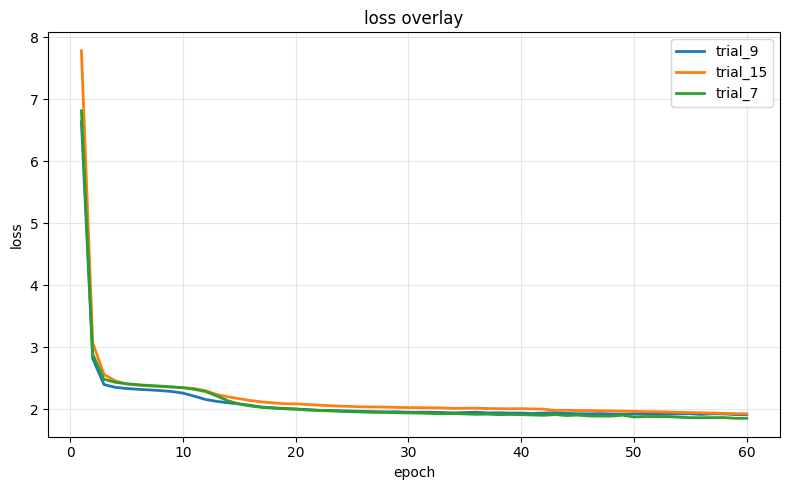

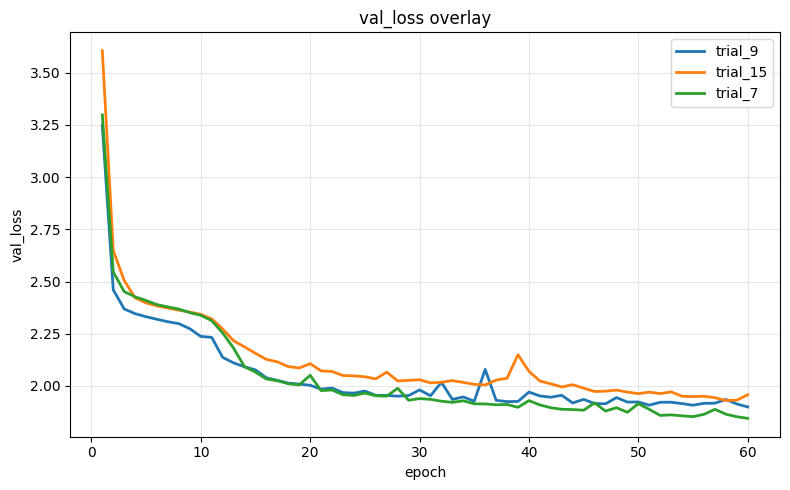

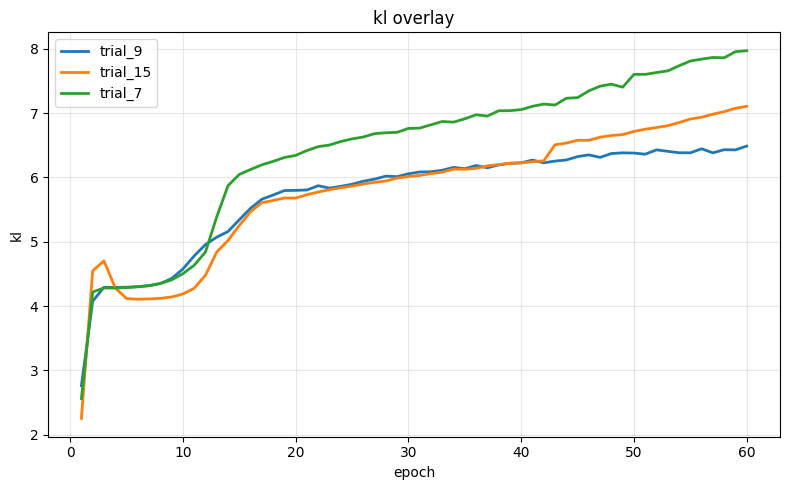

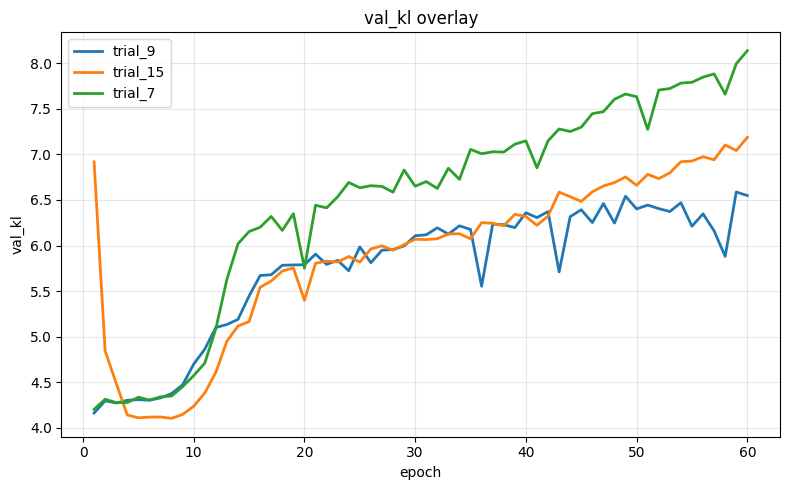

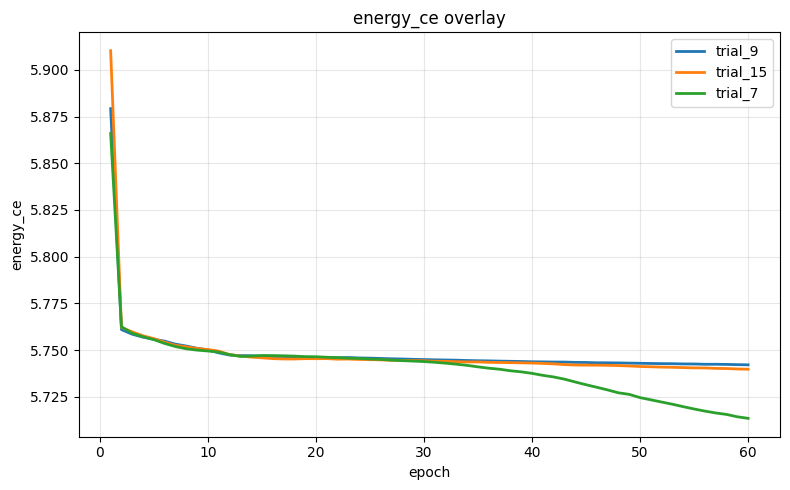

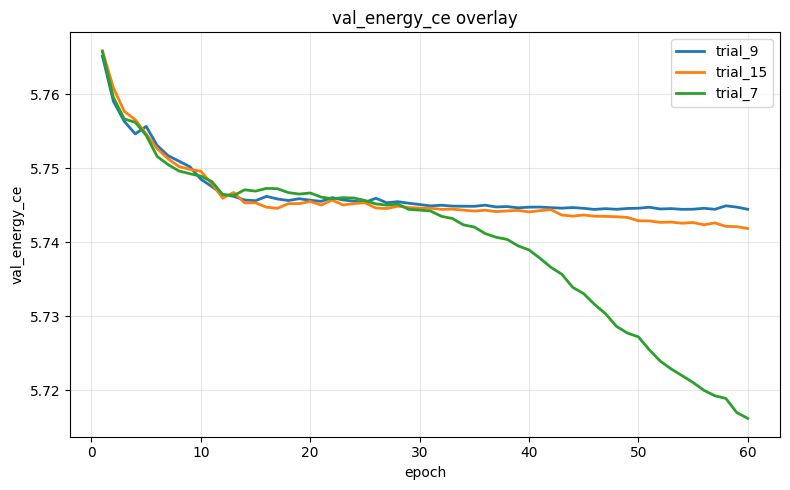

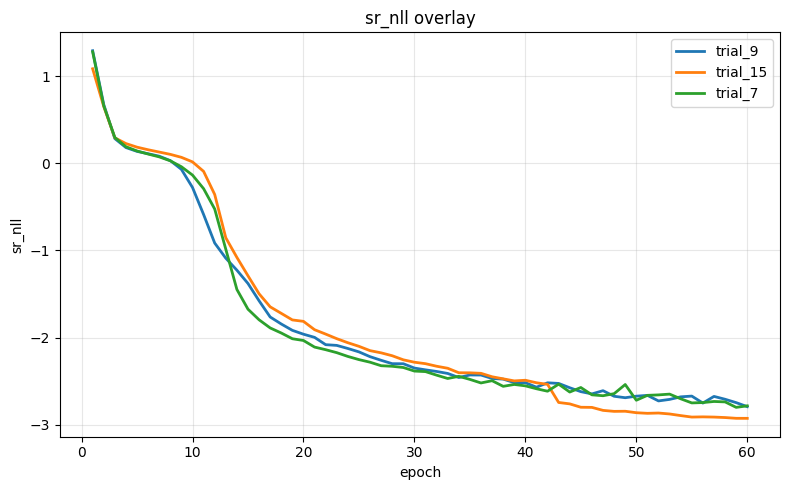

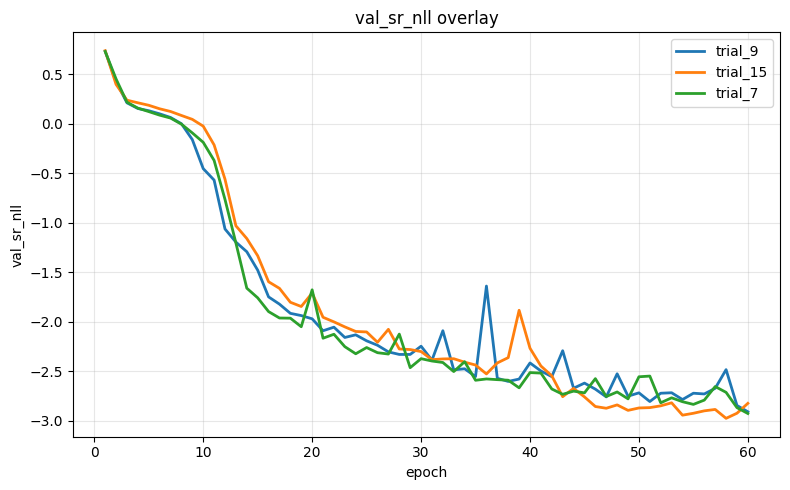

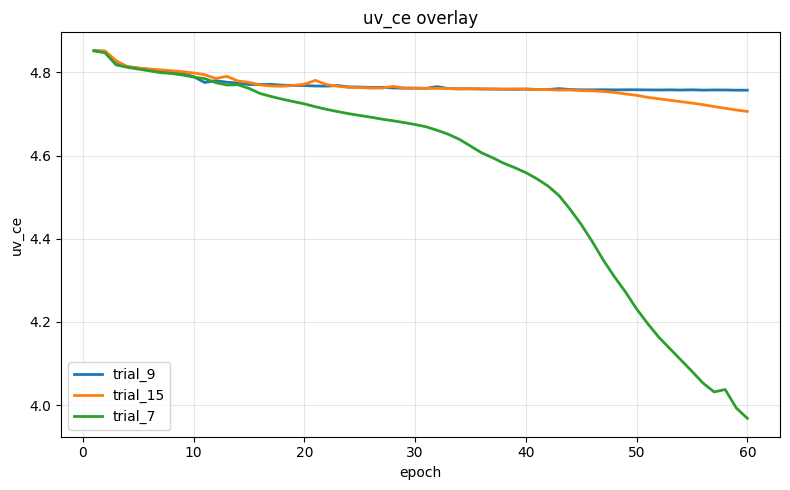

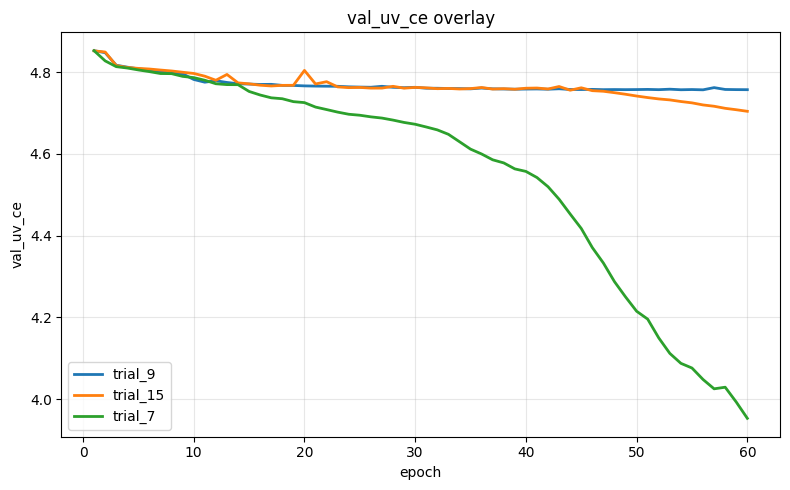

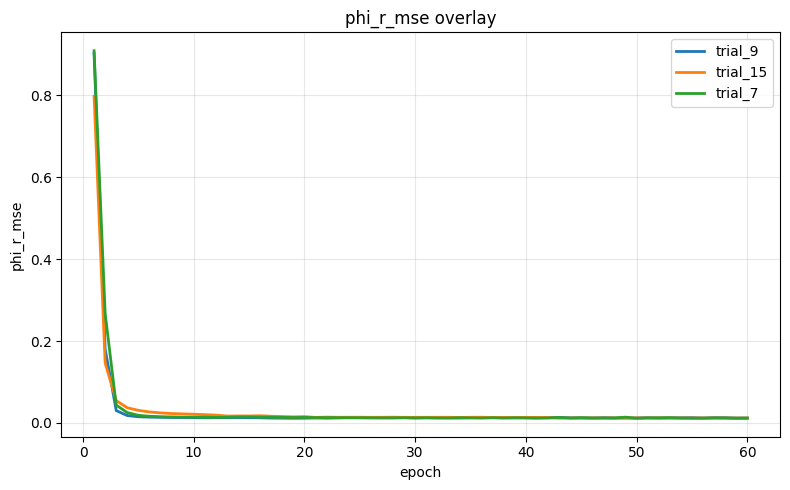

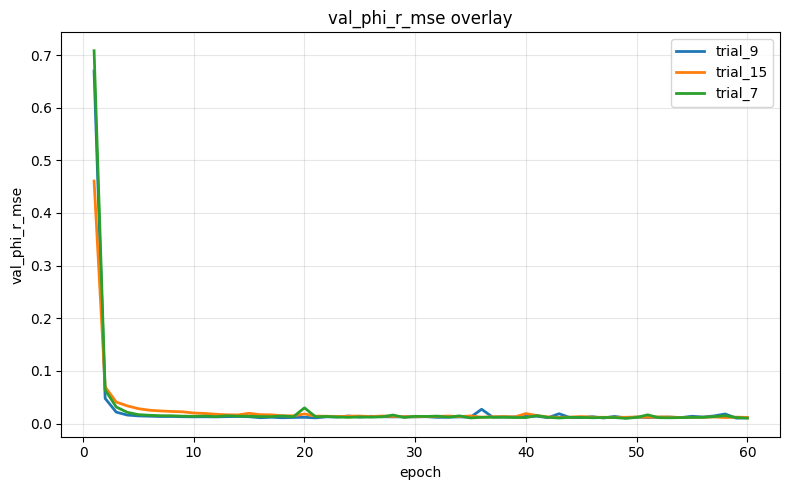

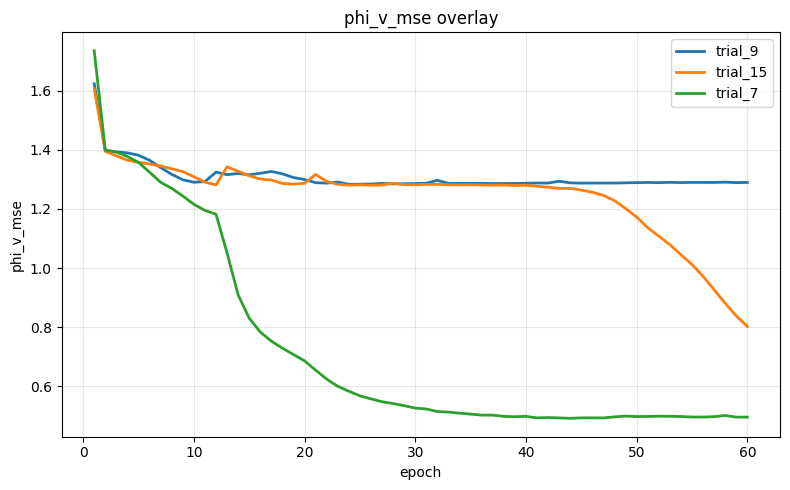

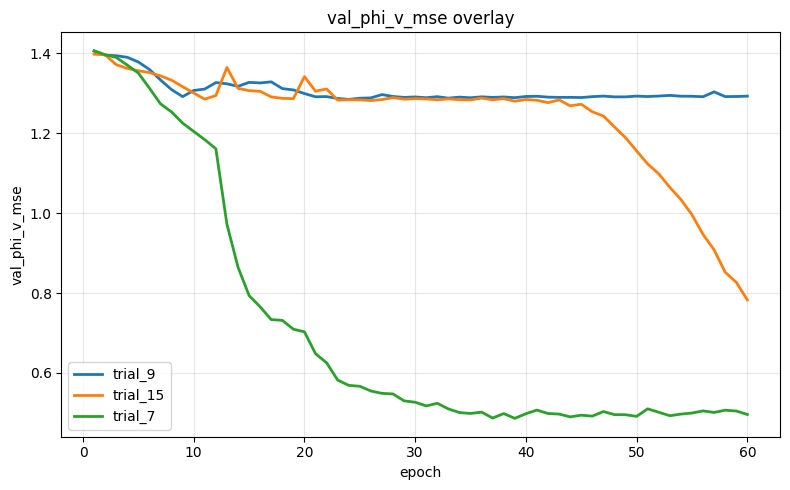

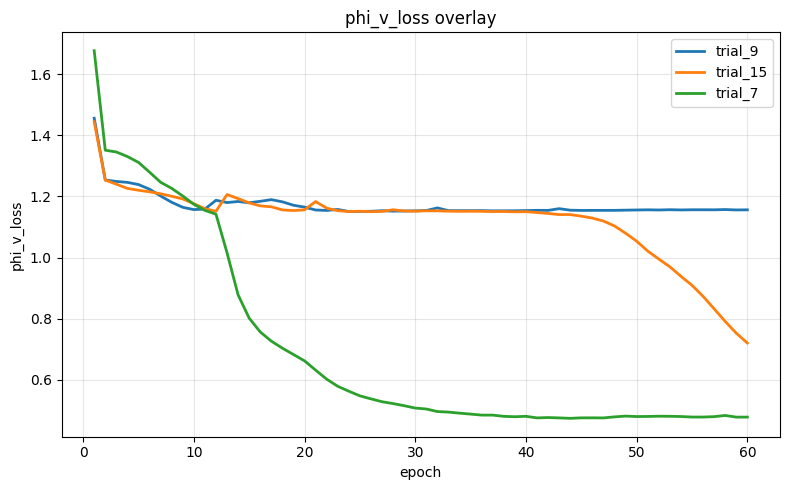

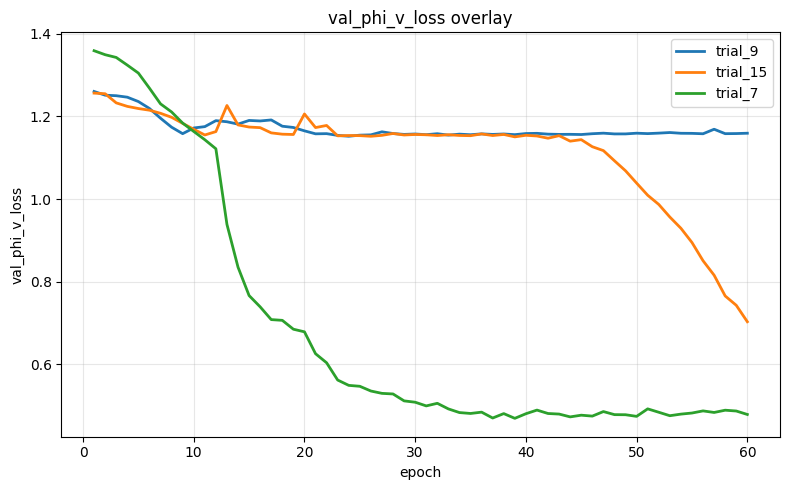

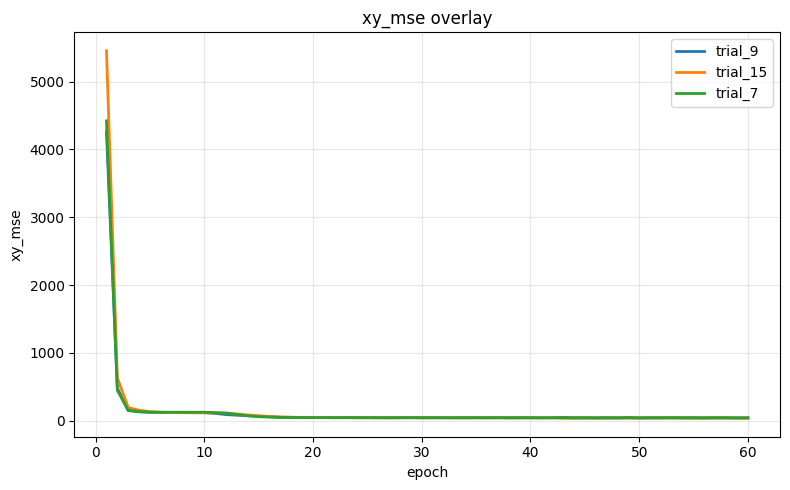

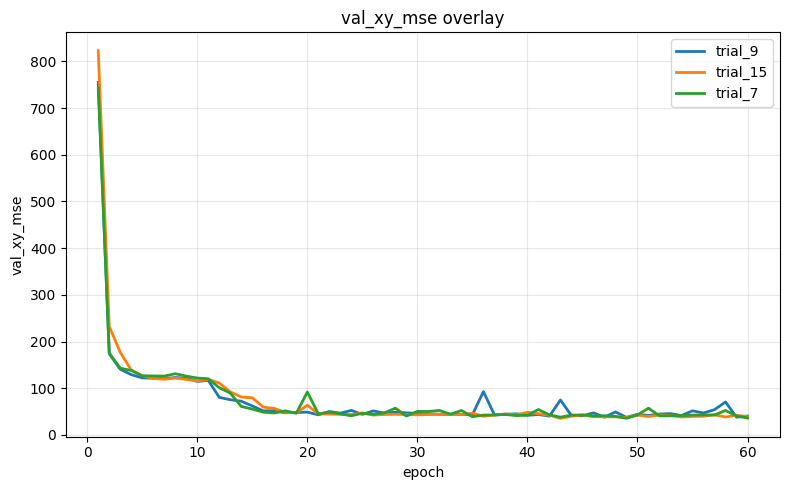

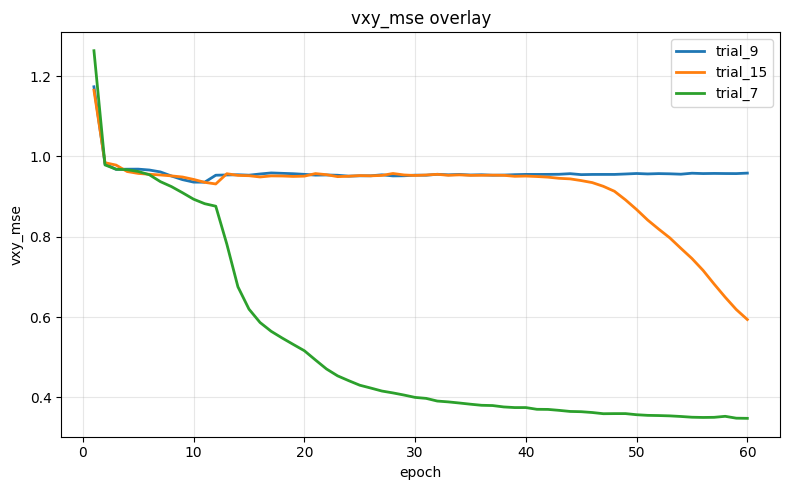

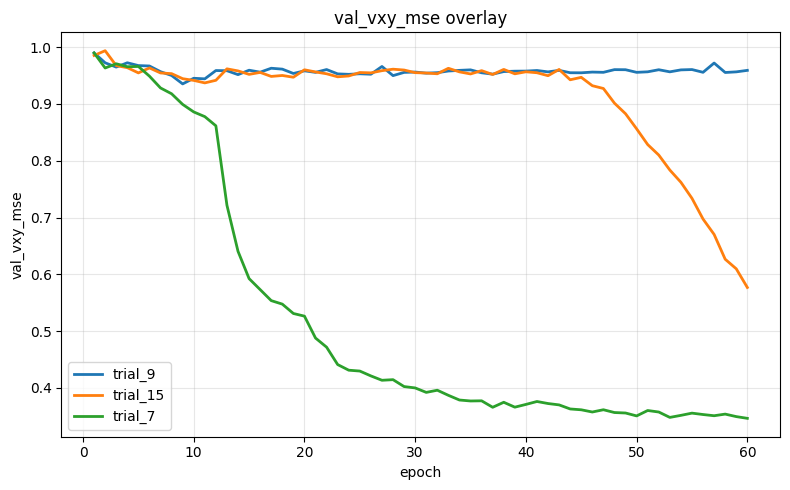

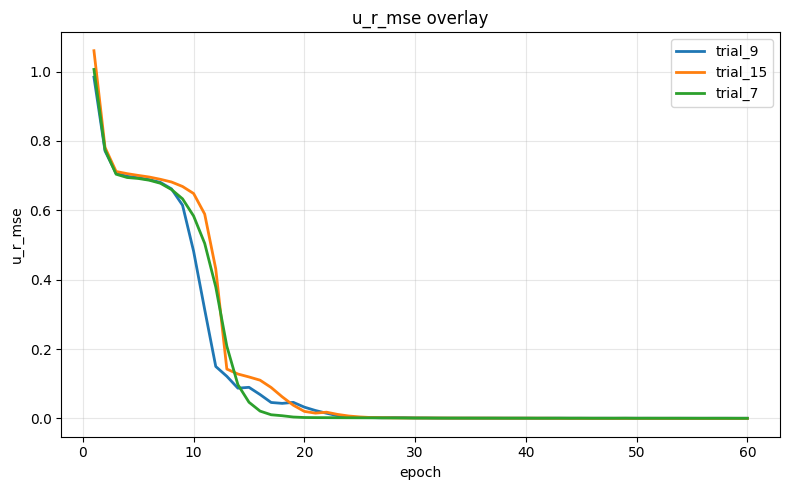

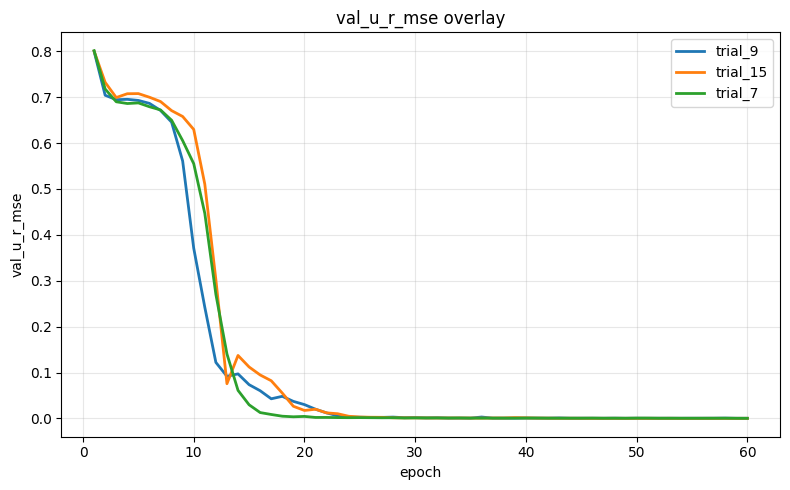

In [185]:
# ==========================================================
# Overlay training histories of the 3 final models - v1.5
# ==========================================================
import matplotlib.pyplot as plt
import numpy as np

def plot_histories_overlay(final_runs, keys=None):

    # ------------------------------------------------------
    # Default keys for v1.5 model
    # ------------------------------------------------------
    if keys is None:
        keys = [
            # Global
            "loss",
            "val_loss",

            # VAE core
            "kl",
            "val_kl",

            # Energy (categorical)
            "energy_ce",
            "val_energy_ce",

            # Radial (Gaussian)
            "sr_nll",
            "val_sr_nll",

            # u_v categorical
            "uv_ce",
            "val_uv_ce",

            # Angular position
            "phi_r_mse",
            "val_phi_r_mse",

            # Angular direction
            "phi_v_mse",
            "val_phi_v_mse",

            # Optional combined angular loss (if present)
            "phi_v_loss",
            "val_phi_v_loss",

            # Geometry
            "xy_mse",
            "val_xy_mse",

            "vxy_mse",
            "val_vxy_mse",

            # Radial auxiliary
            "u_r_mse",
            "val_u_r_mse",
        ]

    model_names = list(final_runs.keys())

    for k in keys:
        found = False
        plt.figure(figsize=(8, 5))

        for model_name in model_names:
            h = final_runs[model_name]["history"].history

            if k in h:
                found = True
                epochs = np.arange(1, len(h[k]) + 1)

                plt.plot(
                    epochs,
                    h[k],
                    linewidth=2,
                    label=model_name
                )

        if not found:
            plt.close()
            continue

        plt.xlabel("epoch")
        plt.ylabel(k)
        plt.title(f"{k} overlay")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()


# Run
plot_histories_overlay(final_runs)

In [186]:
# ==========================================================
# Final evaluation: generate, reconstruct, compute full score - v1.5
# ==========================================================

# ----------------------------------------------------------
# Utility transforms
# ----------------------------------------------------------
def sample_types(n_samples, type_probs, rng=None):
    rng = np.random.default_rng(GLOBAL_SEED) if rng is None else rng
    idx = rng.choice(len(type_probs), size=n_samples, p=type_probs)
    return idx.astype(np.int32)

def one_hot_from_idx(idx, n_types):
    return tf.one_hot(idx, depth=n_types, dtype=tf.float32)

def renorm_cos_sin(c, s, eps=1e-12):
    r = np.sqrt(c * c + s * s) + eps
    return c / r, s / r

# ----------------------------------------------------------
# Reconstruct real test-set physical variables
# ----------------------------------------------------------
def get_real_test_physical():
    return reconstruct_physical_from_real(
        X_cont=X_cont_test,
        E_raw=E_test_raw,
        u_v_raw=u_v_test_raw,
        C=C,
        R=R
    )

REAL_TEST = get_real_test_physical()

# ----------------------------------------------------------
# Generate and reconstruct physical variables for one model
# ----------------------------------------------------------
def generate_physical_from_model(model, ngen, rng=None):
    rng = np.random.default_rng(GLOBAL_SEED) if rng is None else rng

    gen_out = generate_outputs_v15(
        model=model,
        ngen=ngen,
        type_probs=type_probs,
        n_types=n_types,
        energy_bins=energy_bins,
        s_r_mean=s_r_mean,
        s_r_std=s_r_std,
        rng=rng
    )

    gen_phys = reconstruct_physical_from_generated(
        E_gen=gen_out["E"],
        y_cont_gen=gen_out["y_cont"],
        u_v_gen=gen_out["u_v"],
        C=C,
        R=R
    )

    # Attach useful raw generated outputs for later inspection
    gen_phys["type_idx"] = gen_out["type_idx"]
    gen_phys["energy_idx"] = gen_out["energy_idx"]
    gen_phys["uv_idx"] = gen_out["uv_idx"]
    gen_phys["y_cont"] = gen_out["y_cont"]
    gen_phys["E"] = gen_out["E"]

    return gen_phys

# ----------------------------------------------------------
# Spike penalties
# ----------------------------------------------------------
def edge_spike_penalty(real, gen, bins=250, range_=None, edge="left", frac=0.03):
    real_hist, edges = np.histogram(real, bins=bins, range=range_, density=True)
    gen_hist, _ = np.histogram(gen, bins=edges, density=True)

    n_edge = max(1, int(frac * len(real_hist)))

    if edge == "left":
        return float(np.mean(np.maximum(0.0, gen_hist[:n_edge] - real_hist[:n_edge])))
    elif edge == "right":
        return float(np.mean(np.maximum(0.0, gen_hist[-n_edge:] - real_hist[-n_edge:])))
    elif edge == "center":
        mid = len(real_hist) // 2
        half = max(1, n_edge // 2)
        sl = slice(max(0, mid - half), min(len(real_hist), mid + half + 1))
        return float(np.mean(np.maximum(0.0, gen_hist[sl] - real_hist[sl])))
    else:
        raise ValueError("edge must be 'left', 'right', or 'center'")

# ----------------------------------------------------------
# Final score
# ----------------------------------------------------------
def compute_final_score(real_phys, gen_phys, aux_history):
    # Wasserstein distances
    d_logE = wasserstein_distance(real_phys["logE"], gen_phys["logE"])
    d_u_v  = wasserstein_distance(real_phys["u_v"],  gen_phys["u_v"])

    d_x = wasserstein_distance(real_phys["x"], gen_phys["x"])
    d_y = wasserstein_distance(real_phys["y"], gen_phys["y"])
    d_z = wasserstein_distance(real_phys["z"], gen_phys["z"])

    d_vx = wasserstein_distance(real_phys["vx"], gen_phys["vx"])
    d_vy = wasserstein_distance(real_phys["vy"], gen_phys["vy"])
    d_vz = wasserstein_distance(real_phys["vz"], gen_phys["vz"])

    # Spike penalties
    p_uv = edge_spike_penalty(
        real_phys["u_v"], gen_phys["u_v"],
        bins=250, range_=(-1, 1), edge="left", frac=0.03
    )
    p_x = edge_spike_penalty(
        real_phys["x"], gen_phys["x"],
        bins=250, edge="center", frac=0.03
    )
    p_y = edge_spike_penalty(
        real_phys["y"], gen_phys["y"],
        bins=250, edge="center", frac=0.03
    )
    p_z = edge_spike_penalty(
        real_phys["z"], gen_phys["z"],
        bins=250, edge="left", frac=0.03
    )

    # Physics score
    score = (
        1.0 * d_logE +
        1.2 * d_u_v +
        1.5 * d_x +
        1.5 * d_y +
        1.7 * d_z +
        1.0 * d_vx +
        1.0 * d_vy +
        1.0 * d_vz +
        8.0 * p_uv +
        6.0 * p_x +
        6.0 * p_y +
        6.0 * p_z
    )

    # Auxiliary score from final validation metrics
    h = aux_history.history
    best_idx = int(np.argmin(h["val_loss"]))

    aux_score = 0.0

    if "val_vxy_mse" in h:
        aux_score += 0.20 * h["val_vxy_mse"][best_idx]

    if "val_xy_mse" in h:
        aux_score += 0.01 * h["val_xy_mse"][best_idx]

    if "val_u_r_mse" in h:
        aux_score += 0.50 * h["val_u_r_mse"][best_idx]

    if "val_phi_v_loss" in h:
        aux_score += 0.15 * h["val_phi_v_loss"][best_idx]
    elif "val_phi_v_mse" in h:
        aux_score += 0.15 * h["val_phi_v_mse"][best_idx]

    if "val_phi_r_mse" in h:
        aux_score += 0.10 * h["val_phi_r_mse"][best_idx]

    final_score = float(score + aux_score)

    return {
        "d_logE": float(d_logE),
        "d_u_v": float(d_u_v),
        "d_x": float(d_x),
        "d_y": float(d_y),
        "d_z": float(d_z),
        "d_vx": float(d_vx),
        "d_vy": float(d_vy),
        "d_vz": float(d_vz),
        "p_uv": float(p_uv),
        "p_x": float(p_x),
        "p_y": float(p_y),
        "p_z": float(p_z),
        "score": float(score),
        "aux_score": float(aux_score),
        "final_score": float(final_score),
    }

# ----------------------------------------------------------
# Evaluate all 3 final models
# ----------------------------------------------------------
final_eval = {}

for model_name, run in final_runs.items():
    print(f"\nEvaluating {model_name} ...")

    gen_phys = generate_physical_from_model(run["model"], len(X_cont_test))
    score_details = compute_final_score(REAL_TEST, gen_phys, run["history"])

    final_eval[model_name] = {
        "generated": gen_phys,
        "score_details": score_details,
    }

    print(f"{model_name} final_score = {score_details['final_score']:.6f}")
    print(score_details)

# ----------------------------------------------------------
# Save final evaluation
# ----------------------------------------------------------
final_eval_to_save = {}
for model_name, res in final_eval.items():
    final_eval_to_save[model_name] = {
        "score_details": res["score_details"],
        "stage2_score": TOP3_TRIALS[model_name]["score_stage2"],
        "best_val_loss": final_runs[model_name]["best_val_loss"],
        "params": final_runs[model_name]["params"],
    }

eval_path = os.path.join(stage3_dir, "stage3_final_evaluation.json")
with open(eval_path, "w") as f:
    json.dump(final_eval_to_save, f, indent=2)

print("\nSaved final evaluation to:", eval_path)

print("\nRanking by final stage-3 score:")
ranking = sorted(
    [(name, final_eval[name]["score_details"]["final_score"]) for name in final_eval],
    key=lambda x: x[1]
)
for rank, (name, sc) in enumerate(ranking, start=1):
    print(f"Rank {rank}: {name}  score = {sc:.6f}")


Evaluating trial_9 ...
trial_9 final_score = 16.022134
{'d_logE': 0.0014862448371852786, 'd_u_v': 0.00706776246729504, 'd_x': 1.6647960350041782, 'd_y': 1.7088095561955834, 'd_z': 5.953739212854911, 'd_vx': 0.018663427914722648, 'd_vy': 0.022260708979878842, 'd_vz': 0.00706776246729504, 'p_uv': 0.0, 'p_x': 0.0010222648905592994, 'p_y': 0.0004977210812738, 'p_z': 0.0, 'score': 15.248844423643826, 'aux_score': 0.7732895484153414, 'final_score': 16.022133972059166}

Evaluating trial_15 ...
trial_15 final_score = 15.648181
{'d_logE': 0.001825628748634489, 'd_u_v': 0.01309863512737243, 'd_x': 2.275425623610916, 'd_y': 2.5175878094268915, 'd_z': 4.534727723770176, 'd_vx': 0.02833874550293486, 'd_vy': 0.05723048049544788, 'd_vz': 0.01309863512737243, 'p_uv': 0.0, 'p_x': 0.0001992824172068782, 'p_y': 0.0008452551920397646, 'p_z': 0.0, 'score': 15.021036357648729, 'aux_score': 0.6271446691185703, 'final_score': 15.648181026767299}

Evaluating trial_7 ...
trial_7 final_score = 16.317982
{'d_log

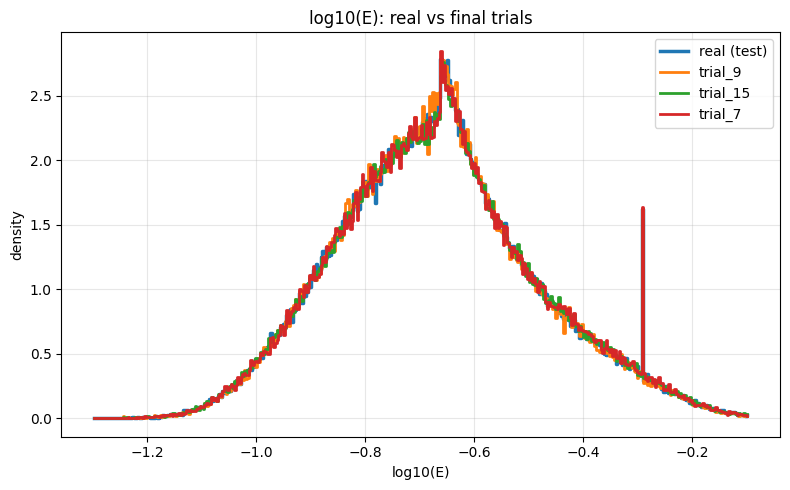

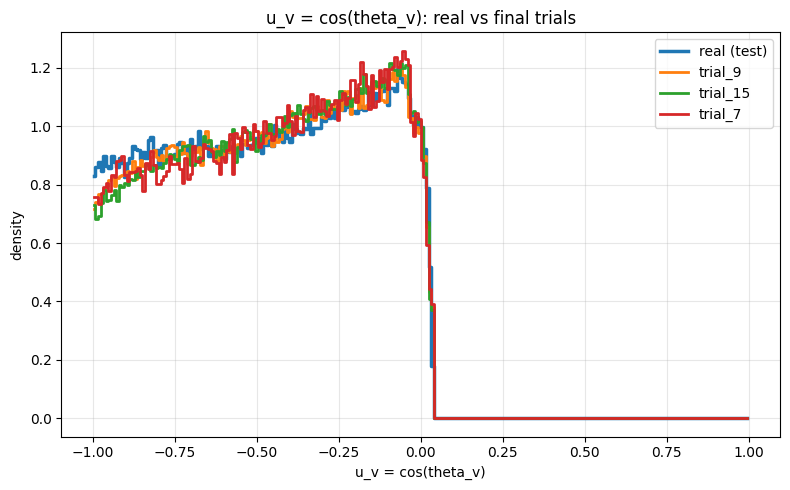

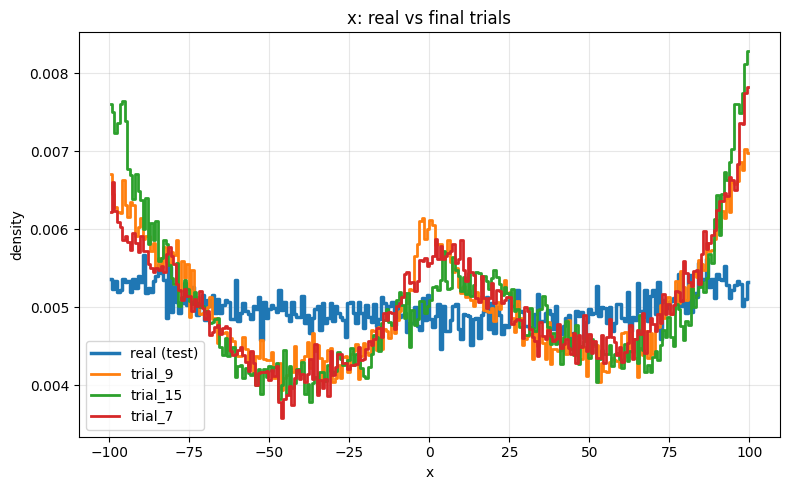

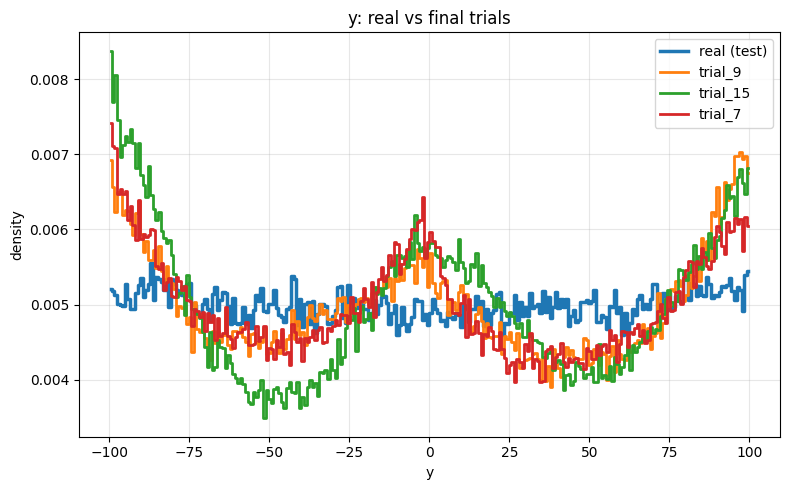

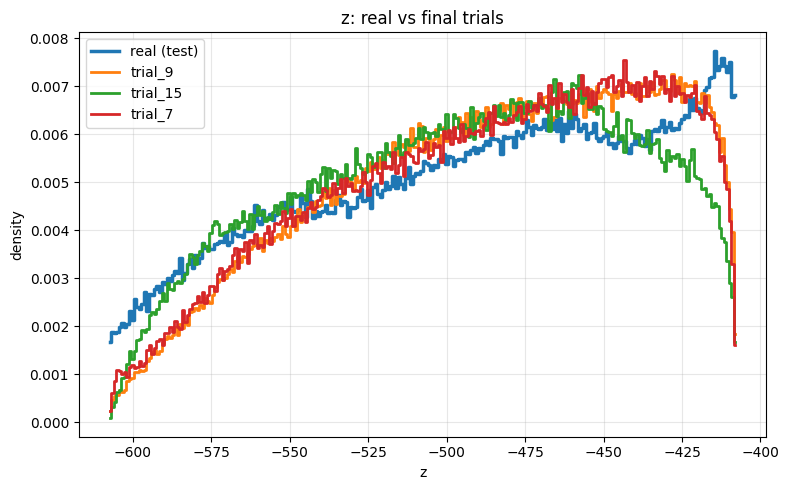

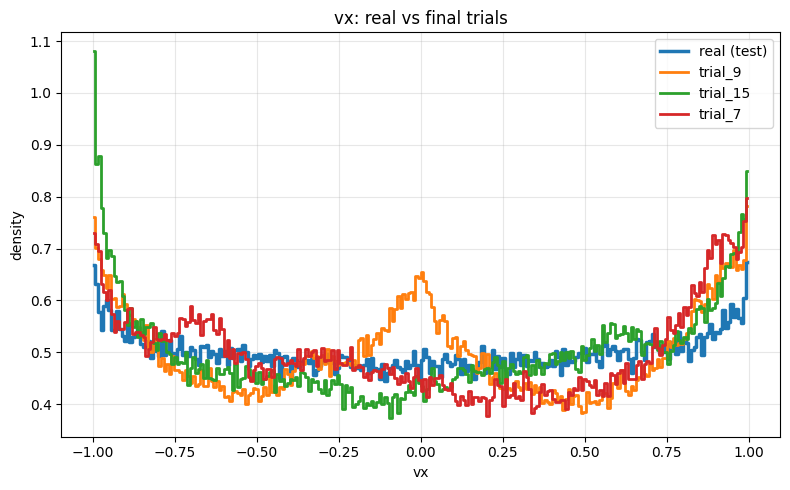

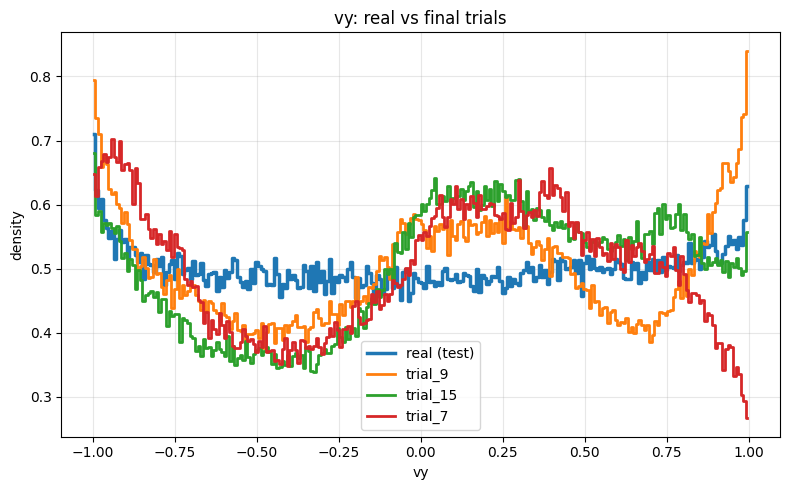

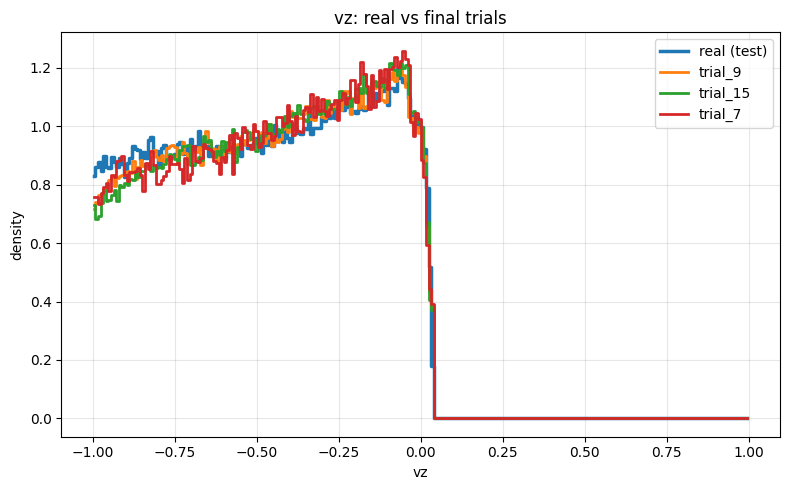

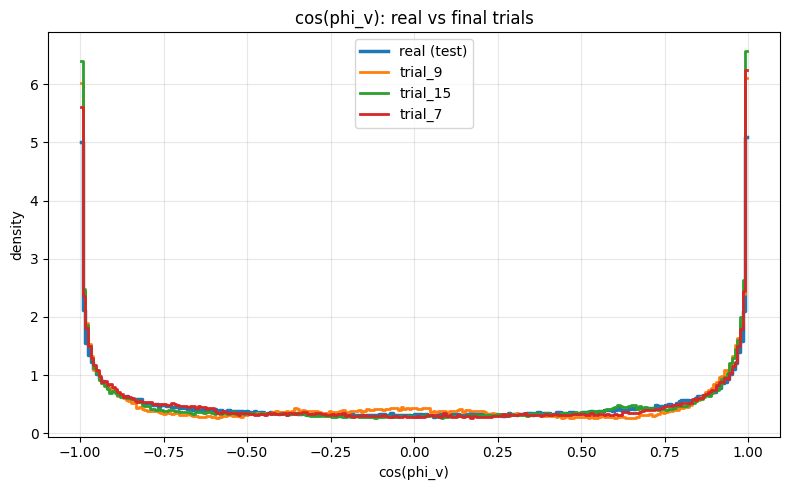

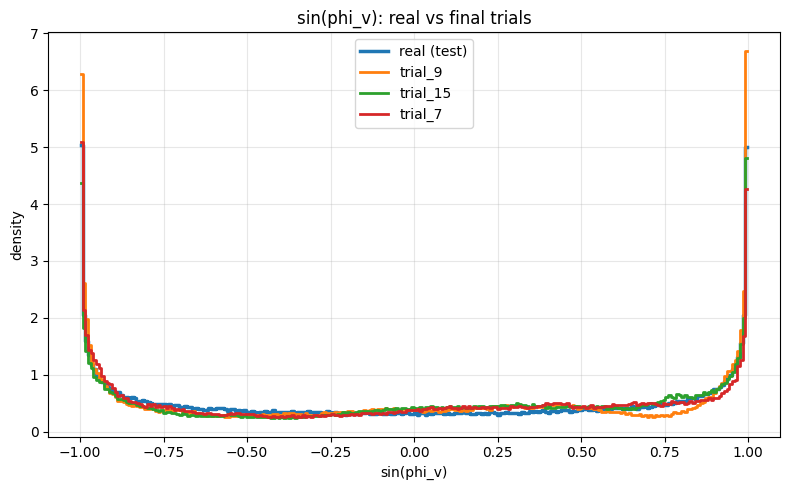

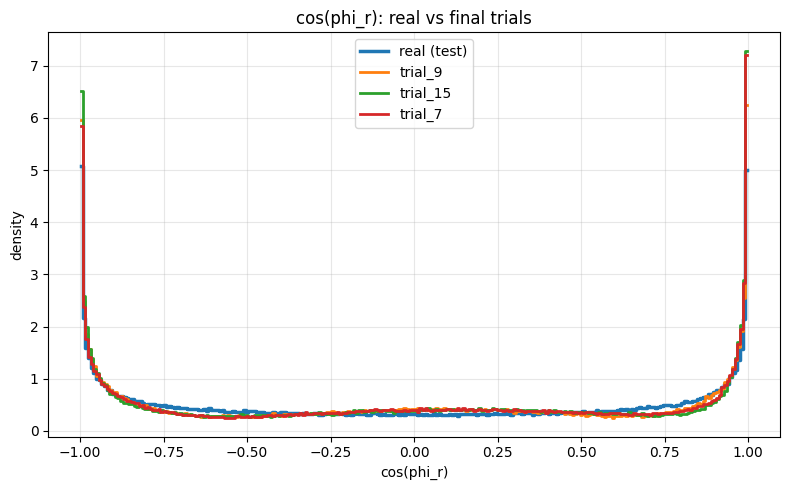

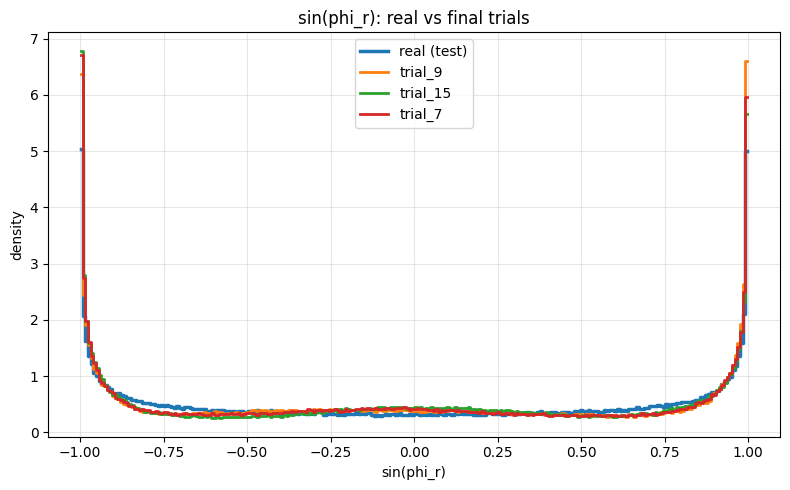

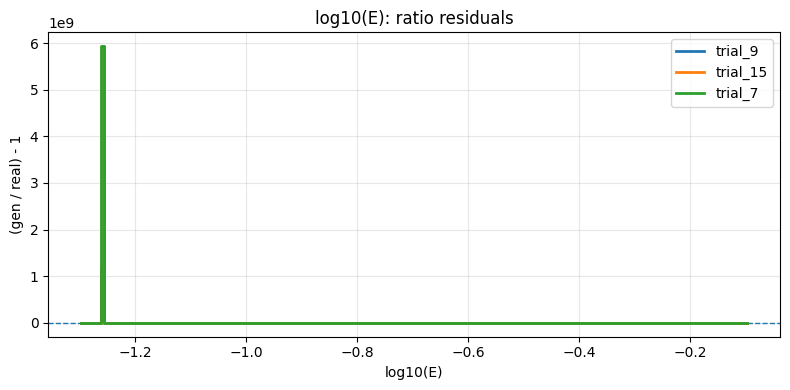

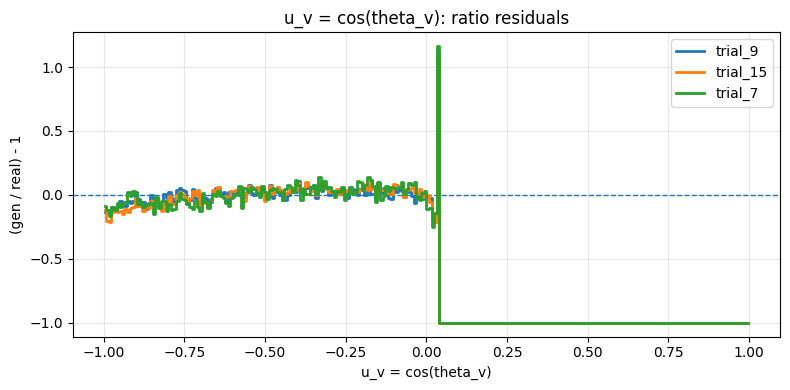

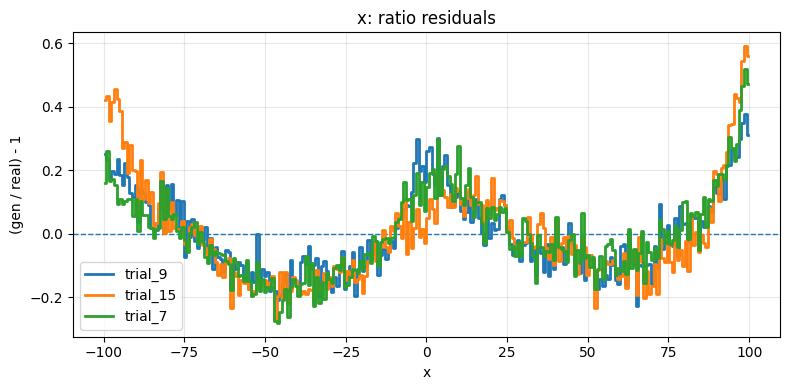

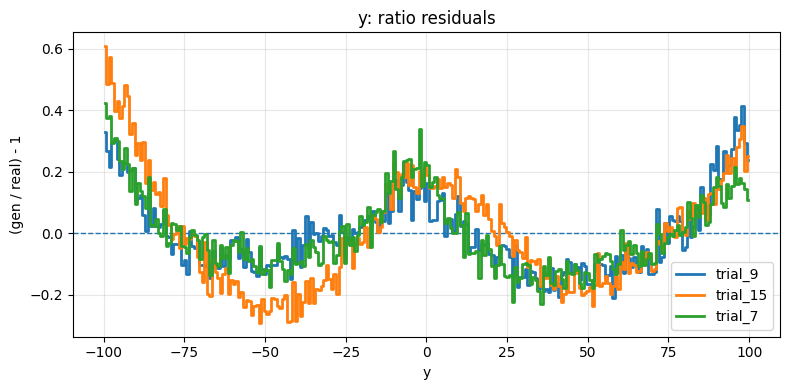

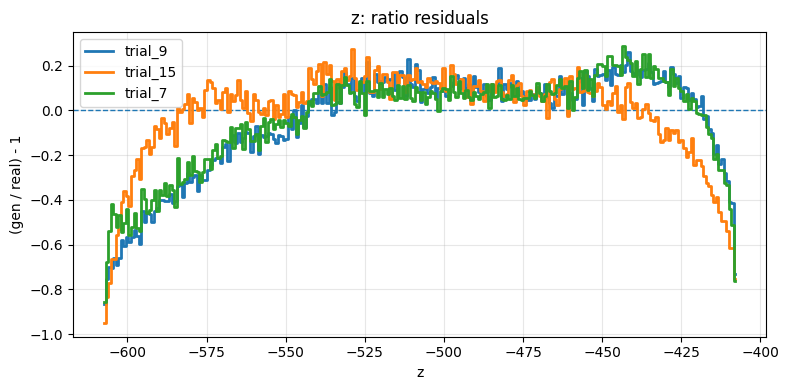

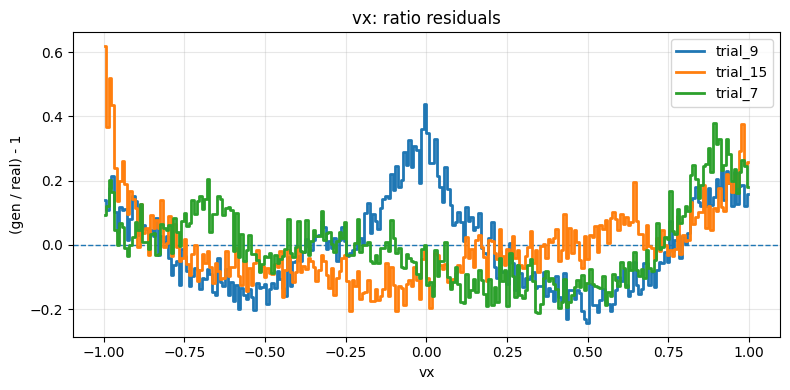

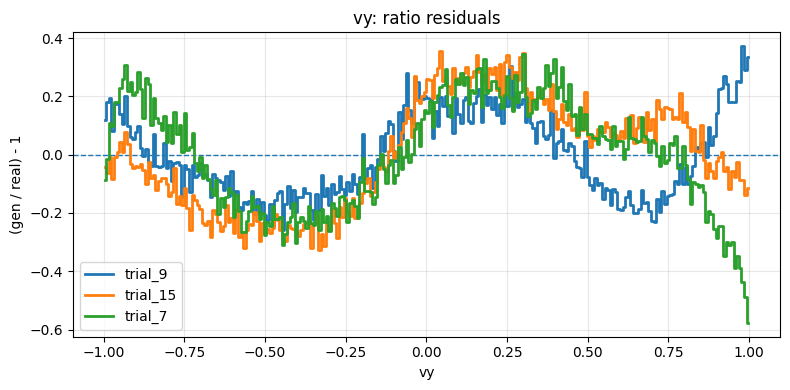

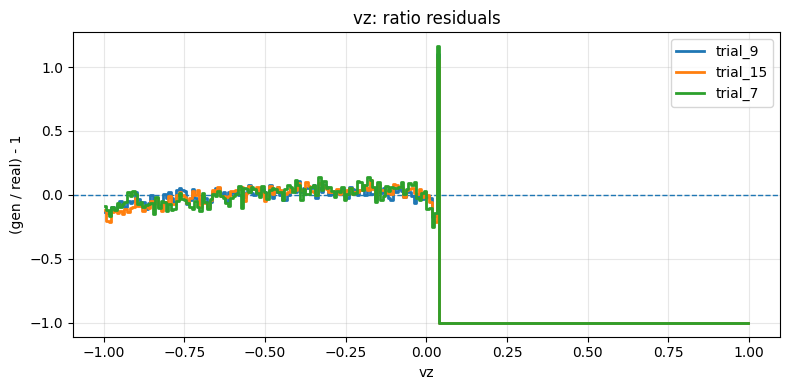

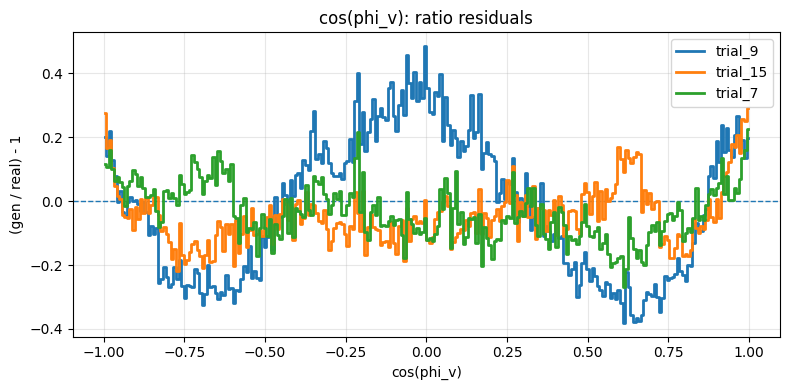

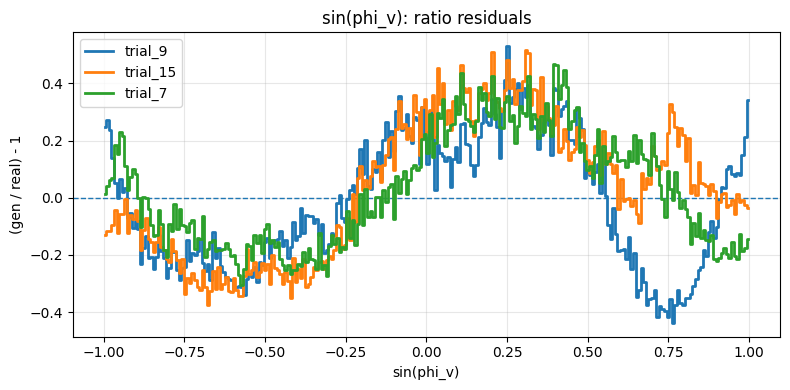

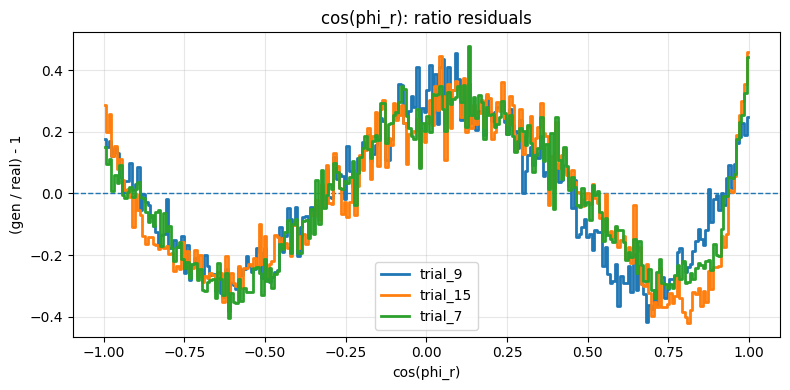

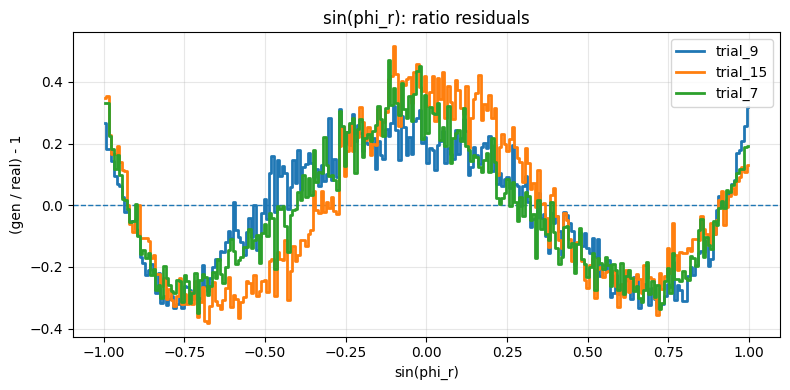

In [187]:
# ==========================================================
# Overlay plots: real vs all 3 final trials - v1.5
# ==========================================================

def overlay_hist_real_vs_trials(
    real,
    trial_dict,
    name,
    bins=200,
    range_=None,
    density=True
):
    plt.figure(figsize=(8, 5))

    # Real data
    hist_real, edges = np.histogram(real, bins=bins, range=range_, density=density)
    centers = 0.5 * (edges[:-1] + edges[1:])
    plt.step(centers, hist_real, where="mid", linewidth=2.5, label="real (test)")

    # Trial data
    for model_name, arr in trial_dict.items():
        hist_gen, _ = np.histogram(arr, bins=edges, density=density)
        plt.step(centers, hist_gen, where="mid", linewidth=2, label=model_name)

    plt.xlabel(name)
    plt.ylabel("density")
    plt.title(f"{name}: real vs final trials")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


def overlay_ratio_minus_one(
    real,
    trial_dict,
    name,
    bins=200,
    range_=None,
    eps=1e-12
):
    hist_real, edges = np.histogram(real, bins=bins, range=range_, density=True)
    centers = 0.5 * (edges[:-1] + edges[1:])

    plt.figure(figsize=(8, 4))
    plt.axhline(0.0, linestyle="--", linewidth=1)

    for model_name, arr in trial_dict.items():
        hist_gen, _ = np.histogram(arr, bins=edges, density=True)
        ratio_m1 = hist_gen / np.maximum(hist_real, eps) - 1.0
        plt.step(centers, ratio_m1, where="mid", linewidth=2, label=model_name)

    plt.xlabel(name)
    plt.ylabel("(gen / real) - 1")
    plt.title(f"{name}: ratio residuals")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ----------------------------------------------------------
# Prepare generated variables by trial
# ----------------------------------------------------------
trial_vars = {}
for model_name, res in final_eval.items():
    trial_vars[model_name] = res["generated"]

# ----------------------------------------------------------
# Variable list to compare
# ----------------------------------------------------------
vars_to_plot = [
    ("logE",   "log10(E)",        None,    400),
    ("u_v",    "u_v = cos(theta_v)", (-1, 1), 250),

    ("x",      "x",               None,    250),
    ("y",      "y",               None,    250),
    ("z",      "z",               None,    250),

    ("vx",     "vx",              (-1, 1), 250),
    ("vy",     "vy",              (-1, 1), 250),
    ("vz",     "vz",              (-1, 1), 250),

    # Very useful for diagnosing phi_v behavior directly
    ("cphi_v", "cos(phi_v)",      (-1, 1), 250),
    ("sphi_v", "sin(phi_v)",      (-1, 1), 250),

    # Optional: also inspect position angle branch directly
    ("cphi_r", "cos(phi_r)",      (-1, 1), 250),
    ("sphi_r", "sin(phi_r)",      (-1, 1), 250),
]

# ----------------------------------------------------------
# Main overlay plots
# ----------------------------------------------------------
for key, label, range_, bins in vars_to_plot:
    overlay_hist_real_vs_trials(
        real=REAL_TEST[key],
        trial_dict={name: trial_vars[name][key] for name in trial_vars},
        name=label,
        bins=bins,
        range_=range_,
    )

# ----------------------------------------------------------
# Residual ratio plots
# ----------------------------------------------------------
for key, label, range_, bins in vars_to_plot:
    overlay_ratio_minus_one(
        real=REAL_TEST[key],
        trial_dict={name: trial_vars[name][key] for name in trial_vars},
        name=label,
        bins=bins,
        range_=range_,
    )

In [188]:
# ==========================================================
# Compact final comparison table - v1.5
# ==========================================================

rows = []
for model_name in final_runs:
    rows.append({
        "model": model_name,
        "stage2_score": TOP3_TRIALS[model_name]["score_stage2"],
        "stage3_score": final_eval[model_name]["score_details"]["final_score"],
        "best_val_loss": final_runs[model_name]["best_val_loss"],
        "epochs_ran": final_runs[model_name]["n_epochs_ran"],
        "train_time_sec": final_runs[model_name]["train_time_sec"],

        # Physics distances
        "d_logE": final_eval[model_name]["score_details"]["d_logE"],
        "d_u_v": final_eval[model_name]["score_details"]["d_u_v"],
        "d_x": final_eval[model_name]["score_details"]["d_x"],
        "d_y": final_eval[model_name]["score_details"]["d_y"],
        "d_z": final_eval[model_name]["score_details"]["d_z"],
        "d_vx": final_eval[model_name]["score_details"]["d_vx"],
        "d_vy": final_eval[model_name]["score_details"]["d_vy"],
        "d_vz": final_eval[model_name]["score_details"]["d_vz"],

        # Spike penalties
        "p_uv": final_eval[model_name]["score_details"]["p_uv"],
        "p_x": final_eval[model_name]["score_details"]["p_x"],
        "p_y": final_eval[model_name]["score_details"]["p_y"],
        "p_z": final_eval[model_name]["score_details"]["p_z"],
    })

df_stage3_compare = (
    pd.DataFrame(rows)
    .sort_values("stage3_score")
    .reset_index(drop=True)
)

display(df_stage3_compare)

,model,stage2_score,stage3_score,best_val_loss,epochs_ran,train_time_sec,d_logE,d_u_v,d_x,d_y,d_z,d_vx,d_vy,d_vz,p_uv,p_x,p_y,p_z
0,trial_15,8.612839,15.648181,1.930398,60,1694.975721,0.001826,0.013099,2.275426,2.517588,4.534728,0.028339,0.057230,0.013099,0.0,0.000199,0.000845,0.0
1,trial_9,8.242554,16.022134,1.899671,60,1491.550138,0.001486,0.007068,1.664796,1.708810,5.953739,0.018663,0.022261,0.007068,0.0,0.001022,0.000498,0.0
2,trial_7,9.098956,16.317982,1.845123,60,1781.813539,0.001566,0.012144,2.518846,1.927844,5.320599,0.024820,0.034241,0.012144,0.0,0.000689,0.001006,0.0


#### OLD TRAINING

Here below are the cells used in single training which can be later used for fine tuning.

In [148]:
# ==========================================================
# Instantiate the new model and run a first single training
# ==========================================================

n_types = int(cond_train.shape[1])

model = CVAE_CatEnergy_CatUV(
    n_types=n_types,
    n_energy_bins=n_energy_bins,
    n_uv_bins=U_V_NBINS_EFF,
    uv_bin_edges=u_v_bins,

    latent_dim=8, # we can start with a smaller latent space for a quick test (latent_dim=12 is overkill)
    hidden=(128, 128, 64, 64, 64), # previous version had (128, 128, 64, 64, 64) but we can start with fewer layers for a quick test
    beta=0.1,
    type_weights=type_weights,

    # Gaussian head control (only for s_r now)
    min_log_sigma=-6.0,
    max_log_sigma=1.5,

    # Regularization
    lambda_sigma=2e-3,
    sigma_target=-2.5,
    lambda_phi=2e-2, # brought back from 3e-2 to 2e-2 to balance with the new categorical heads and prevent it from dominating the early training
    lambda_phi_r=2e-2,

    # Reconstruction weights
    w_energy=0.8,   # categorical energy head, reduced from 1.0 to 0.8 to allow more focus on other variables
    w_sr=1.1,       # Gaussian s_r head
    w_uv=1.1,       # categorical u_v head, reduced from 1.2 to 1.1 to balance with the energy head and encourage better overall learning of the direction distribution
    w_phi_r=1.4,    # position angular head
    w_phi_v=1.1,    # direction angular head
    w_ur = 0.01,

    # Geometric losses
    w_xy=0.005, # reduced from 0.01 to prevent it from dominating the early training before the model has learned a reasonable position representation
    w_vxy = 0.025, # new weight for the velocity xy-loss, added to encourage learning the correct direction distribution in the xy-plane which is crucial for the physics score and can be challenging for the model to capture with only the angular losses

    phi_v_ang_weight = 1.0,
    phi_v_mse_weight = 0.6,

    # Sphere geometry used in xy-loss
    sphere_R=R,

    # New controls for u_v categorical modeling
    sample_uv_uniform_inside_bin=True,
)

model.compile(
    optimizer=keras.optimizers.Adam(2e-4)
)


callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=6,
        min_lr=1e-5,
        verbose=1
    ),
]

In [149]:

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=60,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/60


320/320 ━━━━━━━━━━━━━━━━━━━━ 27s 72ms/step - energy_ce: 5.8981 - kl: 2.8054 - loss: 6.5741 - nll: 39.0444 - phi_r_mse: 0.8772 - phi_r_reg: 0.0196 - phi_reg: 0.0197 - phi_v_ang: 0.7952 - phi_v_loss: 1.7495 - phi_v_mse: 1.5904 - rec: 6.2380 - sigma_reg: 0.0161 - sr_nll: 1.0287 - u_r_mse: 0.9084 - uv_ce: 4.8521 - vxy_mse: 1.1481 - xy_mse: 4933.3711 - val_energy_ce: 5.7649 - val_kl: 4.5793 - val_loss: 3.3511 - val_nll: 17.7233 - val_phi_r_mse: 0.7141 - val_phi_r_reg: 0.0190 - val_phi_reg: 0.0195 - val_phi_v_ang: 0.6988 - val_phi_v_loss: 1.5373 - val_phi_v_mse: 1.3975 - val_rec: 2.8397 - val_sigma_reg: 0.0150 - val_sr_nll: 0.7395 - val_u_r_mse: 0.8098 - val_uv_ce: 4.8520 - val_vxy_mse: 0.9848 - val_xy_mse: 847.4396 - learning_rate: 2.0000e-04
Epoch 2/60
320/320 ━━━━━━━━━━━━━━━━━━━━ 26s 79ms/step - energy_ce: 5.7624 - kl: 3.9719 - loss: 3.1061 - nll: 16.7118 - phi_r_mse: 0.2874 - phi_r_reg: 0.0092 - phi_reg: 0.0119 - phi_v_ang: 0.6983 - phi_v_loss: 1.5362 - phi_v_mse: 1.3965 - rec: 2.6730 - 


Available history keys:
['energy_ce', 'kl', 'loss', 'nll', 'phi_r_mse', 'phi_r_reg', 'phi_reg', 'phi_v_ang', 'phi_v_loss', 'phi_v_mse', 'rec', 'sigma_reg', 'sr_nll', 'u_r_mse', 'uv_ce', 'val_energy_ce', 'val_kl', 'val_loss', 'val_nll', 'val_phi_r_mse', 'val_phi_r_reg', 'val_phi_reg', 'val_phi_v_ang', 'val_phi_v_loss', 'val_phi_v_mse', 'val_rec', 'val_sigma_reg', 'val_sr_nll', 'val_u_r_mse', 'val_uv_ce', 'val_vxy_mse', 'val_xy_mse', 'vxy_mse', 'xy_mse', 'learning_rate']


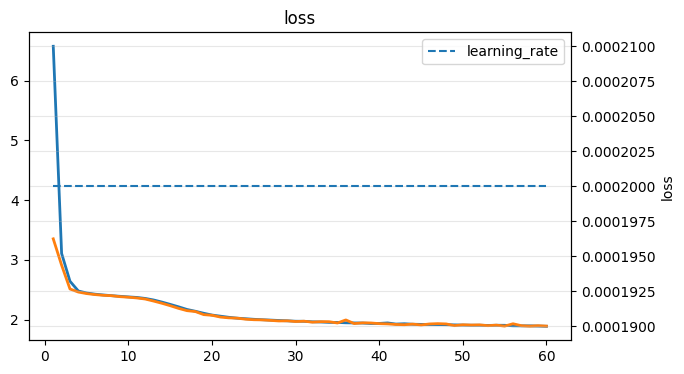

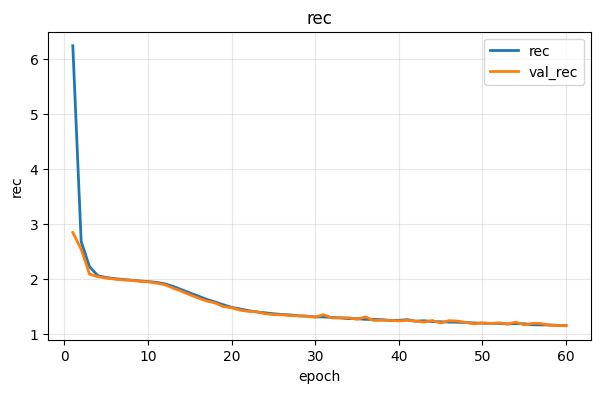

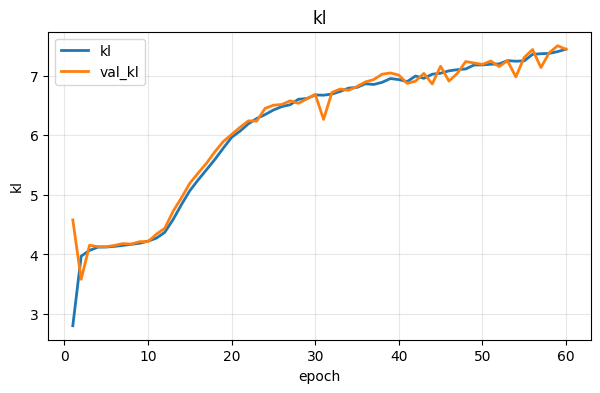

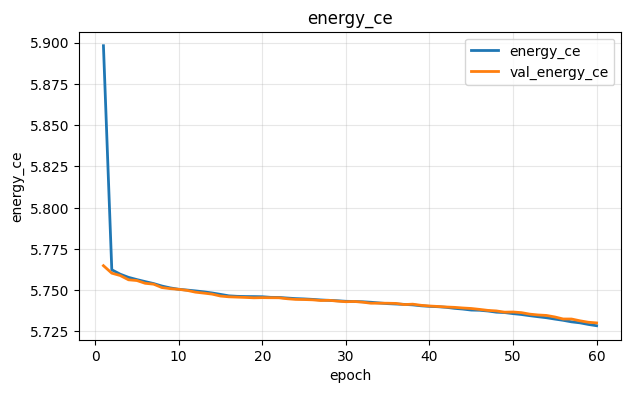

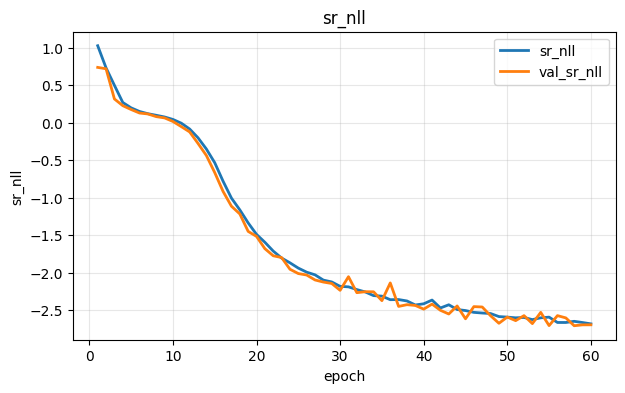

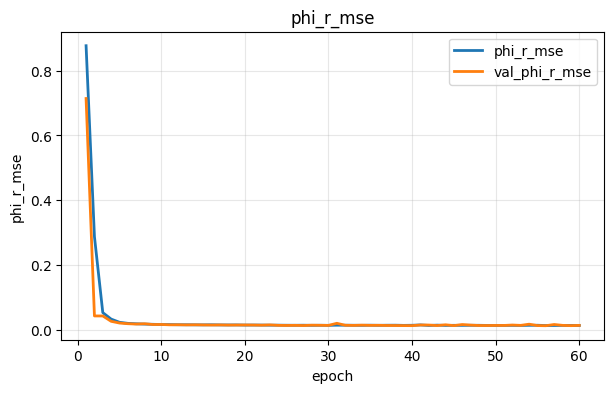

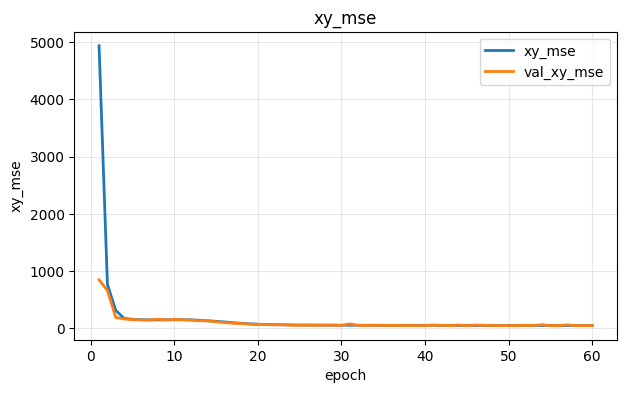

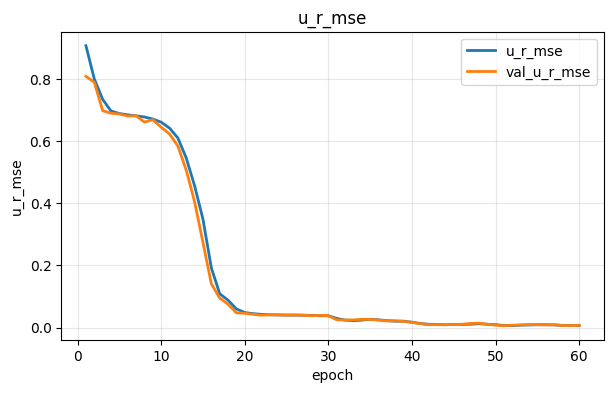

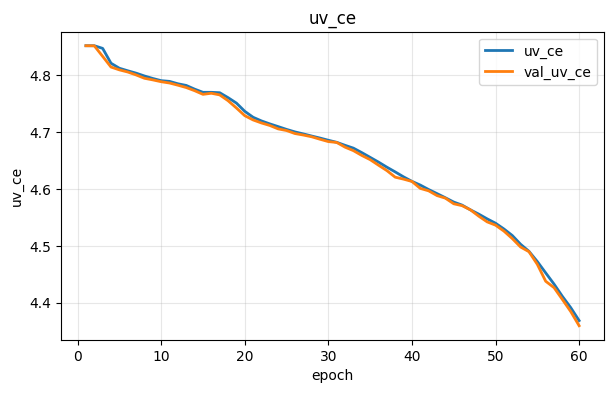

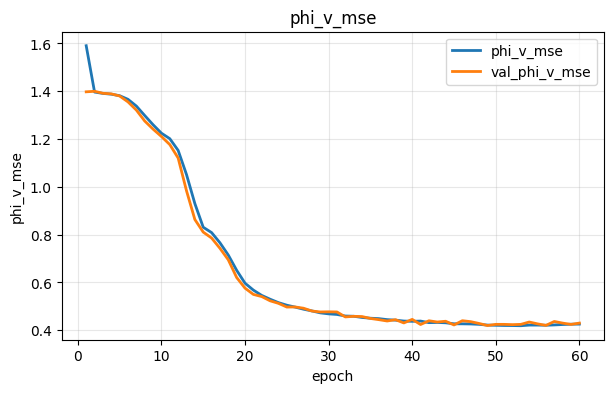

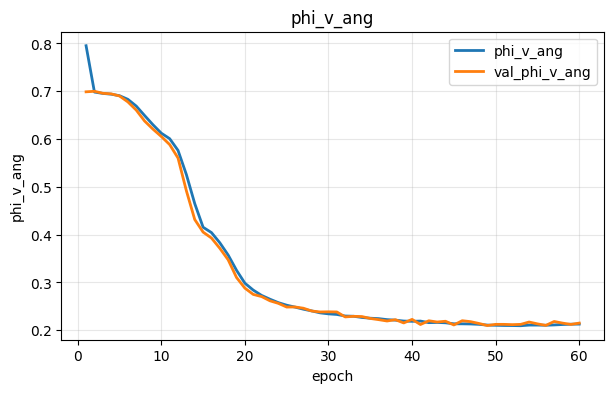

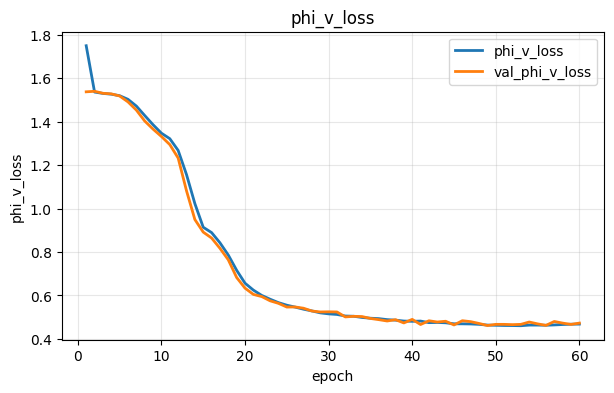

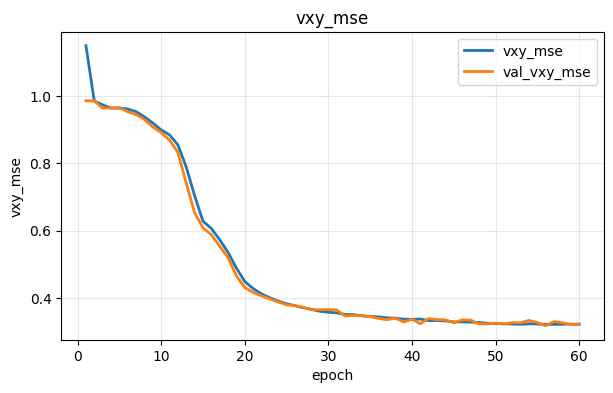

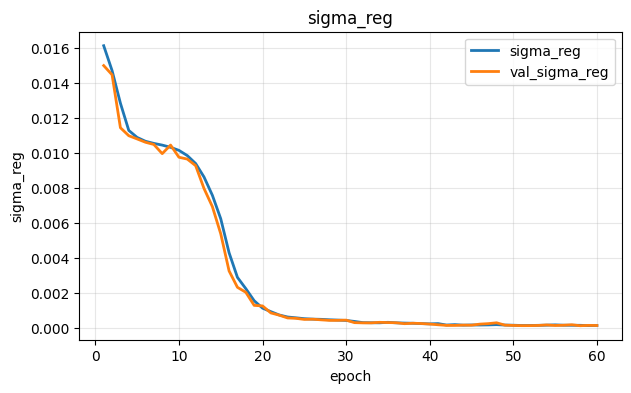

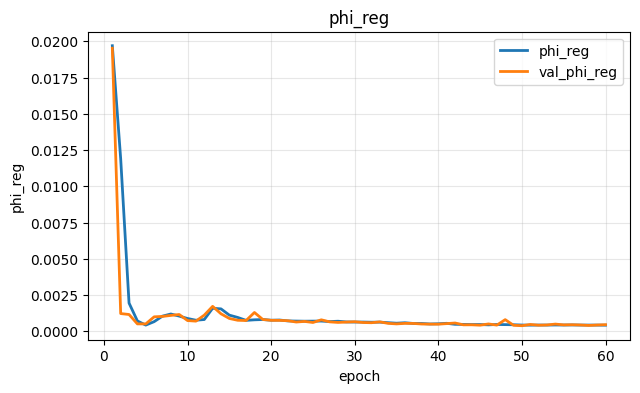

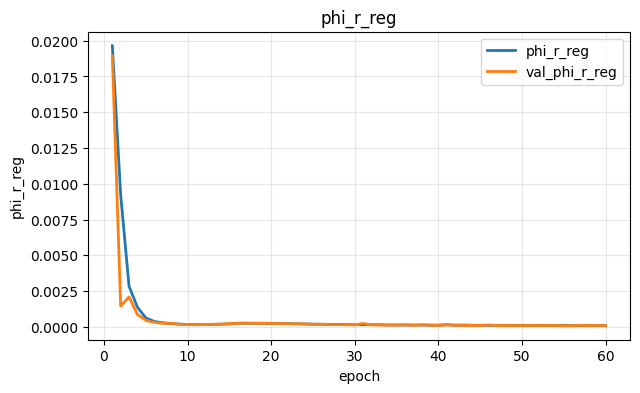

In [150]:
def plot_history(history, keys=None, show_available=True):
    h = history.history

    if show_available:
        print("\nAvailable history keys:")
        print(list(h.keys()))

    # ==========================================================
    # Default metrics for CVAE_CatEnergy_CatUV
    # Updated for:
    # - phi_v angular loss
    # - combined phi_v loss
    # - reconstructed directional Cartesian loss (vx, vy)
    # ==========================================================
    if keys is None:
        keys = [
            "loss",
            "rec",
            "kl",

            # energy
            "energy_ce",

            # position
            "sr_nll",
            "phi_r_mse",
            "xy_mse",
            "u_r_mse",

            # direction
            "uv_ce",
            "phi_v_mse",
            "phi_v_ang",
            "phi_v_loss",
            "vxy_mse",

            # regularizers
            "sigma_reg",
            "phi_reg",
            "phi_r_reg",
        ]

    # ==========================================================
    # Number of epochs
    # ==========================================================
    if "loss" in h:
        n_ep = len(h["loss"])
    else:
        n_ep = len(next(iter(h.values())))

    epochs = np.arange(1, n_ep + 1)
    has_lr = ("learning_rate" in h)

    # ==========================================================
    # Plotting
    # ==========================================================
    for k in keys:

        if k not in h:
            continue

        plt.figure(figsize=(7, 4))

        plt.plot(
            epochs,
            h[k],
            label=k,
            linewidth=2
        )

        val_k = "val_" + k
        if val_k in h:
            plt.plot(
                epochs,
                h[val_k],
                label=val_k,
                linewidth=2
            )

        # Show learning rate only on the loss plot
        if k == "loss" and has_lr:
            ax1 = plt.gca()
            ax2 = ax1.twinx()

            ax2.plot(
                epochs,
                h["learning_rate"],
                linestyle="--",
                label="learning_rate"
            )

            ax2.set_ylabel("learning_rate")
            ax2.legend(loc="upper right")

        plt.xlabel("epoch")
        plt.ylabel(k)
        plt.title(k)
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()


# ==========================================================
# Standard usage
# ==========================================================
plot_history(history)

## Generation and Validation

In [151]:
# ==========================================================
# Utilities for generation
# ==========================================================

def sample_types(n_samples, type_probs, rng=None):
    rng = np.random.default_rng() if rng is None else rng
    idx = rng.choice(len(type_probs), size=n_samples, p=type_probs)
    return idx.astype(np.int32)

def one_hot_from_idx(idx, n_types):
    return tf.one_hot(idx, depth=n_types, dtype=tf.float32)

# ==========================================================
# Utility: reconstruct physical energy from categorical index
# ==========================================================
def energy_from_idx(idx, energy_bins, mode="uniform", rng=None):
    """
    Reconstruct a physical energy value from the sampled energy bin index.

    Parameters
    ----------
    idx : array-like
        Sampled energy bin indices.
    energy_bins : array-like
        Energy bin edges.
    mode : str
        - "bin_center": use the bin center
        - "uniform"   : sample uniformly inside the bin
    rng : np.random.Generator or None
        Optional RNG.

    Returns
    -------
    E_rec : np.ndarray
        Reconstructed physical energy values in MeV.
    """
    idx = np.asarray(idx, dtype=np.int32)
    left = energy_bins[idx]
    right = energy_bins[idx + 1]

    if mode == "uniform":
        rng = np.random.default_rng() if rng is None else rng
        u = rng.uniform(0.0, 1.0, size=len(idx))
        return (left + u * (right - left)).astype(np.float32)

    return (0.5 * (left + right)).astype(np.float32)

# ==========================================================
# Generation setup
# ==========================================================
NGEN = len(X_cont_test)   # 1:1 comparison with the test set

gen_type_idx = sample_types(NGEN, type_probs)
gen_cond = one_hot_from_idx(gen_type_idx, n_types)

unique, counts = np.unique(gen_type_idx, return_counts=True)

print("\nGenerated particle counts:")
for u, c in zip(unique, counts):
    print(idx_to_type[u], c)

# ==========================================================
# Generate from the model
# output:
#   energy_idx
#   uv_idx
#   uv_value
#   y_cont = [s_r_s, cphi_r, sphi_r, cphi_v, sphi_v]
# ==========================================================
gen_out = model.generate(gen_cond, NGEN)

energy_idx_gen = gen_out["energy_idx"].numpy().astype(np.int32)
uv_idx_gen     = gen_out["uv_idx"].numpy().astype(np.int32)
uv_value_gen   = gen_out["uv_value"].numpy().astype(np.float32).reshape(-1)
y_cont_gen_s   = gen_out["y_cont"].numpy().astype(np.float32)

# ==========================================================
# Unscale continuous features
# y_cont = [s_r_s, cphi_r, sphi_r, cphi_v, sphi_v]
# ==========================================================
y_cont_gen = y_cont_gen_s.copy()

# Unscale only s_r
y_cont_gen[:, 0] = y_cont_gen_s[:, 0] * s_r_std + s_r_mean

# Unpack
s_r_gen    = y_cont_gen[:, 0]
cphi_r_gen = y_cont_gen[:, 1]
sphi_r_gen = y_cont_gen[:, 2]
cphi_v_gen = y_cont_gen[:, 3]
sphi_v_gen = y_cont_gen[:, 4]

# ==========================================================
# Reconstruct physical energy from sampled categorical bin
# ==========================================================
E_gen = energy_from_idx(
    energy_idx_gen,
    energy_bins=energy_bins,
    mode="uniform"   # use "bin_center" only for deterministic diagnostics
)

# Optional diagnostic quantity
logE_gen = np.log10(E_gen)

# ==========================================================
# Reconstruct u_v from model output
# IMPORTANT:
# Use uv_value directly from the model, since it can already be
# sampled uniformly inside the selected bin.
# ==========================================================
u_v_gen = uv_value_gen.copy()

# Numerical safety
u_v_gen = np.clip(u_v_gen, u_v_bins[0], u_v_bins[-1])

# ==========================================================
# Quick checks
# ==========================================================
print("\n--- Generated feature ranges ---")
print("s_r_gen    min/max:", s_r_gen.min(), s_r_gen.max())
print("u_v_gen    min/max:", u_v_gen.min(), u_v_gen.max())
print("E_gen      min/max:", E_gen.min(), E_gen.max())
print("log10(E)   min/max:", logE_gen.min(), logE_gen.max())

print("\n--- Angular raw head outputs ---")
print("cphi_r_gen min/max:", cphi_r_gen.min(), cphi_r_gen.max())
print("sphi_r_gen min/max:", sphi_r_gen.min(), sphi_r_gen.max())
print("cphi_v_gen min/max:", cphi_v_gen.min(), cphi_v_gen.max())
print("sphi_v_gen min/max:", sphi_v_gen.min(), sphi_v_gen.max())

# ==========================================================
# Check occupancy of generated categorical variables
# IMPORTANT:
# use the effective number of u_v bins
# ==========================================================
n_uv_bins_eff = len(u_v_bins) - 1

energy_counts_gen = np.bincount(energy_idx_gen, minlength=n_energy_bins)
uv_counts_gen = np.bincount(uv_idx_gen, minlength=n_uv_bins_eff)

print("\n--- Generated categorical occupancy ---")
print("Energy bins used:", np.sum(energy_counts_gen > 0), "/", n_energy_bins)
print("u_v bins used   :", np.sum(uv_counts_gen > 0), "/", n_uv_bins_eff)

# ==========================================================
# Check generated-vs-training support
# ==========================================================
print("\n--- Support checks ---")
print("Training u_v range:", feat['u_v'].min(), feat['u_v'].max())
print("Generated u_v range:", u_v_gen.min(), u_v_gen.max())

print("Energy bin edges range:", energy_bins[0], energy_bins[-1])
print("u_v bin edges range   :", u_v_bins[0], u_v_bins[-1])

# ==========================================================
# Generated fractions by type
# ==========================================================
print("\nGenerated fractions by type:")
for u, c in zip(unique, counts):
    print(f"{idx_to_type[u]:>8s}: {c / NGEN:.6f}")


Generated particle counts:
gamma 278789
e- 1776

--- Generated feature ranges ---
s_r_gen    min/max: -7.845515 13.583713
u_v_gen    min/max: -0.9999948 0.03945443
E_gen      min/max: 0.050329056 0.79992944
log10(E)   min/max: -1.2981812 -0.09694832

--- Angular raw head outputs ---
cphi_r_gen min/max: -1.1787863 1.1414787
sphi_r_gen min/max: -1.1063573 1.085523
cphi_v_gen min/max: -1.4705184 1.2352962
sphi_v_gen min/max: -1.1751034 1.1940483

--- Generated categorical occupancy ---
Energy bins used: 507 / 512
u_v bins used   : 128 / 128

--- Support checks ---
Training u_v range: -0.999999 0.03945439
Generated u_v range: -0.9999948 0.03945443
Energy bin edges range: 0.05001459999999999 0.799987
u_v bin edges range   : -0.9999999867210388 0.0394553893635273

Generated fractions by type:
   gamma: 0.993670
      e-: 0.006330


In [152]:
# ==========================================================
# Reconstruct position and direction from generated features
# ==========================================================

C = np.array([0.0, 0.0, -507.66], dtype=np.float64)
R = 100.0
eps = 1e-6

def renorm_cos_sin(c, s, eps=1e-12):
    r = np.sqrt(c * c + s * s) + eps
    return c / r, s / r

def u_from_s(s):
    return np.tanh(s)

# ==========================================================
# Generated inputs already available from previous cell:
#   s_r_gen
#   cphi_r_gen, sphi_r_gen
#   cphi_v_gen, sphi_v_gen
#   u_v_gen
#   E_gen
# ==========================================================

# ----------------------------------------------------------
# Position: s_r -> u_r -> (x, y, z)
# ----------------------------------------------------------
u_r_gen = u_from_s(s_r_gen)

cpr_gen, spr_gen = renorm_cos_sin(cphi_r_gen, sphi_r_gen)

sin_tr_gen = np.sqrt(np.maximum(0.0, 1.0 - u_r_gen * u_r_gen))

x_gen = C[0] + R * sin_tr_gen * cpr_gen
ypos_gen = C[1] + R * sin_tr_gen * spr_gen
z_gen = C[2] + R * u_r_gen

# ----------------------------------------------------------
# Direction: (u_v, phi_v) -> (vx, vy, vz)
# ----------------------------------------------------------
# Clip only for numerical safety, using the actual bin support
u_v_gen = np.clip(u_v_gen, u_v_bins[0] + eps, u_v_bins[-1] - eps)

cpv_gen, spv_gen = renorm_cos_sin(cphi_v_gen, sphi_v_gen)

sin_tv_gen = np.sqrt(np.maximum(0.0, 1.0 - u_v_gen * u_v_gen))

vx_gen_rec = sin_tv_gen * cpv_gen
vy_gen_rec = sin_tv_gen * spv_gen
vz_gen = u_v_gen

# Optional extra normalization for safety
vnorm_gen_check = np.sqrt(vx_gen_rec * vx_gen_rec + vy_gen_rec * vy_gen_rec + vz_gen * vz_gen) + 1e-12
vx_gen_rec /= vnorm_gen_check
vy_gen_rec /= vnorm_gen_check
vz_gen /= vnorm_gen_check

# ==========================================================
# Sanity checks on geometric constraints
# ==========================================================

rvec_gen = np.vstack([x_gen, ypos_gen, z_gen]).T - C[None, :]
r_gen = np.linalg.norm(rvec_gen, axis=1)

phi_r_norm = np.sqrt(cpr_gen * cpr_gen + spr_gen * spr_gen)
phi_v_norm = np.sqrt(cpv_gen * cpv_gen + spv_gen * spv_gen)

print("--- CONSTRAINT CHECKS ---")

print("\nSphere constraint:")
print("r_gen: mean", r_gen.mean(), "std", r_gen.std(),
      "min", r_gen.min(), "max", r_gen.max())
print("mean |r-R| =", np.mean(np.abs(r_gen - R)))

print("\nDirection norm:")
print("||v||: mean", np.sqrt(vx_gen_rec**2 + vy_gen_rec**2 + vz_gen**2).mean(),
      "std", np.sqrt(vx_gen_rec**2 + vy_gen_rec**2 + vz_gen**2).std(),
      "min", np.sqrt(vx_gen_rec**2 + vy_gen_rec**2 + vz_gen**2).min(),
      "max", np.sqrt(vx_gen_rec**2 + vy_gen_rec**2 + vz_gen**2).max())
print("mean ||v||-1| =", np.mean(np.abs(np.sqrt(vx_gen_rec**2 + vy_gen_rec**2 + vz_gen**2) - 1.0)))

print("\nUnit circle checks:")
print("phi_r norm: mean", phi_r_norm.mean(), "std", phi_r_norm.std(),
      "min", phi_r_norm.min(), "max", phi_r_norm.max())
print("phi_v norm: mean", phi_v_norm.mean(), "std", phi_v_norm.std(),
      "min", phi_v_norm.min(), "max", phi_v_norm.max())

print("\nPhysical variables:")
print("E_gen: min", E_gen.min(), "max", E_gen.max())
print("u_r_gen min/max:", u_r_gen.min(), u_r_gen.max())
print("u_v_gen min/max:", u_v_gen.min(), u_v_gen.max())
print("fraction u_v_gen > 0:", np.mean(u_v_gen > 0))

--- CONSTRAINT CHECKS ---

Sphere constraint:
r_gen: mean 99.99999926245857 std 8.079253278449681e-06 min 99.99996985623555 max 100.00003849278141
mean |r-R| = 6.337978494058845e-06

Direction norm:
||v||: mean 1.0 std 1.4087228e-08 min 0.9999999 max 1.0000001
mean ||v||-1| = 2.0318245e-09

Unit circle checks:
phi_r norm: mean 1.0 std 4.058669e-08 min 0.9999998 max 1.0000001
phi_v norm: mean 1.0 std 3.8433292e-08 min 0.9999998 max 1.0000001

Physical variables:
E_gen: min 0.050329056 max 0.79992944
u_r_gen min/max: -0.9999997 1.0
u_v_gen min/max: -0.9999948 0.03945439
fraction u_v_gen > 0: 0.02580507190847041



--- Wasserstein scores ---
    logE: 0.001210
       x: 0.786574
       y: 1.581764
       z: 5.369790
     u_v: 0.010417
  cphi_v: 0.037269
  sphi_v: 0.018548
      vx: 0.017597
      vy: 0.027633
      vz: 0.010417


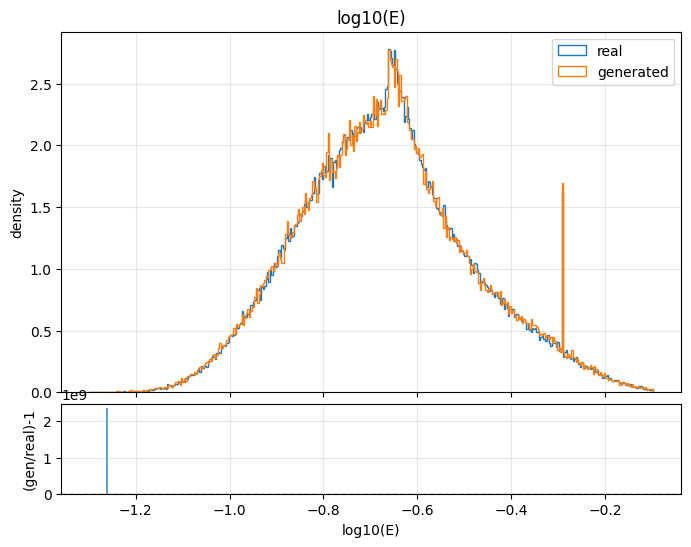

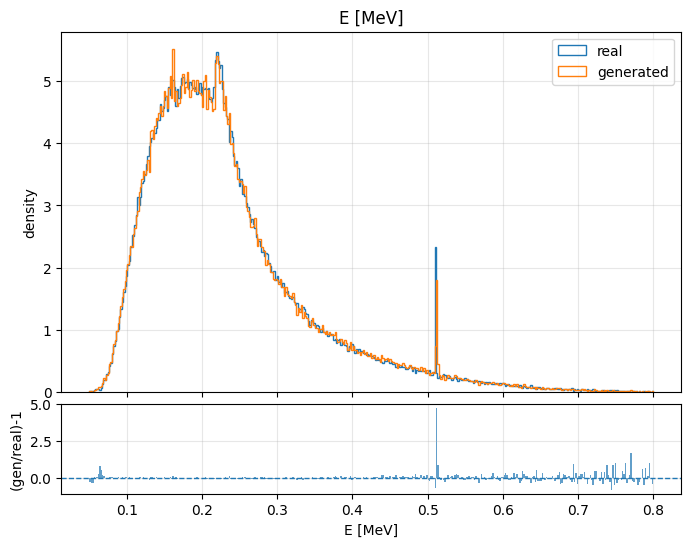

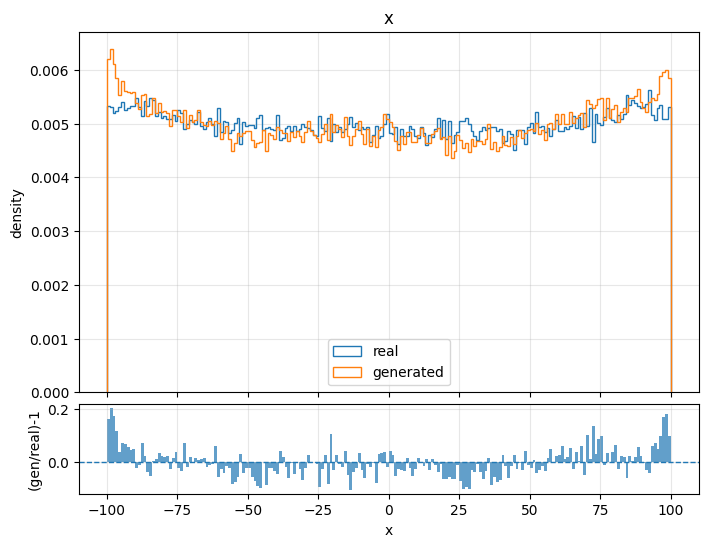

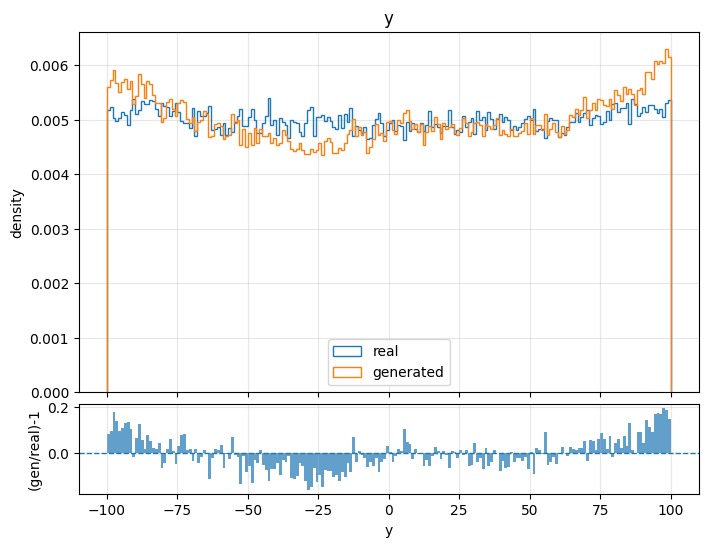

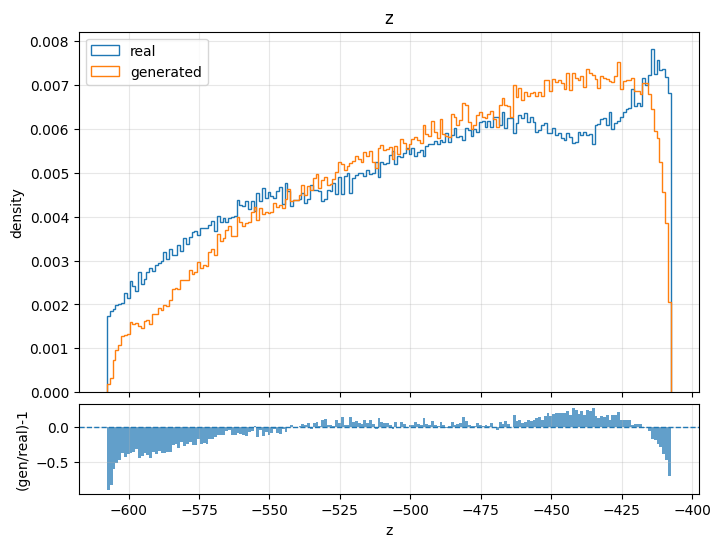

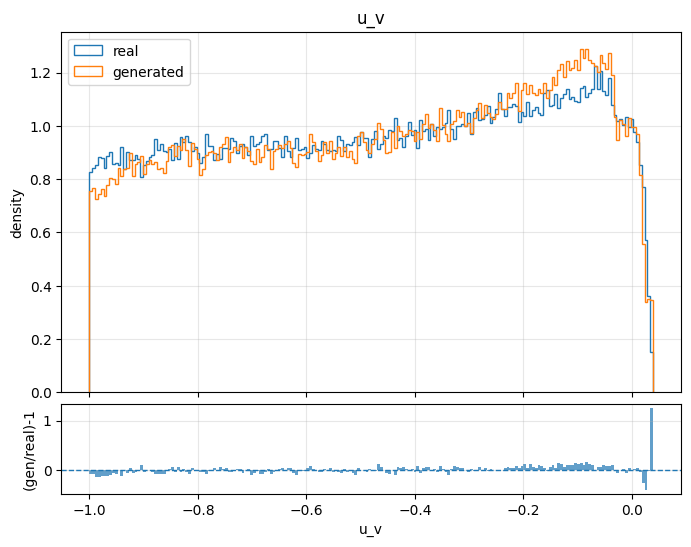

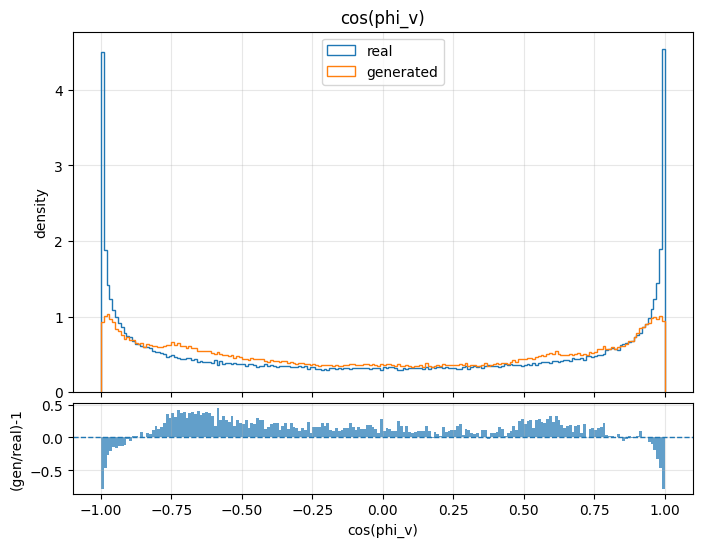

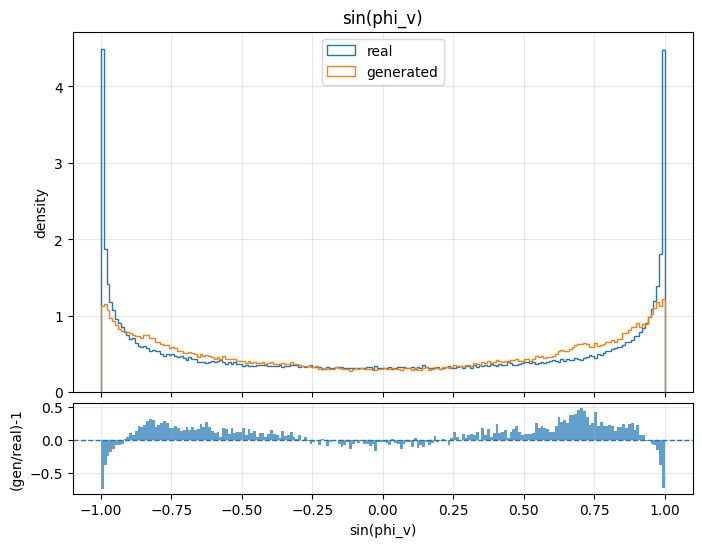

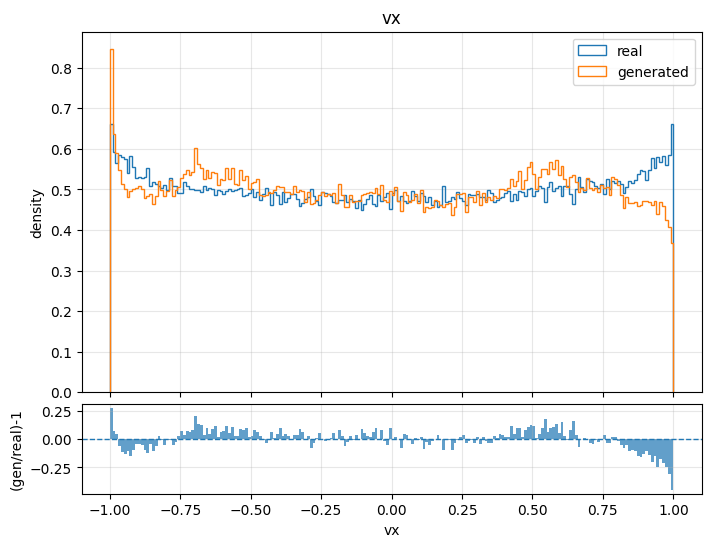

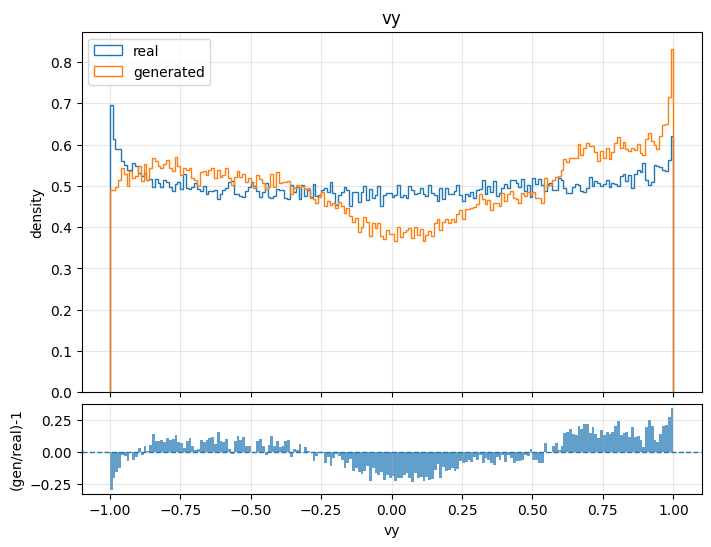

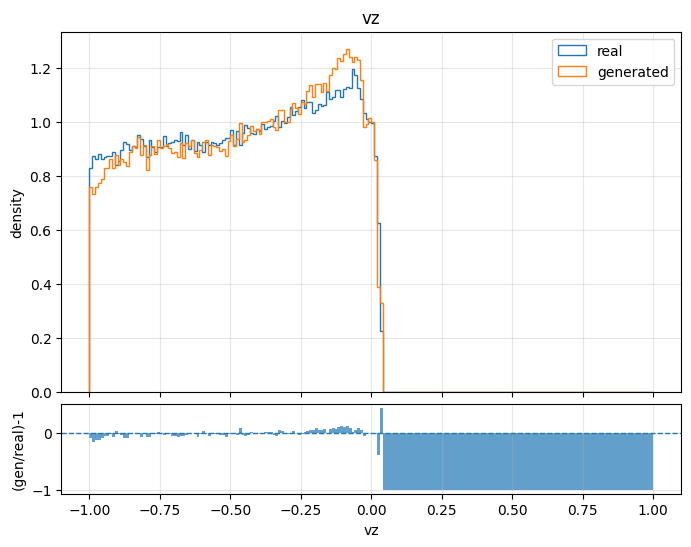


--- RANGE CHECK ---
logE real/gen: -1.2985218187136052 -0.0971983716800442 | -1.2981812 -0.09694832
u_v  real/gen: -0.99997324 0.03945439 | -0.9999948 0.03945439

Position:
x real/gen: -99.99881 99.999695 | -99.99893 99.99993
y real/gen: -99.99989 99.99974 | -99.99973 99.999374
z real/gen: -607.65607 -407.6601 | -607.66 -407.66

Direction:
cphi_v real/gen: -1.0 1.0 | -1.4705184 1.2352962
sphi_v real/gen: -1.0 1.0 | -1.1751034 1.1940483
vx real/gen: -0.9999941 0.9999922 | -0.999993 0.99998045
vy real/gen: -0.99999374 0.9999845 | -0.9999964 0.99999833
vz real/gen: -0.99997324 0.03945439 | -0.9999948 0.03945439

--- COS/SIN NORM CHECK ---
phi_r real/gen: 1.0 1.0060884
phi_v real/gen: 1.0 0.98018473


In [153]:
from scipy.stats import wasserstein_distance

eps = 1e-6

# ==========================================================
# Utility
# ==========================================================

def renorm_cos_sin(c, s, eps=1e-12):
    r = np.sqrt(c * c + s * s) + eps
    return c / r, s / r

# ==========================================================
# REAL TEST DATA
# ==========================================================

# Energy
E_real_test = E_test_raw.copy()
logE_real_test = np.log10(E_real_test)

# ----------------------------------------------------------
# Position
# ----------------------------------------------------------
s_r_real = X_cont_test[:, 0]
u_r_real = np.tanh(s_r_real)

cphi_r_real = X_cont_test[:, 1].copy()
sphi_r_real = X_cont_test[:, 2].copy()
cphi_r_real, sphi_r_real = renorm_cos_sin(cphi_r_real, sphi_r_real)

sin_tr_real = np.sqrt(np.maximum(0.0, 1.0 - u_r_real**2))

x_real = C[0] + R * sin_tr_real * cphi_r_real
y_real = C[1] + R * sin_tr_real * sphi_r_real
z_real = C[2] + R * u_r_real

# ----------------------------------------------------------
# Direction (DIRECT u_v)
# ----------------------------------------------------------
u_v_real = u_v_test_raw.copy()
u_v_real = np.clip(u_v_real, u_v_bins[0] + eps, u_v_bins[-1] - eps)

cphi_v_real = X_cont_test[:, 3].copy()
sphi_v_real = X_cont_test[:, 4].copy()
cphi_v_real, sphi_v_real = renorm_cos_sin(cphi_v_real, sphi_v_real)

sin_tv_real = np.sqrt(np.maximum(0.0, 1.0 - u_v_real**2))

vx_real = sin_tv_real * cphi_v_real
vy_real = sin_tv_real * sphi_v_real
vz_real = u_v_real

# ==========================================================
# GENERATED DATA (from previous cells)
# Already available:
#   E_gen, logE_gen
#   s_r_gen, cphi_r_gen, sphi_r_gen
#   u_v_gen, cphi_v_gen, sphi_v_gen
#   x_gen, ypos_gen, z_gen
#   vx_gen_rec, vy_gen_rec, vz_gen
# ==========================================================

# ==========================================================
# Plot function with residuals
# ==========================================================

def compare_hist_with_residuals(
    real,
    gen,
    name,
    bins=200,
    range_=None,
    eps_res=1e-12,
    ratio_clip=None,
):
    real = np.asarray(real)
    gen = np.asarray(gen)

    real_hist, bin_edges = np.histogram(real, bins=bins, range=range_, density=True)
    gen_hist, _ = np.histogram(gen, bins=bin_edges, density=True)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_widths = np.diff(bin_edges)

    residuals = gen_hist / np.maximum(real_hist, eps_res) - 1.0

    if ratio_clip is not None:
        residuals = np.clip(residuals, -ratio_clip, ratio_clip)

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1,
        figsize=(8, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [4, 1], "hspace": 0.05}
    )

    # Top panel
    ax_top.hist(real, bins=bin_edges, density=True, histtype="step", label="real")
    ax_top.hist(gen,  bins=bin_edges, density=True, histtype="step", label="generated")
    ax_top.set_ylabel("density")
    ax_top.set_title(name)
    ax_top.legend()
    ax_top.grid(True, alpha=0.3)

    # Bottom panel
    ax_bot.axhline(0.0, linestyle="--", linewidth=1)
    ax_bot.bar(bin_centers, residuals, width=bin_widths, alpha=0.7)
    ax_bot.set_xlabel(name)
    ax_bot.set_ylabel("(gen/real)-1")
    ax_bot.grid(True, alpha=0.3)

    plt.show()

# ==========================================================
# Wasserstein scores
# ==========================================================

scores = {
    "logE": wasserstein_distance(logE_real_test, logE_gen),
    "x": wasserstein_distance(x_real, x_gen),
    "y": wasserstein_distance(y_real, ypos_gen),
    "z": wasserstein_distance(z_real, z_gen),
    "u_v": wasserstein_distance(u_v_real, u_v_gen),
    "cphi_v": wasserstein_distance(cphi_v_real, cphi_v_gen),
    "sphi_v": wasserstein_distance(sphi_v_real, sphi_v_gen),
    "vx": wasserstein_distance(vx_real, vx_gen_rec),
    "vy": wasserstein_distance(vy_real, vy_gen_rec),
    "vz": wasserstein_distance(vz_real, vz_gen),
}

print("\n--- Wasserstein scores ---")
for k, v in scores.items():
    print(f"{k:>8s}: {v:.6f}")

# ==========================================================
# Plot ranges
# ==========================================================

uv_plot_range = (min(u_v_real.min(), u_v_gen.min()), max(u_v_real.max(), u_v_gen.max()))

# ==========================================================
# PLOTS
# ==========================================================

# Energy
compare_hist_with_residuals(logE_real_test, logE_gen, "log10(E)", bins=400)
compare_hist_with_residuals(E_real_test, E_gen, "E [MeV]", bins=400)

# Position
compare_hist_with_residuals(x_real, x_gen, "x", ratio_clip=5)
compare_hist_with_residuals(y_real, ypos_gen, "y", ratio_clip=5)
compare_hist_with_residuals(z_real, z_gen, "z", ratio_clip=5)

# Direction
compare_hist_with_residuals(u_v_real, u_v_gen, "u_v", range_=uv_plot_range, ratio_clip=5)
compare_hist_with_residuals(cphi_v_real, cphi_v_gen, "cos(phi_v)", range_=(-1, 1), ratio_clip=5)
compare_hist_with_residuals(sphi_v_real, sphi_v_gen, "sin(phi_v)", range_=(-1, 1), ratio_clip=5)

# Cartesian direction
compare_hist_with_residuals(vx_real, vx_gen_rec, "vx", range_=(-1, 1), ratio_clip=5)
compare_hist_with_residuals(vy_real, vy_gen_rec, "vy", range_=(-1, 1), ratio_clip=5)
compare_hist_with_residuals(vz_real, vz_gen, "vz", range_=(-1, 1), ratio_clip=5)

# ==========================================================
# Final checks
# ==========================================================

print("\n--- RANGE CHECK ---")
print("logE real/gen:", logE_real_test.min(), logE_real_test.max(), "|", logE_gen.min(), logE_gen.max())
print("u_v  real/gen:", u_v_real.min(), u_v_real.max(), "|", u_v_gen.min(), u_v_gen.max())

print("\nPosition:")
print("x real/gen:", x_real.min(), x_real.max(), "|", x_gen.min(), x_gen.max())
print("y real/gen:", y_real.min(), y_real.max(), "|", ypos_gen.min(), ypos_gen.max())
print("z real/gen:", z_real.min(), z_real.max(), "|", z_gen.min(), z_gen.max())

print("\nDirection:")
print("cphi_v real/gen:", cphi_v_real.min(), cphi_v_real.max(), "|", cphi_v_gen.min(), cphi_v_gen.max())
print("sphi_v real/gen:", sphi_v_real.min(), sphi_v_real.max(), "|", sphi_v_gen.min(), sphi_v_gen.max())
print("vx real/gen:", vx_real.min(), vx_real.max(), "|", vx_gen_rec.min(), vx_gen_rec.max())
print("vy real/gen:", vy_real.min(), vy_real.max(), "|", vy_gen_rec.min(), vy_gen_rec.max())
print("vz real/gen:", vz_real.min(), vz_real.max(), "|", vz_gen.min(), vz_gen.max())

# ==========================================================
# Norm checks
# ==========================================================

norm_phi_r_real = np.sqrt(cphi_r_real**2 + sphi_r_real**2)
norm_phi_r_gen  = np.sqrt(cphi_r_gen**2 + sphi_r_gen**2)

norm_phi_v_real = np.sqrt(cphi_v_real**2 + sphi_v_real**2)
norm_phi_v_gen  = np.sqrt(cphi_v_gen**2 + sphi_v_gen**2)

print("\n--- COS/SIN NORM CHECK ---")
print("phi_r real/gen:", norm_phi_r_real.mean(), norm_phi_r_gen.mean())
print("phi_v real/gen:", norm_phi_v_real.mean(), norm_phi_v_gen.mean())